In [1]:
# importing packages
import matplotlib.pyplot as plt
import ptitprince as pt
import random
import numpy as np
from numpy.random import default_rng
import pandas as pd
import json
from tqdm import tqdm
from scipy import stats
import seaborn as sns
import networkx as nx
import pickle
import itertools
from dotmotif import Motif, GrandIsoExecutor
from scipy.stats import kruskal, f_oneway, levene, ranksums, ttest_ind, wilcoxon, norm, chi2_contingency, chisquare
from statsmodels.stats.multitest import multipletests
from sklearn import mixture
from scipy.interpolate import interp1d
from tabulate import tabulate
from statannotations.Annotator import Annotator
from typing import Tuple, Dict, Any

plt.rcParams.update({'font.size': 20})
plt.rcParams["figure.figsize"] = (10,10)
sns.set_theme(style="whitegrid")
random.seed(747)

# Import Stefan's Library for Data Management of V1DD
from lsmm_data import LSMMData

In [2]:
# Set-Wise Comparison Functions: Determining the intersection of assembly assignment of two pyramidal cells 
# These comparison functions map to C in the statistical methods section.
def shared(pre, post, A):
    try:
        return not A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def disjoint(pre, post, A):
    try:
        return A[pre].isdisjoint(A[post])
    except KeyError:
        return False

def shared_a(pre, post, A):
    return (pre not in no_A) and (post not in no_A) # type: ignore

def shared_no_a(pre, post, A):
    return (pre in no_A) and (post in no_A) # type: ignore

def no_a_a(pre, post, A):
    return (pre in no_A) and (post not in no_A) # type: ignore

def a_no_a(pre, post, A):
    return (pre not in no_A) and (post in no_A) # type: ignore

def no_a_to_any(pre, _, A):
    return (pre in no_A) # type: ignore

def a_to_any(pre, _, A):
    return (pre not in no_A) # type: ignore

comparison_functions = [shared, disjoint, shared_a, shared_no_a, no_a_a, a_no_a, no_a_to_any, a_to_any]
groups = ['shared', 'disjoint', 'shared_a', 'shared_no_a']

In [3]:
# ===================== Effect sizes (Group 1 vs Group 2) =====================
# Group 1 == `shared`  or "All A"
# Group 2 == `disjoint` or "No A"
#
# Direction convention:
#   alternative="greater"  -> positive effect means Group 1 > Group 2
#   alternative="less"     -> positive effect means Group 1 < Group 2
#
# Paired vs Unpaired:
#   paired=False: independent samples (rank-sum/Mann–Whitney, cross-pairs).
#   paired=True : same keys in both groups; analyze within-pair differences z = s - d
#                 (signed-rank test; effect sizes defined on z relative to 0).
#
# Notes:
# - We always request the Mann–Whitney U for "Group 1 > Group 2" and then flip
#   for alternative="less". This keeps PS = U/(n1*n2) semantically correct.
# - For paired bootstraps, resample pairs jointly. 
# - Cohen's d (paired) is mean(z)/sd(z); (unpaired) is pooled-SD standardized mean difference.

# ----------------- Small utilities -----------------

def _dir_from_alt(alternative: str) -> int:
    """+1 for 'greater', -1 for 'less'."""
    if alternative not in ("greater", "less"):
        raise ValueError("alternative must be 'greater' or 'less'")
    return +1 if alternative == "greater" else -1


def _paired_from_dict(comparison_dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Build paired arrays from a dict containing Group 1 (shared/All A) and
    Group 2 (disjoint/No A) keyed by the same entity IDs.

    Returns
    -------
    s : np.ndarray
        Group 1 values for common keys (float).
    d : np.ndarray
        Group 2 values for common keys (float).
    z : np.ndarray
        Paired differences z = s - d (float).
    """
    shared_keys   = set(comparison_dict.get('shared', {}).keys())
    disjoint_keys = set(comparison_dict.get('disjoint', {}).keys())
    common        = sorted(shared_keys & disjoint_keys)
    if not common:
        return np.array([]), np.array([]), np.array([])
    s = np.array([comparison_dict["shared"][k]   for k in common], float)
    d = np.array([comparison_dict["disjoint"][k] for k in common], float)
    z = s - d
    return s, d, z


# ----------------- Effect sizes (unified) -----------------

def cohens_d(shared, disjoint, *, alternative: str = "greater", paired: bool = False) -> float:
    """
    Cohen's d with sign aligned to `alternative`.

    Parameters
    ----------
    shared : array-like
        Group 1 (shared / "All A") sample.
    disjoint : array-like
        Group 2 (disjoint / "No A") sample.
    alternative : {'greater','less'}
        'greater' -> positive when mean(Group1) > mean(Group2)
        'less'    -> positive when mean(Group1) < mean(Group2)
    paired : bool
        If True, compute paired d on z = (Group1 - Group2):
            d_paired = mean(z) / sd(z)
        If False, compute independent-samples d using pooled SD.

    Returns
    -------
    d : float
        Signed effect size per `alternative`. NaN if not computable.
    """
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    dir_alt = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size < 2:
            return np.nan
        z = s - d
        sd = np.std(z, ddof=1)
        if not np.isfinite(sd) or sd == 0:
            return np.nan
        base = np.mean(z) / sd   # >0 when Group1 > Group2
        return dir_alt * base

    # unpaired
    ns, nd = s.size, d.size
    if ns < 2 or nd < 2:
        return np.nan
    sp2 = ((ns - 1)*np.var(s, ddof=1) + (nd - 1)*np.var(d, ddof=1)) / (ns + nd - 2)
    sp  = np.sqrt(sp2)
    if not np.isfinite(sp) or sp == 0:
        return np.nan
    base = (np.mean(s) - np.mean(d)) / sp   # >0 when Group1 > Group2
    return dir_alt * base


def hodges_lehmann(shared, disjoint, *, alternative: str = "greater",
                   paired: bool = False, max_pairs: int = 5_000_000,
                   rng=None, approx_pairs: int = 2_000_000) -> float:
    """
    Hodges–Lehmann shift with sign aligned to `alternative`.

    Unpaired: median of all cross-pair differences (Group1 - Group2).
    Paired  : median of within-pair differences z = Group1 - Group2.

    Returns
    -------
    HL : float
        Signed HL shift in original units. Positive means evidence in the
        direction of `alternative`.
    """
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    dir_alt = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size == 0:
            return np.nan
        z = s - d
        base = np.median(z)  # >0 when Group1 > Group2
        return float(dir_alt * base)

    # unpaired
    n1, n2 = s.size, d.size
    if n1 == 0 or n2 == 0:
        return np.nan
    total = n1 * n2
    if total <= max_pairs:
        diffs = np.subtract.outer(s, d).ravel()  # s - d
        base  = np.median(diffs)
    else:
        rng = default_rng() if rng is None else rng
        k    = int(min(approx_pairs, total))
        diffs= s[rng.integers(0, n1, size=k)] - d[rng.integers(0, n2, size=k)]
        base = np.median(diffs)
    return float(dir_alt * base)


def ps_and_delta(shared, disjoint, *, alternative: str = "greater",
                 paired: bool = False, eps: float = 0.0, method: str = "asymptotic") -> Tuple[float, float]:
    """
    Probability of Superiority (Â) and Cliff's δ, aligned to `alternative`.

    Unpaired:
      We obtain the Mann–Whitney U for the orientation "Group1 > Group2"
      (by always calling mannwhitneyu(shared, disjoint, alternative='greater'))
      so that:
          A_shared = U_shared / (n1*n2) = P(Group1 > Group2) + 0.5*P(tie)
          δ_shared = 2*A_shared - 1     = P(Group1 > Group2) - P(Group1 < Group2)
      For alternative='less', we flip: (A, δ) = (1 - A_shared, -δ_shared).

    Paired:
      Operates on within-pair differences z = Group1 - Group2:
          A = P(z>0) + 0.5*P(z=0)
          δ = 2*A - 1 = P(z>0) - P(z<0)
      `eps` can be used to treat |z| <= eps as ties.

    Returns
    -------
    (PS, δ) : tuple of floats
        Signed per `alternative`. Positive means evidence in the direction of `alternative`.
    """
    s = np.asarray(shared, float); d = np.asarray(disjoint, float)
    dir_alt = _dir_from_alt(alternative)

    if paired:
        if s.size != d.size or s.size == 0:
            return np.nan, np.nan
        z    = s - d
        wins = np.sum(z >  eps)
        ties = np.sum(np.abs(z) <= eps)
        n    = z.size
        A_sh = (wins + 0.5 * ties) / n          # P(z>0) + 0.5 P(z=0)
        delta= 2.0 * A_sh - 1.0                 # P(z>0) - P(z<0)
        return (A_sh, delta) if dir_alt > 0 else (1.0 - A_sh, -delta)

    # unpaired
    n1, n2 = s.size, d.size
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan

    # Always request U for "Group1 > Group2"; flip later if needed
    U_shared, _ = stats.mannwhitneyu(s, d, alternative="greater", method=method)
    A_sh   = U_shared / (n1 * n2)               # PS for Group1 > Group2
    delta  = 2.0 * A_sh - 1.0                   # δ for Group1 > Group2
    return (A_sh, delta) if dir_alt > 0 else (1.0 - A_sh, -delta)


# ----------------- Bootstrap wrapper + reporting -----------------



def bootstrap_effects_and_p(
    comparison_dict: Dict[str, Dict[Any, float]],
    B: int = 1000,
    seed: int = 747,
    alternative: str = "greater",
    non_zero = False,
    alpha: float = 0.05,
    hl_max_pairs: int = 5_000_000,
    paired: bool = False,
    eps_tie: float = 0.0,
    mw_method: str = "asymptotic",
) -> Dict[str, Any]:
    """
    Bootstrap effect sizes and p-values for Group1 vs Group2.

    Groups:
      Group 1 ≡ comparison_dict['shared']   ≡ "All A"
      Group 2 ≡ comparison_dict['disjoint'] ≡ "No A"

    Effect sizes (all signed so that positive = evidence in direction of `alternative`):
      - Cohen's d        (pooled SD for unpaired; within-pair SD for paired)
      - Hodges–Lehmann   (median shift: cross-pair diffs for unpaired; z for paired)
      - PS (Â) and Cliff's δ (PS uses half-credit for ties; δ = 2*PS - 1)

    Tests:
      - Unpaired: Mann–Whitney (one-sided) for U→PS; you may also log rank-sum if desired.
      - Paired  : Wilcoxon signed-rank (one-sided) on z = Group1 - Group2.

    Bootstrap:
      - Unpaired: resample each group independently with replacement.
      - Paired  : resample pair indices with replacement (preserves pairing).

    Returns
    -------
    results : dict with 'point', 'CI95', and 'p_stability' sections.
    """
    rng = default_rng(seed)
    dir_alt = _dir_from_alt(alternative)

    if paired:
        s, d, z = _paired_from_dict(comparison_dict)

        if non_zero:
            mask = (s != 0) & (d != 0)
            s, d, z = s[mask], d[mask], z[mask]

        if z.size == 0:
            raise ValueError("No common keys for paired analysis.")

        # point estimates
        d_hat  = cohens_d(s, d, alternative=alternative, paired=True)
        HL_hat = hodges_lehmann(s, d, alternative=alternative, paired=True)
        PS_hat, delta_hat = ps_and_delta(s, d, alternative=alternative, paired=True, eps=eps_tie)

        # one-sided Wilcoxon on z
        alt = "greater" if dir_alt > 0 else "less"
        sr  = stats.wilcoxon(s, d, alternative=alt)
        p_point = float(sr.pvalue)

        # bootstrap (resample pairs)
        m = z.size
        d_b = np.empty(B); hl_b = np.empty(B); delta_b = np.empty(B); ps_b = np.empty(B); p_b = np.empty(B)
        for b in range(B):
            idx = rng.integers(0, m, size=m)
            sb, db = s[idx], d[idx]
            d_b[b]      = cohens_d(sb, db, alternative=alternative, paired=True)
            hl_b[b]     = hodges_lehmann(sb, db, alternative=alternative, paired=True)
            A_b, del_b  = ps_and_delta(sb, db, alternative=alternative, paired=True, eps=eps_tie)
            ps_b[b]     = A_b
            delta_b[b]  = del_b
            p_b[b]      = stats.wilcoxon(sb, db, alternative=alt).pvalue

    else:
        # unpaired
        s = np.array(list(comparison_dict["shared"].values()), float)
        d = np.array(list(comparison_dict["disjoint"].values()), float)
        
        if non_zero:
            s = s[s != 0]
            d = d[d != 0]
        
        if s.size == 0 or d.size == 0:
            raise ValueError("Empty group(s) for unpaired analysis.")

        d_hat  = cohens_d(s, d, alternative=alternative, paired=False)
        HL_hat = hodges_lehmann(s, d, alternative=alternative, paired=False,
                                max_pairs=hl_max_pairs, rng=rng)
        PS_hat, delta_hat = ps_and_delta(s, d, alternative=alternative, paired=False, method=mw_method)

        # one-sided Mann–Whitney p-value consistent with direction
        alt = "greater" if dir_alt > 0 else "less"
        mw  = stats.mannwhitneyu(s, d, alternative=alt, method=mw_method)
        p_point = float(mw.pvalue)

        # bootstrap (resample groups independently)
        n1, n2 = s.size, d.size
        d_b = np.empty(B); hl_b = np.empty(B); delta_b = np.empty(B); ps_b = np.empty(B); p_b = np.empty(B)
        for b in range(B):
            si = rng.integers(0, n1, size=n1)
            di = rng.integers(0, n2, size=n2)
            sb, db = s[si], d[di]
            d_b[b]      = cohens_d(sb, db, alternative=alternative, paired=False)
            hl_b[b]     = hodges_lehmann(sb, db, alternative=alternative, paired=False,
                                         max_pairs=hl_max_pairs, rng=rng)
            A_b, del_b  = ps_and_delta(sb, db, alternative=alternative, paired=False, method=mw_method)
            ps_b[b]     = A_b
            delta_b[b]  = del_b
            p_b[b]      = stats.mannwhitneyu(sb, db, alternative=alt, method=mw_method).pvalue

    # CIs
    def ci(arr): return (float(np.percentile(arr, 2.5)), float(np.percentile(arr, 97.5)))
    d_CI, hl_CI, ps_CI, delta_CI = ci(d_b), ci(hl_b), ci(ps_b), ci(delta_b)

    results = {
        "paired": paired,
        "alternative": alternative,
        "point": {
            "d": float(d_hat),
            "HL": float(HL_hat),
            "PS": float(PS_hat),
            "delta": float(delta_hat),
        },
        "CI95": {
            "d": d_CI,
            "HL": hl_CI,
            "PS": ps_CI,
            "delta": delta_CI,
        },
        "p_stability": {
            "median_p": float(np.median(p_b)),
            "p_95pct_range": (float(np.percentile(p_b, 2.5)), float(np.percentile(p_b, 97.5))),
            "prop_sig_at_alpha": float((p_b < alpha).mean()),
        },
    }

    # Labeled, readable console output
    mode = "PAIRED" if paired else "UNPAIRED"
    n_info = f"n_pairs={len(s)}" if paired else f"n1={len(s)}, n2={len(d)}"
    print(f"\n[{mode}] Effect Size Estimates (positive = in direction of '{alternative}')")
    print(f"  {n_info}")
    print(f"  Cohen's d        = {results['point']['d']:.3f}")
    print(f"  HL shift         = {results['point']['HL']:.6g}")
    print(f"  Probability Sup. = {results['point']['PS']:.3f}")
    print(f"  Cliff's δ        = {results['point']['delta']:.3f}")

    print("\nEffect Size Confidence Intervals (95% percentile bootstrap)")
    print(f"  d:     [{results['CI95']['d'][0]:.3f}, {results['CI95']['d'][1]:.3f}]")
    print(f"  HL:    [{results['CI95']['HL'][0]:.6g}, {results['CI95']['HL'][1]:.6g}]")
    print(f"  PS:    [{results['CI95']['PS'][0]:.3f}, {results['CI95']['PS'][1]:.3f}]")
    print(f"  δ:     [{results['CI95']['delta'][0]:.3f}, {results['CI95']['delta'][1]:.3f}]")

    print("\nP-value stability")
    print(f"  median p = {results['p_stability']['median_p']:.4g}")
    print(f"  95% range = [{results['p_stability']['p_95pct_range'][0]:.4g}, {results['p_stability']['p_95pct_range'][1]:.4g}]")
    print(f"  proportion significant (α={alpha}) = {results['p_stability']['prop_sig_at_alpha']:.3f}")

    return results

In [4]:
def save_figure(figure_name):
    plt.savefig(
        f"./draft_figures/{figure_name}.png",
        dpi=500,
        bbox_inches="tight")

def plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val, save=False, figure_name=None):
    """
    Plots a raincloud plot for two connection type groups, with sample sizes in the y-axis labels.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """
    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Shared\n(n={n_shared})", f"Disjoint\n(n={n_disjoint})"]

    # Data frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Set up the plot
    plt.figure(figsize=(12, 10))
    sns.set_theme(style="whitegrid")

    # Create the raincloud plot
    ax = pt.RainCloud(
        y="Values",
        x="Group",
        data=data,  
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,  
        alpha=0.8,  
        move=0.25,
        point_size = 6,  
        orient="v" 
    )

    # Set markings for significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax, 
                    pairs,
                    data=data,
                    x="Group",
                    y="Values",
                    order=y_labels # Force the order
                    )
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=30)
    annot.annotate()

    # Add plot title and labels
    plt.title(title, size=30)
    plt.xlabel("Connection Type", size=26)
    plt.ylabel(y_lab, size=26)
    plt.xticks(fontsize = 26)
    plt.yticks(fontsize = 26)

    if save == True:
        save_figure(figure_name)

    plt.tight_layout()
    plt.show()
    plt.close()

def plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, 
                                           y_lab, p_val, for_chains = True,
                                           save=False, figure_name=None
):
    """
    Plots a raincloud plot comparing connection types, 
    plus a smaller side subplot summarizing mean ± SEM for each group.

    Parameters:
        shared_values (list or array): Data for shared assembly group.
        disjoint_values (list or array): Data for disjoint assembly group.
        title (str): Title of the plot.
        y_lab (str): Label for the x-axis.
        p_val (float): P-value for significance annotation.
        save_fig (bool): Whether to save the figure.
        folder (str): Folder to save the figure if save_fig is True.
    """

    # Calculate sample sizes
    n_shared = len(shared_values)
    n_disjoint = len(disjoint_values)

    y_labels = [f"Shared\n(n={n_shared})", f"Disjoint\n(n={n_disjoint})"]

    # Build a frame for easier plotting
    data = pd.DataFrame({
        "Values": np.concatenate([shared_values, disjoint_values]),
        "Group": [y_labels[0]] * n_shared + [y_labels[1]] * n_disjoint
    })

    # Compute the statistics for the side plot
    # (Assuming values > 0 for simplicity; modify if needed.)
    shared_log = np.log10(shared_values)
    disjoint_log = np.log10(disjoint_values)

    mean_shared_log = np.mean(shared_log)
    mean_disjoint_log = np.mean(disjoint_log)
    sem_shared_log = stats.sem(shared_log, ddof=1) if n_shared > 1 else 0
    sem_disjoint_log = stats.sem(disjoint_log, ddof=1) if n_disjoint > 1 else 0

    # Set up a figure with two subplots
    fig = plt.figure(figsize=(15, 10))
    # Allocate 2 columns with a narrower column on the right
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[3, 1], wspace=0.3)
    
    # Set up styling
    ax_main = fig.add_subplot(gs[0])
    ax_side = fig.add_subplot(gs[1])
    sns.set_theme(style="whitegrid")

    # --- Main plot (original RainCloud) ---
    pt.RainCloud(
        y="Values",
        x="Group",
        data=data,
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,
        alpha=0.8,
        move=0.25,
        point_size=6,
        orient="v",
        ax=ax_main
    )

    # Annotate significance
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax_main, 
                      pairs,
                      data=data,
                      x="Group",
                      y="Values",
                      order=y_labels # Force the order
                      )
    annot.set_pvalues([p_val])
    annot.configure(text_format="star", loc="inside", fontsize=28)
    annot.annotate()

    # Axis title and labels
    ax_main.set_title(title, size=24)
    ax_main.set_xlabel("Connection Type", size=24)
    ax_main.set_ylabel(y_lab, size=24)
    ax_main.tick_params(labelsize=24)
    ax_main.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax_main.yaxis.get_offset_text().set_fontsize(24)


    # --- Side plot (Mean ± SEM of log(data))---
    # Currently place two horizontal lines and use fill_between for each ± sem region.

    x_vals = [1, 2]  # x positions for shared and disjoint
    mean_logs = [mean_shared_log, mean_disjoint_log]
    sem_logs = [sem_shared_log, sem_disjoint_log]
    colors = [(0.4, 0.6, 0.8, 0.8), 'grey']

    for i, x in enumerate(x_vals):
        m_log = mean_logs[i]
        s_log = sem_logs[i]
        c = colors[i]

        # Horizontal line for mean
        ax_side.hlines(
            y = m_log, 
            xmin = x - 0.15, 
            xmax = x + 0.15, 
            color = c, 
            linewidth = 3
        )
        # Shaded area for ± SEM
        ax_side.fill_betweenx(
            y = [m_log - s_log, m_log + s_log],
            x1 = x - 0.15,
            x2 = x + 0.15,
            color = c,
            alpha = 0.4
        )

    # Tidy up side axis
    ax_side.set_title("Mean ± SEM", size=24)
    ax_side.set_xlim(0.5, 2.5)  
    ax_side.set_xticks(x_vals)
    ax_side.set_xticklabels(["Shared", "Disjoint"], fontsize=24)
    ax_side.tick_params(axis='y', labelsize=24)
    # Show that y-values are on a log base 10 scale
    if for_chains:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight Products) $(\mathrm{\mu m^6})$", size=24)
    else:
        ax_side.set_ylabel(r"$\log_{10}$(Synaptic Weight) $(\mathrm{\mu m^3})$", size=24)

    if save and figure_name is not None:
        save_figure(figure_name + "_with_side_plot")

    plt.tight_layout()
    plt.show()
    plt.close()


def ranksum_signedrank_two_group_comparison(comparison_dict, aggregation_method="by connection", directionality=None, data_type="binary", 
                            paired=False, non_zero=False, chain_test = False, chain_description = "Excitatory", save=True, figure_name=None, title_prefix = ""):
    """
    Compares 'shared' and 'disjoint' groups based on connection type and data type.
    Uses a one-sided Wilcoxon rank-sum test and performs a Wilcoxon signed-rank test if paired=True.

    Parameters:
    - comparison_dict (dict): Dictionary with 'shared' and 'disjoint' data.
    - aggregation_method (str): Type of connection ('connection' for pairwise, 'cell' for inbound/outbound by cell).
    - directionality (str): Direction of connectivity for 'cell' type ('inbound' or 'outbound').
    - data_type (str): Data type ('binary' for connectivity, 'synaptic_count' for synaptic counts, 'summed_psd' for nonzero PSD).
    - paired (bool): If True, performs an additional Wilcoxon signed-rank test on paired data.
    - non_zero (bool): If True, filters out zero entries for summed PSD.
    - chain_test (bool): If True, the test is considering chains.
    - chain_description (str): Type of intermediate cell in chain ('excitatory' or 'inhibitory')
    """

    # Set title and labels based on connection_type and data_type
    if aggregation_method == "connection":  # Pairwise connections
        if data_type == "binary":
            title = "Binary Connectivity"
            y_lab = "Binary Connections"
            folder = "pairwise_binary_connectivity"
        elif data_type == "synaptic_count":
            if non_zero == True:
                title = "Synaptic Counts"
                y_lab = "Nonzero Synaptic Count"
                folder = 'synaptic_count'
        elif data_type == "summed_psd":
            if non_zero == True:
                title = "Synaptic Weight"
                y_lab = "Nonzero Synaptic Weight (\u03bcm$^3$)"
                # title = "Nonzero Summed PSD"
                # y_lab = "Nonzero Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_nonzero_summed_psd"
            else:
                title = "Synaptic Weight"
                y_lab = "Synaptic Weight (\u03bcm$^3$)"
                # title = "Summed PSD"
                # y_lab = "Summed PSD (\u03bcm$^3$)"
                folder = "pairwise_summed_psd"
        else:
            raise ValueError("Invalid data_type for pairwise connection.")

    elif aggregation_method == "cell":  # By cell with inbound/outbound directionality
        if directionality not in ["inbound", "outbound"]:
            raise ValueError("For 'cell' connection_type, directionality must be 'inbound' or 'outbound'.")
        
        if data_type == "binary":
            title = f"Probability of {directionality.capitalize()} Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Connection"
            folder = f"{directionality}_connection_probability"
        elif data_type == "synaptic_count":
            title = f"Average Nonzero {directionality.capitalize()} Synaptic Count by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} Synaptic Count"
            folder = f"{directionality}_average_nonzero_synaptic_count"
        elif data_type == "summed_psd":
            title = f"Average Nonzero {directionality.capitalize()} PSD by Cell"
            y_lab = f"Average Nonzero {directionality.capitalize()} PSD (\u03bcm$^3$)"
            folder = f"{directionality}_average_nonzero_psd"
        else:
            raise ValueError("Invalid data_type for inbound/outbound connection.")
    else:
        raise ValueError("Invalid connection_type. Must be 'connection' or 'cell'.")

    if chain_test:
        if directionality == None:
            title = f"{chain_description} Chain Weight Proucts"
            y_lab = "Synaptic Weight Products"
        elif data_type == 'binary':
            title = f"Probability of {directionality.capitalize()} Chain Connection by Cell"
            y_lab = f"Probability of {directionality.capitalize()} Chain Connection"
        elif data_type == 'summed_psd':
            title = f"Average Nonzero {directionality.capitalize()} PSD Chain Product by Cell"
            y_lab = "Synaptic Weight Products"

    shared_values = np.array(list(comparison_dict["shared"].values()))
    disjoint_values = np.array(list(comparison_dict["disjoint"].values()))
    # Filter out zeros if non_zero is specified for summed_psd
    if non_zero and (data_type == "summed_psd" or data_type == 'synaptic_count'):
        shared_values = shared_values[shared_values != 0]
        disjoint_values = disjoint_values[disjoint_values != 0]

    # Perform the Wilcoxon rank-sum test (one-sided, shared > disjoint)
    if chain_description=='Inhibitory':
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='less')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='less')
    else:
        rank_sum_stat, rank_sum_p = stats.ranksums(shared_values, disjoint_values, alternative='greater')
        print(f"Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):\nStatistic: {rank_sum_stat:.4g}, P-value: {rank_sum_p:.4g}")
        bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, alternative='greater')

    title = f'{title}\nRank-Sum P-value: {rank_sum_p:.2g}'
    # If paired=True, also perform a Wilcoxon signed-rank test on paired observations
    if paired:
        shared_keys = set(comparison_dict.get('shared', {}).keys())
        disjoint_keys = set(comparison_dict.get('disjoint', {}).keys())
        common_keys = shared_keys & disjoint_keys

        if common_keys:
            # Extract paired data for common keys
            shared_paired = np.array([comparison_dict["shared"][key] for key in common_keys])
            disjoint_paired = np.array([comparison_dict["disjoint"][key] for key in common_keys])

            # Perform Wilcoxon signed-rank test on paired data
            if chain_description=='Inhibitory':
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='less')
                print(f"Wilcoxon Signed-Rank Test (paired, shared < disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='less')
            else:
                signed_rank_stat, signed_rank_p = stats.wilcoxon(shared_paired, disjoint_paired, alternative='greater')
                print(f"Wilcoxon Signed-Rank Test (paired, shared > disjoint):\nStatistic: {signed_rank_stat:.4g}, P-value: {signed_rank_p:.4g}")
                bootstrap_effects_and_p(comparison_dict, non_zero = non_zero, paired=True, alternative='greater')
            title = f'{title}, Signed-Rank P-value: {signed_rank_p:.2g}'
        else:
            print("No common observations found for paired analysis.")
    title = f'{title_prefix}{title}' 
    plot_shared_vs_disjoint(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, figure_name=figure_name)
    for_chains = True if chain_test else False
    plot_shared_vs_disjoint_with_side_plot(shared_values, disjoint_values, title, y_lab, p_val = rank_sum_p, save=save, for_chains = for_chains, figure_name=figure_name)

def synaptic_count_histogram(values_dict, connection_type, save=False, figure_name=None):
    """
    Plots a histogram of synaptic counts for a given connection type, using integer bins,
    with frequency labels on each bar.

    Parameters:
    - values_dict: dict of {(pre, post): count} pairs
    - connection_type: str, e.g., 'shared', 'disjoint', etc.
    - save: bool, whether to save the figure
    - figure_name: str, path to save the figure if save is True
    """
    values = list(values_dict.values())
    if not values:
        print(f"No values to plot for connection type: {connection_type}")
        return

    max_val = max(values)
    bins = range(0, max_val + 2)  # +2 to include max_val itself as upper bound

    plt.figure(figsize=(8, 6))
    counts, bins, patches = plt.hist(
        values,
        bins=bins,
        color=(0.4, 0.6, 0.8, 0.5),  # semi-transparent blue fill
        edgecolor="grey",
        alpha=0.8,            # grey borders
        align="left"
    )

    plt.title(f'Histogram of Synaptic Counts for {connection_type.capitalize()} Connections')
    plt.xlabel('Synaptic Count')
    plt.ylabel('Frequency')
    plt.xticks(bins)  # show every integer tick
    plt.xlim(left=0, right=max_val + 1)

    # Add frequency labels on top of each bar
    for bin_edge, count in zip(bins, counts):
        if count > 0:
            plt.text(bin_edge, count + 0.5, str(int(count)),
                     ha='center', va='bottom', fontsize=9)

    plt.tight_layout()

    # if save and figure_name is not None:
    #     save_figure(figure_name)

    plt.show()
    plt.close()

# Pyramidal Rectangular Set

In [5]:
# Pull Data from LSMM Data
with open('pyr_cells_rectangular_connectome.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Filtering to pyramidal cells only
459


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\lsmm_data\LSMMData.py:391: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['structural']['post_cell']['connectome_index'] = data['structural']['post_cell'].index
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\lsmm_data\LSMMData.py:417: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['structural']['post_cell']['pt_position'] = [[data['structural']['post_cell'].iloc[i]['pt_position_x'],data['structural']['post_cell'].iloc[i]['pt_position

Generating Connectome...


100%|██████████| 44293/44293 [01:53<00:00, 391.45it/s]


Generating Connectome...


100%|██████████| 44293/44293 [01:55<00:00, 383.06it/s]


In [6]:
### Pull necessary data from V1DD using LSMMData Manager
cell_table = data_a['structural']['pre_cell'].copy()
cell_table['connectome_index'] = cell_table.index
post_cell_table = data_a['structural']['post_cell'].copy()
post_cell_table['connectome_index'] = post_cell_table.index
synapse_table = data_a['structural']['synapse']

# Establish seperate sets for the pre and post synaptic partnes
# This is necessary as the set of connectome index of pre-synaptic cells do not 
# match the post-synaptic cells due to allowing unproofread post-synaptic targets.
individual_assembly_indexes = [mappings_a['connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]
individual_post_assembly_indexes = [mappings_a['post_connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]

coregistered_post_cell_indexes = mappings_a['assemblies_by_post_connectome_index'].keys()
coregistered_cell_indexes = mappings_a['assemblies_by_connectome_index'].keys()

no_a_cell_indexes = mappings_a['connectome_indexes_by_assembly']['No A']
no_a_post_cell_indexes = mappings_a['post_connectome_indexes_by_assembly']['No A']

pooled_assembly_indexes = list(set(coregistered_cell_indexes) - set(no_a_cell_indexes))
pooled_assembly_post_indexes = list(set(coregistered_post_cell_indexes) - set(no_a_post_cell_indexes))
# Each cell has a distinct root id, so it is unnecessary to establish different sets
assembly_to_root_ids = mappings_a['pt_root_ids_by_assembly']
assembly_root_ids_set = set(mappings_a['assemblies_by_pt_root_id'].keys())

# Filter synapses_table to only synapses between two assembly cells (including No A)
synapses_df = synapse_table[synapse_table['pre_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df = synapses_df[synapses_df['post_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df['size'] = synapses_df['size'] * (9 * 9 * 45) / (10**9) # Voxels -> Cubic micrometers

# Filter cell tables to only assembly cells
cell_table = cell_table[cell_table['pt_root_id'].isin(assembly_root_ids_set)]
post_cell_table = post_cell_table[post_cell_table['pt_root_id'].isin(assembly_root_ids_set)]

# Finalized set of Root IDs, which are 
pre_root_ids = set(cell_table['pt_root_id'].values)
post_root_ids = set(post_cell_table['pt_root_id'].values)
all_root_ids = pre_root_ids | post_root_ids

In [7]:
### Prep the sets for Analysis, following our description in the Methods section
# Collect our connectomes of pre and post synaptic sets based on the root_ids of the neurons
w = {}
s = {}
b = {}
for pre in pre_root_ids:
    for post in post_root_ids:
        if pre != post:
            w[(pre, post)] = 0
            s[(pre, post)] = 0
            b[(pre, post)] = 0

for i, row in synapses_df.iterrows():
    pre = row['pre_pt_root_id']
    post = row['post_pt_root_id']
    w[(pre, post)] += row['size']
    s[(pre, post)] += 1
    b[(pre, post)] = 1

# Split out assemblies and no_a
assembly_names = set(assembly_to_root_ids.keys()) - set(['No A'])
A_invert = {assembly: set(assembly_to_root_ids[assembly]) for assembly in assembly_names}
no_A = set(assembly_to_root_ids['No A'])
all_coregistered_root_ids = mappings_a['assemblies_by_pt_root_id'].keys()
assembly_root_ids_excluding_no_A = set(all_coregistered_root_ids) - no_A
A = {pt_root_id: set(mappings_a['assemblies_by_pt_root_id'][pt_root_id]) for pt_root_id in all_root_ids if 'No A' not in mappings_a['assemblies_by_pt_root_id'][pt_root_id]}

In [8]:
S_nonzero_pairwise = {}
W_nonzero_pairwise = {}
B_pairwise = {}
for connection_type in comparison_functions:
    S_nonzero_pairwise[connection_type.__name__] = {}
    W_nonzero_pairwise[connection_type.__name__] = {}
    B_pairwise[connection_type.__name__] = {}
    for (j, i) in w.keys():
        if connection_type(j, i, A):
            B_pairwise[connection_type.__name__][(j, i)] = 1 if w[(j, i)] > 0 else 0
            if w[(j, i)] > 0:
                S_nonzero_pairwise[connection_type.__name__][(j, i)] = s[(j, i)]
                W_nonzero_pairwise[connection_type.__name__][(j, i)] = w[(j, i)]

S_nonzero_out = {}
W_nonzero_out = {}
for connection_type in comparison_functions:
    S_nonzero_out[connection_type.__name__] = {}
    W_nonzero_out[connection_type.__name__] = {}
    for j in pre_root_ids:
        if len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0]) > 0:
            S_nonzero_out[connection_type.__name__][j] = sum([s[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0])
            W_nonzero_out[connection_type.__name__][j] = sum([w[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if i != j and connection_type(j, i, A) and w[(j, i)] > 0])

S_nonzero_in = {}
W_nonzero_in = {}
for connection_type in comparison_functions:
    S_nonzero_in[connection_type.__name__] = {}
    W_nonzero_in[connection_type.__name__] = {}
    for i in post_root_ids:
        if len([j for j in pre_root_ids if connection_type(j, i, A)]) > 0 and len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0]):
            S_nonzero_in[connection_type.__name__][i] = sum([s[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0])
            W_nonzero_in[connection_type.__name__][i] = sum([w[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if j != i and connection_type(j, i, A) and w[(j,i)] > 0])

B_out = {}
for connection_type in comparison_functions:
    B_out[connection_type.__name__] = {}
    for j in pre_root_ids:
        if len([i for i in post_root_ids if connection_type(j, i, A) and j != i]) > 0:
            B_out[connection_type.__name__][j] = sum([b[(j, i)] for i in post_root_ids if connection_type(j, i, A) and j != i]) / len([i for i in post_root_ids if connection_type(j, i, A) and j != i])

B_in = {}
for connection_type in comparison_functions:
    B_in[connection_type.__name__] = {}
    for i in post_root_ids:
        if len([j for j in pre_root_ids if connection_type(j, i, A) and i != j]) > 0:
            B_in[connection_type.__name__][i] = sum([b[(j, i)] for j in pre_root_ids if connection_type(j, i, A) and i != j]) / len([j for j in pre_root_ids if connection_type(j, i, A) and j != i])


# Histograms By Connection Type

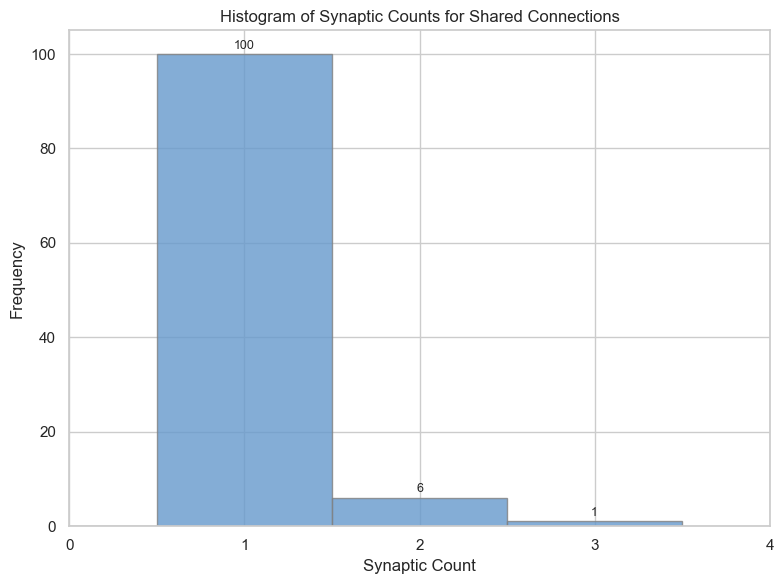

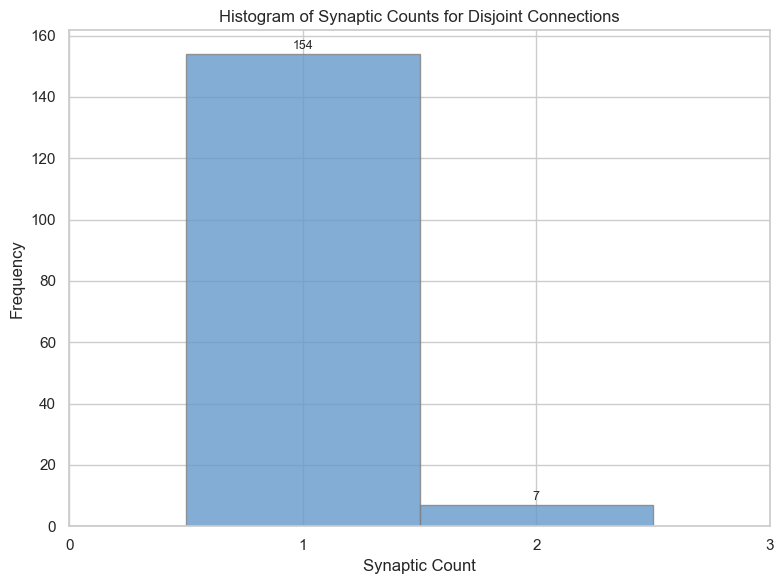

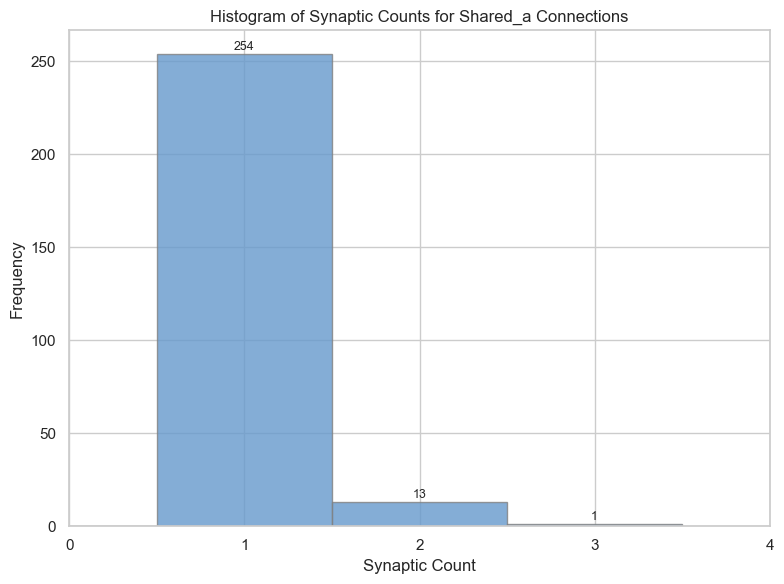

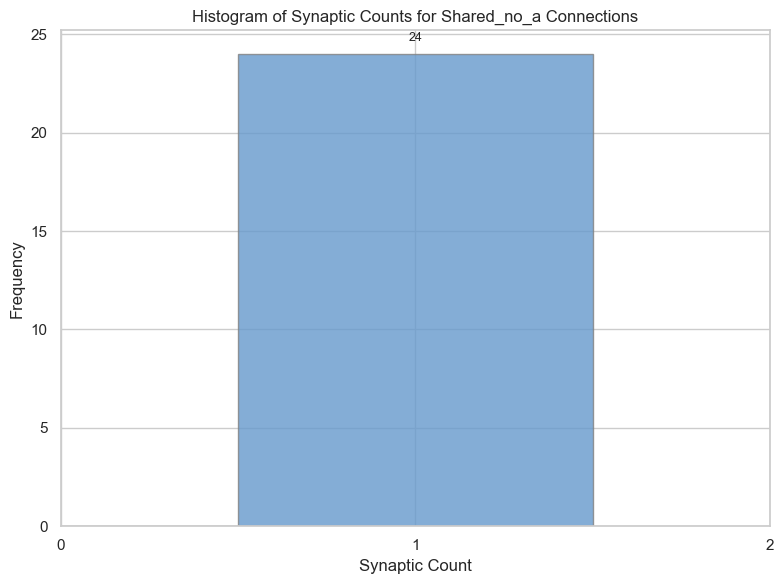

In [9]:
for group in groups:
    synaptic_count_histogram(
        values_dict=S_nonzero_pairwise[group],
        connection_type=group,
        save=False,
        figure_name=None
    )

# Report Results

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.1762, P-value: 0.5699

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=107, n2=161
  Cohen's d        = 0.053
  HL shift         = -0.000112995
  Probability Sup. = 0.494
  Cliff's δ        = -0.013

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.203, 0.275]
  HL:    [-0.00126172, 0.000940501]
  PS:    [0.424, 0.559]
  δ:     [-0.152, 0.118]

P-value stability
  median p = 0.574
  95% range = [0.05079, 0.9822]
  proportion significant (α=0.05) = 0.025
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:5.699e-01


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


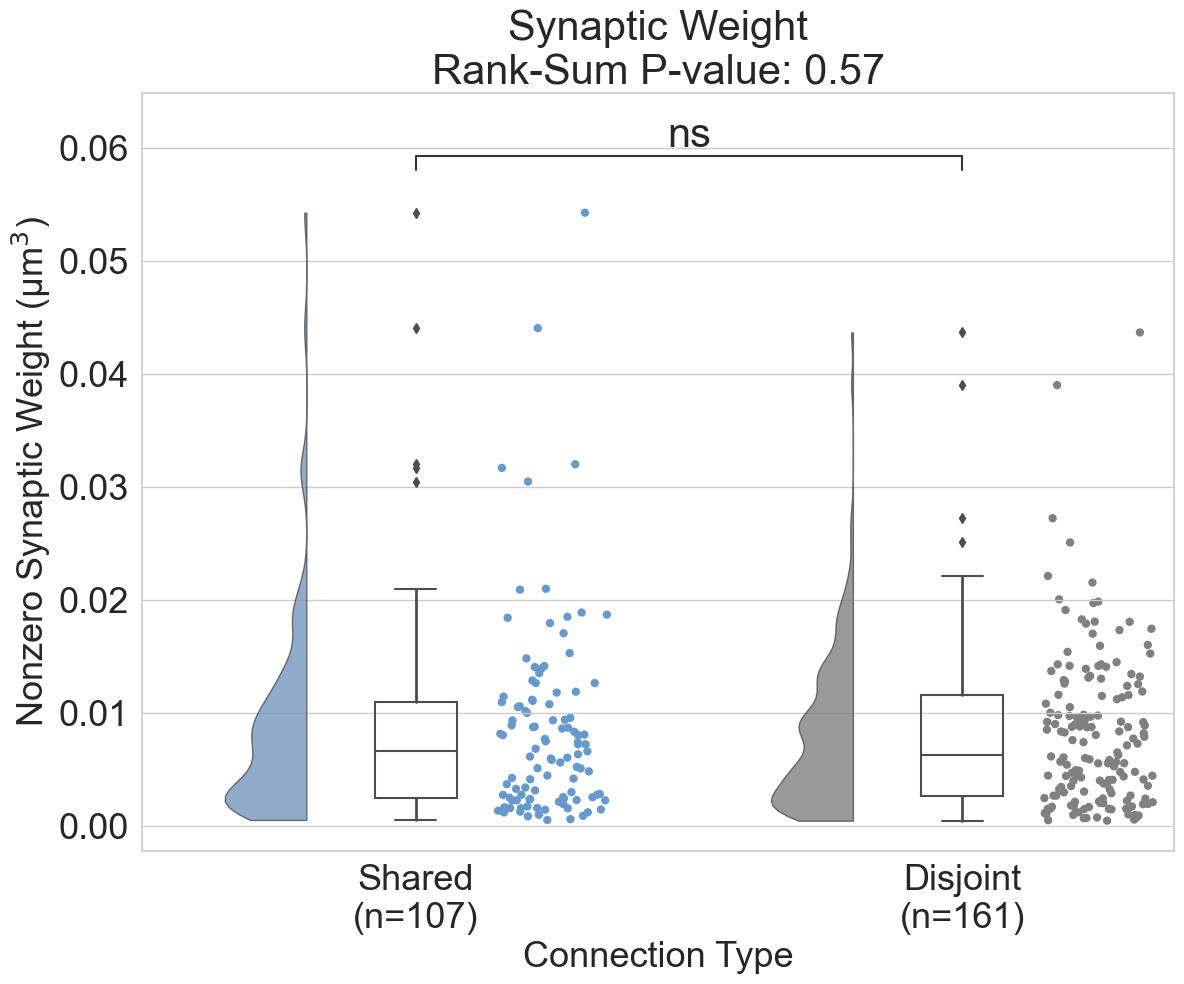

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:5.699e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


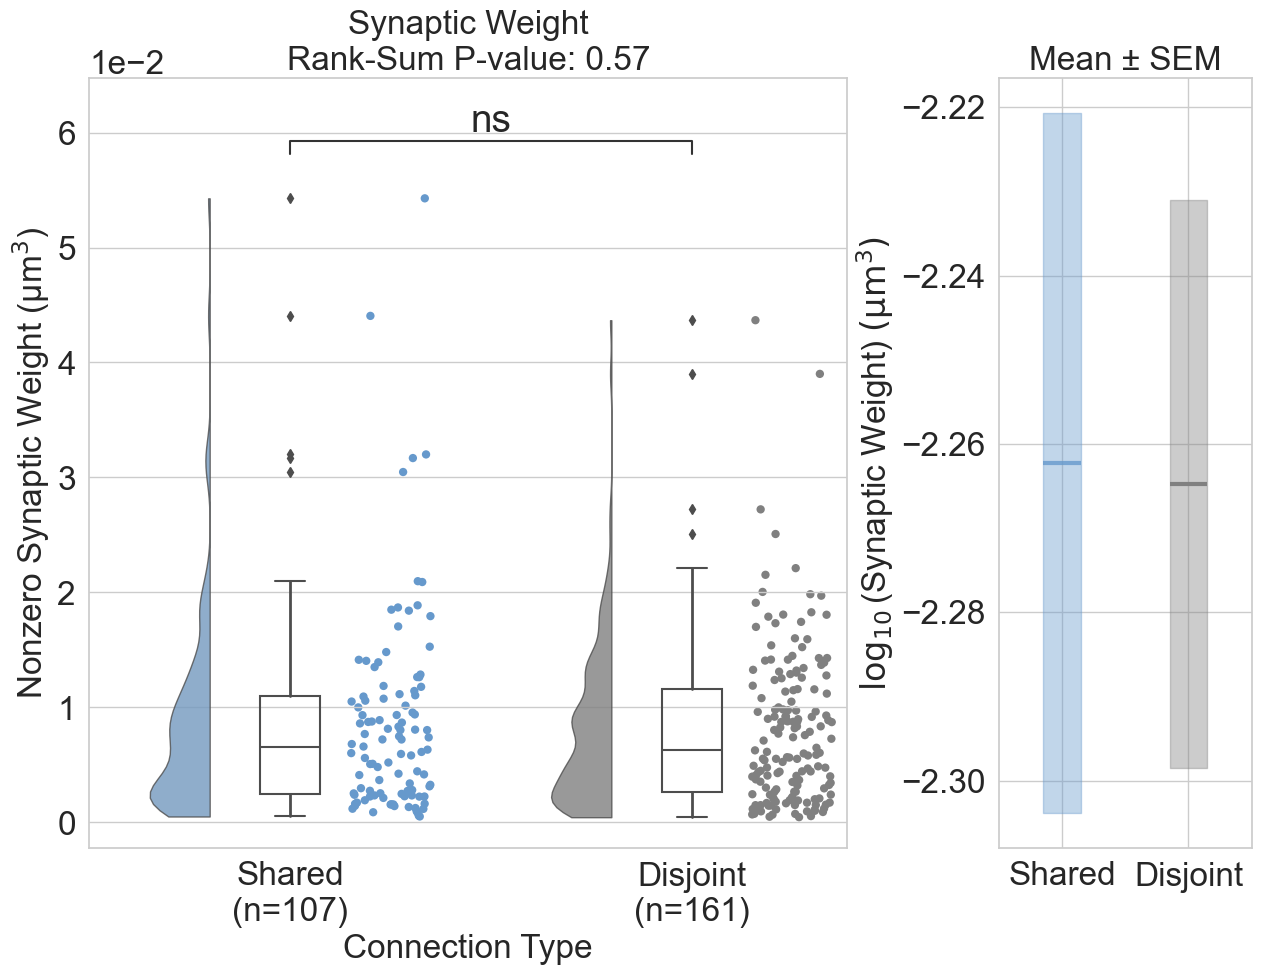

In [10]:
ranksum_signedrank_two_group_comparison(W_nonzero_pairwise,
                                        aggregation_method='connection',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        save=True,
                                        figure_name='Nonzero_PSD_by_Conn'
                                        )

# bootstrap_effects_and_p(W_nonzero_pairwise, alternative='greater')

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.7041, P-value: 0.7593

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=61, n2=61
  Cohen's d        = 0.123
  HL shift         = -0.00078901
  Probability Sup. = 0.463
  Cliff's δ        = -0.074

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.258, 0.435]
  HL:    [-0.00813008, 0.00398057]
  PS:    [0.356, 0.563]
  δ:     [-0.289, 0.127]

P-value stability
  median p = 0.7748
  95% range = [0.1126, 0.9972]
  proportion significant (α=0.05) = 0.005
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 916.5, P-value: 0.406

[PAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n_pairs=61
  Cohen's d        = 0.095
  HL shift         = 0
  Probability Sup. = 0.492
  Cliff's δ        = -0.016

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.157, 0.322]
  HL:    [-0.00892857, 0.00703443]
  PS:    [0.377, 0.615]
  δ

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


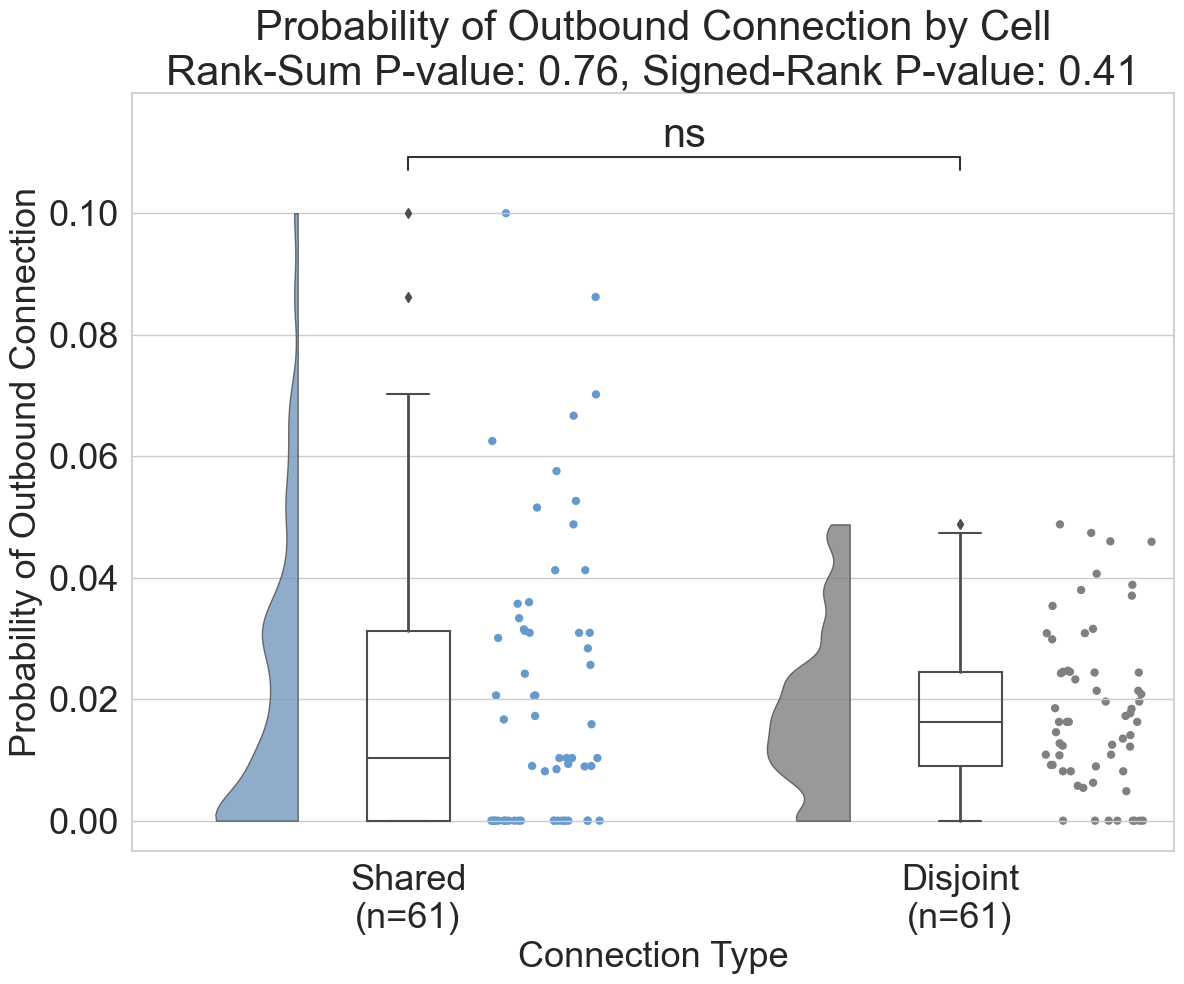

C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:108: RuntimeWarning: divide by zero encountered in log10
  shared_log = np.log10(shared_values)
C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:109: RuntimeWarning: divide by zero encountered in log10
  disjoint_log = np.log10(disjoint_values)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=61) vs. Disjoint
(n=61): Custom statistical test, P_val:7.593e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


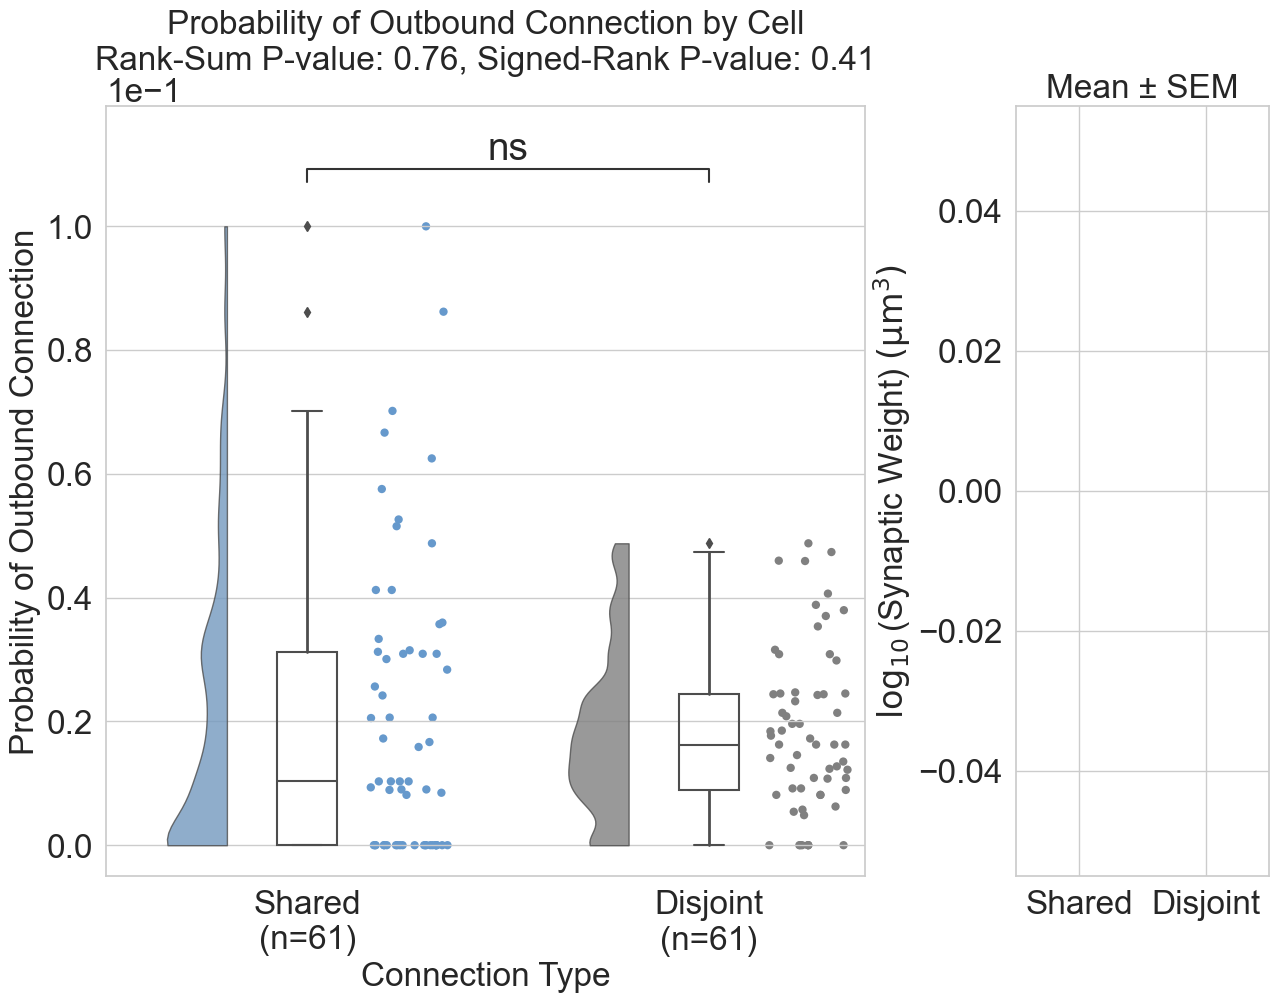

In [11]:
ranksum_signedrank_two_group_comparison(B_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='binary',
                                        paired=True,
                                        save=True,
                                        figure_name='Prob_Outbound_Conn'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.2647, P-value: 0.6044

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=39, n2=53
  Cohen's d        = -0.041
  HL shift         = -0.00028674
  Probability Sup. = 0.484
  Cliff's δ        = -0.032

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.465, 0.388]
  HL:    [-0.00219758, 0.00161663]
  PS:    [0.359, 0.608]
  δ:     [-0.281, 0.216]

P-value stability
  median p = 0.6059
  95% range = [0.039, 0.9893]
  proportion significant (α=0.05) = 0.029
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 266, P-value: 0.6043

[PAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n_pairs=33
  Cohen's d        = -0.034
  HL shift         = -0.000307395
  Probability Sup. = 0.485
  Cliff's δ        = -0.030

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.411, 0.304]
  HL:    [-0.00232259, 0.00212261]
  PS:    [0.333,

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


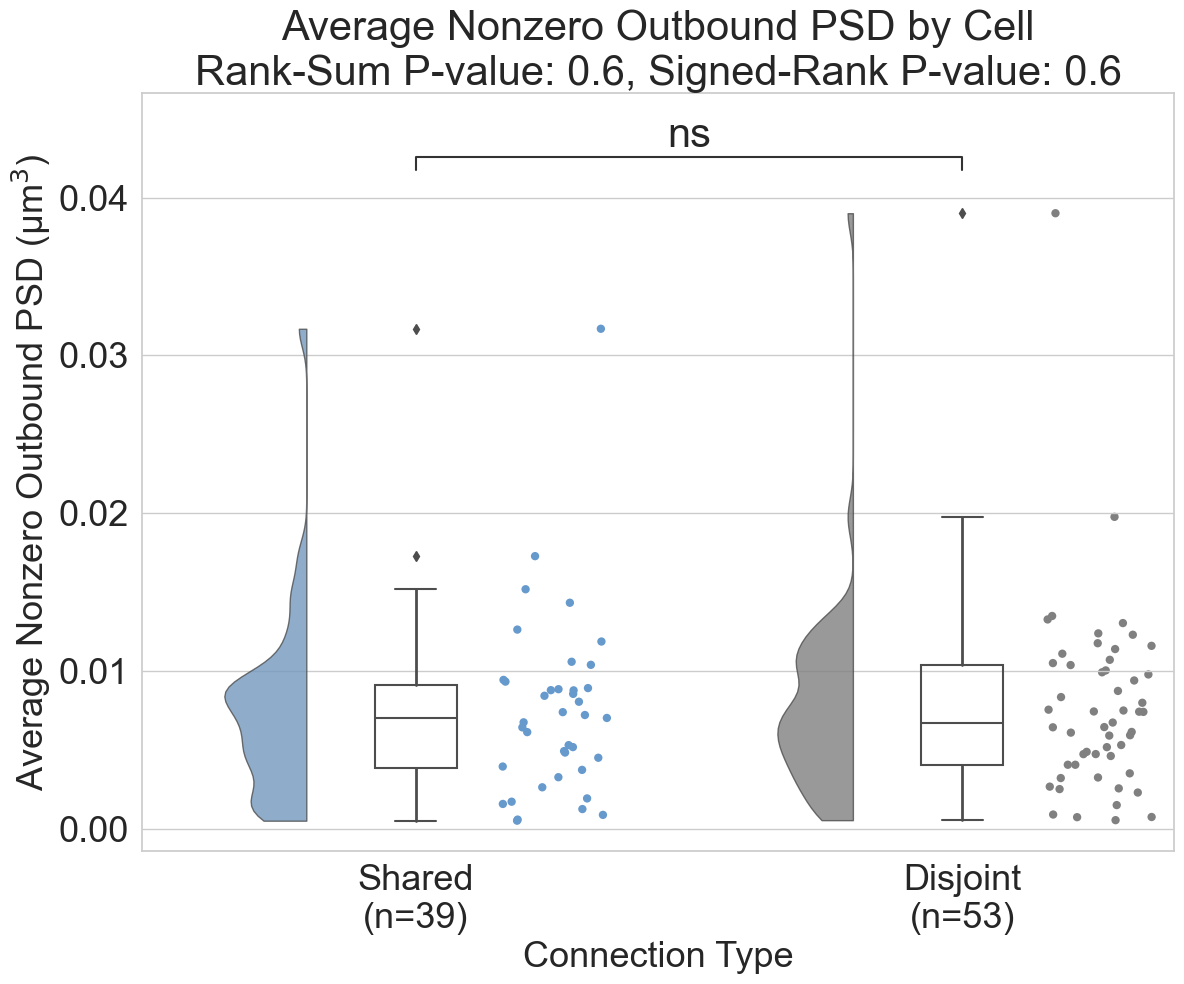

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=39) vs. Disjoint
(n=53): Custom statistical test, P_val:6.044e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


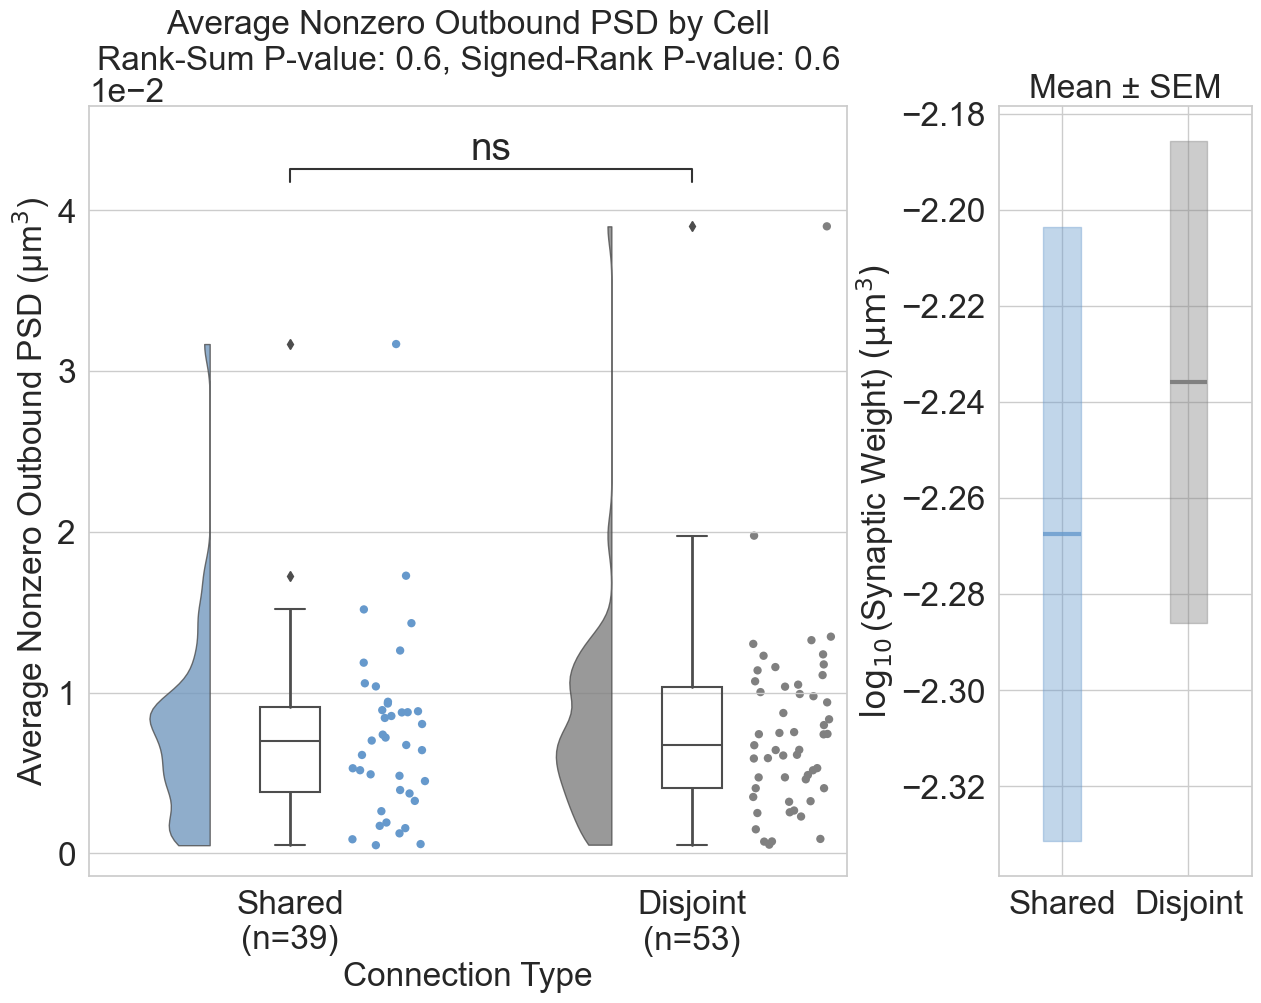

In [12]:
ranksum_signedrank_two_group_comparison(W_nonzero_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='summed_psd',
                                        paired=True,
                                        non_zero=True,
                                        save=True,
                                        figure_name = 'Avg_Nonzero_Outbound_PSD'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -1.755, P-value: 0.9603

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=220, n2=221
  Cohen's d        = 0.007
  HL shift         = 0
  Probability Sup. = 0.452
  Cliff's δ        = -0.097

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.190, 0.186]
  HL:    [0, 0]
  PS:    [0.405, 0.498]
  δ:     [-0.190, -0.004]

P-value stability
  median p = 0.9781
  95% range = [0.5337, 1]
  proportion significant (α=0.05) = 0.000
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 4262, P-value: 0.7186

[PAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n_pairs=220
  Cohen's d        = 0.006
  HL shift         = 0
  Probability Sup. = 0.436
  Cliff's δ        = -0.127

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.143, 0.126]
  HL:    [0, 0]
  PS:    [0.384, 0.489]
  δ:     [-0.232, -0.023]

P-value stability
  median

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


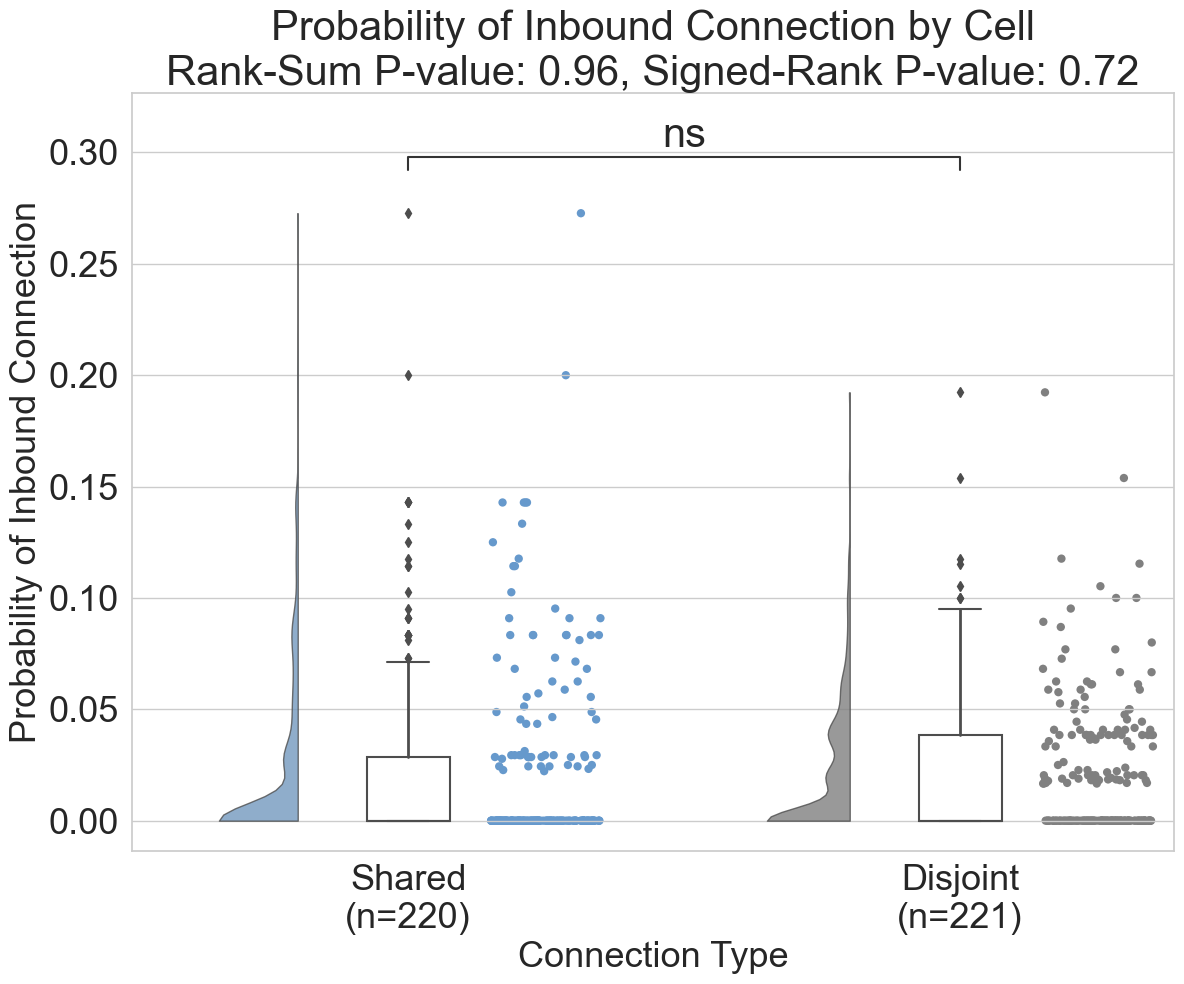

C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:108: RuntimeWarning: divide by zero encountered in log10
  shared_log = np.log10(shared_values)
C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:109: RuntimeWarning: divide by zero encountered in log10
  disjoint_log = np.log10(disjoint_values)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=220) vs. Disjoint
(n=221): Custom statistical test, P_val:9.603e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


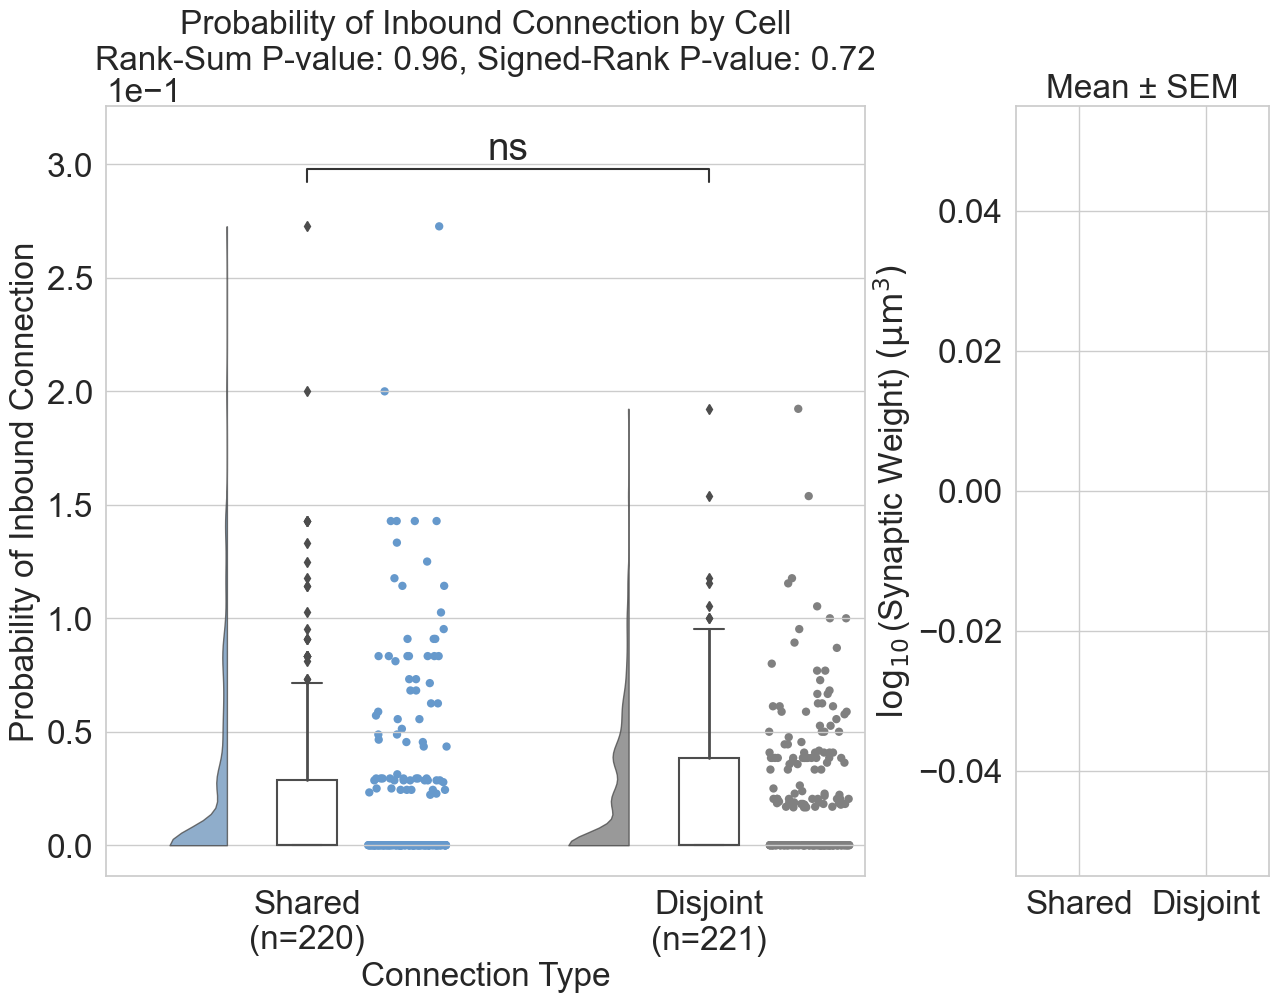

In [13]:
ranksum_signedrank_two_group_comparison(B_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='binary',
                                        paired=True,
                                        save=True,
                                        figure_name='Prob_Inbound_Conn'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.1347, P-value: 0.5536

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=71, n2=103
  Cohen's d        = 0.036
  HL shift         = -0.000130309
  Probability Sup. = 0.494
  Cliff's δ        = -0.012

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.265, 0.331]
  HL:    [-0.00157865, 0.00142374]
  PS:    [0.410, 0.585]
  δ:     [-0.180, 0.170]

P-value stability
  median p = 0.5684
  95% range = [0.02878, 0.9779]
  proportion significant (α=0.05) = 0.040
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 431, P-value: 0.288

[PAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n_pairs=39
  Cohen's d        = 0.165
  HL shift         = 0.000275197
  Probability Sup. = 0.513
  Cliff's δ        = 0.026

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.145, 0.415]
  HL:    [-0.00190998, 0.00312377]
  PS:    [0.359, 

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


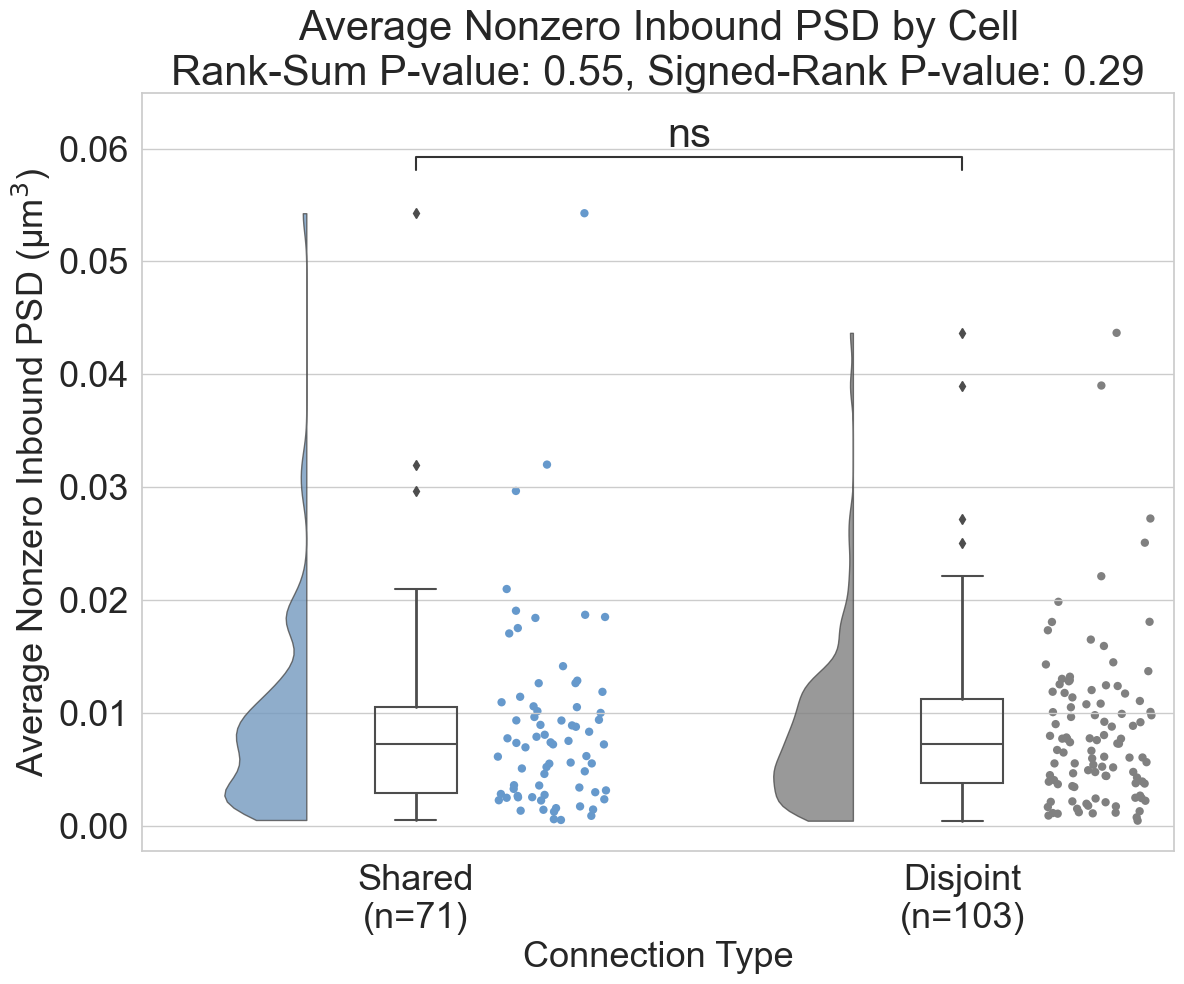

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=71) vs. Disjoint
(n=103): Custom statistical test, P_val:5.536e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


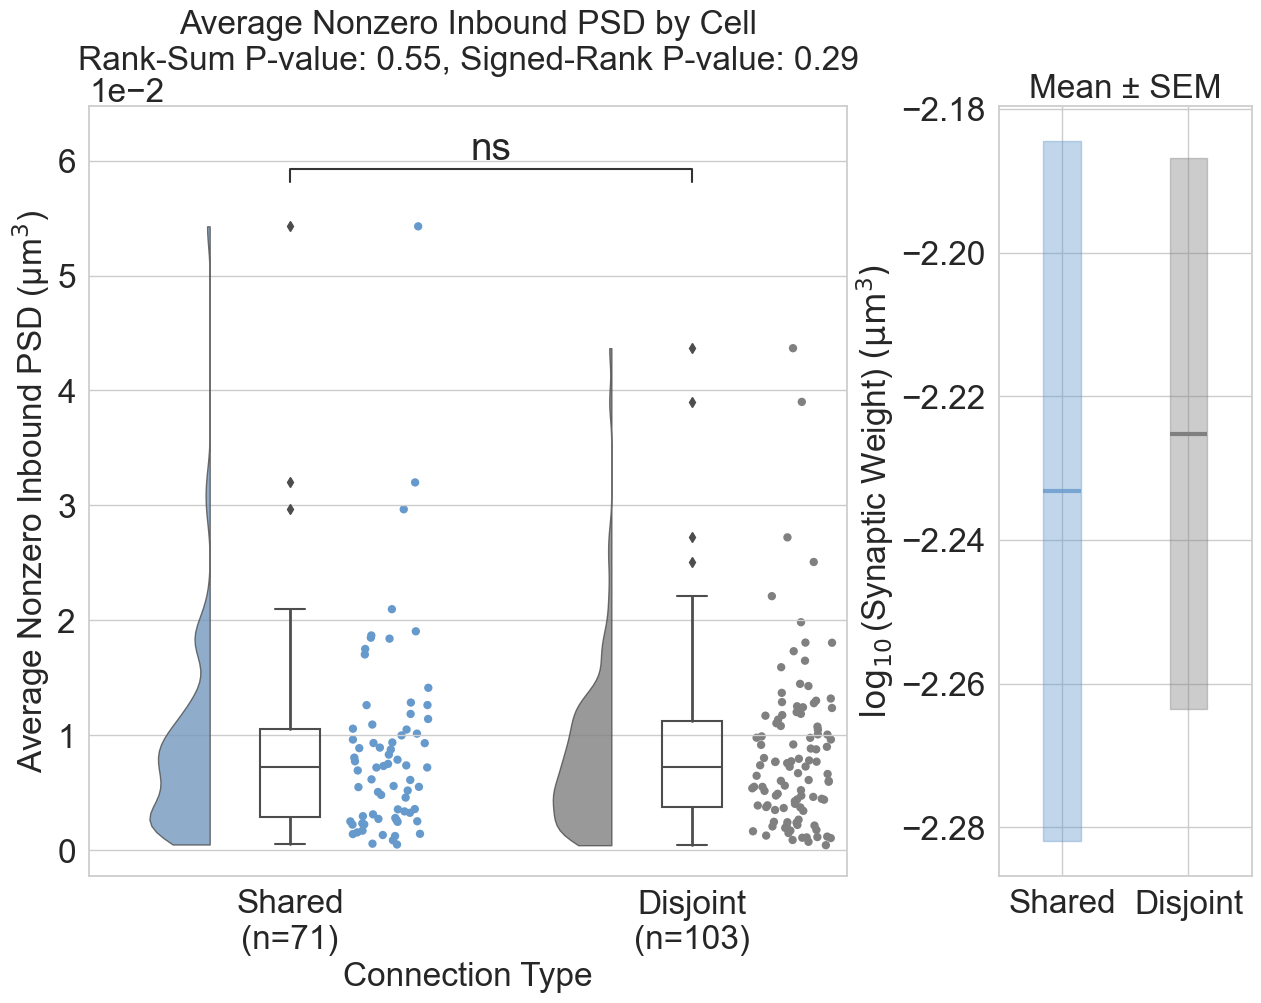

In [14]:
ranksum_signedrank_two_group_comparison(W_nonzero_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        paired=True,
                                        non_zero=True,
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD'
                                        )

# Normalized Synaptic Counts (Mirrored to PSD)

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.3098, P-value: 0.3784

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=107, n2=161
  Cohen's d        = 0.127
  HL shift         = 0
  Probability Sup. = 0.511
  Cliff's δ        = 0.022

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.111, 0.353]
  HL:    [0, 0]
  PS:    [0.486, 0.539]
  δ:     [-0.028, 0.078]

P-value stability
  median p = 0.2072
  95% range = [0.003264, 0.8567]
  proportion significant (α=0.05) = 0.195
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:3.784e-01


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


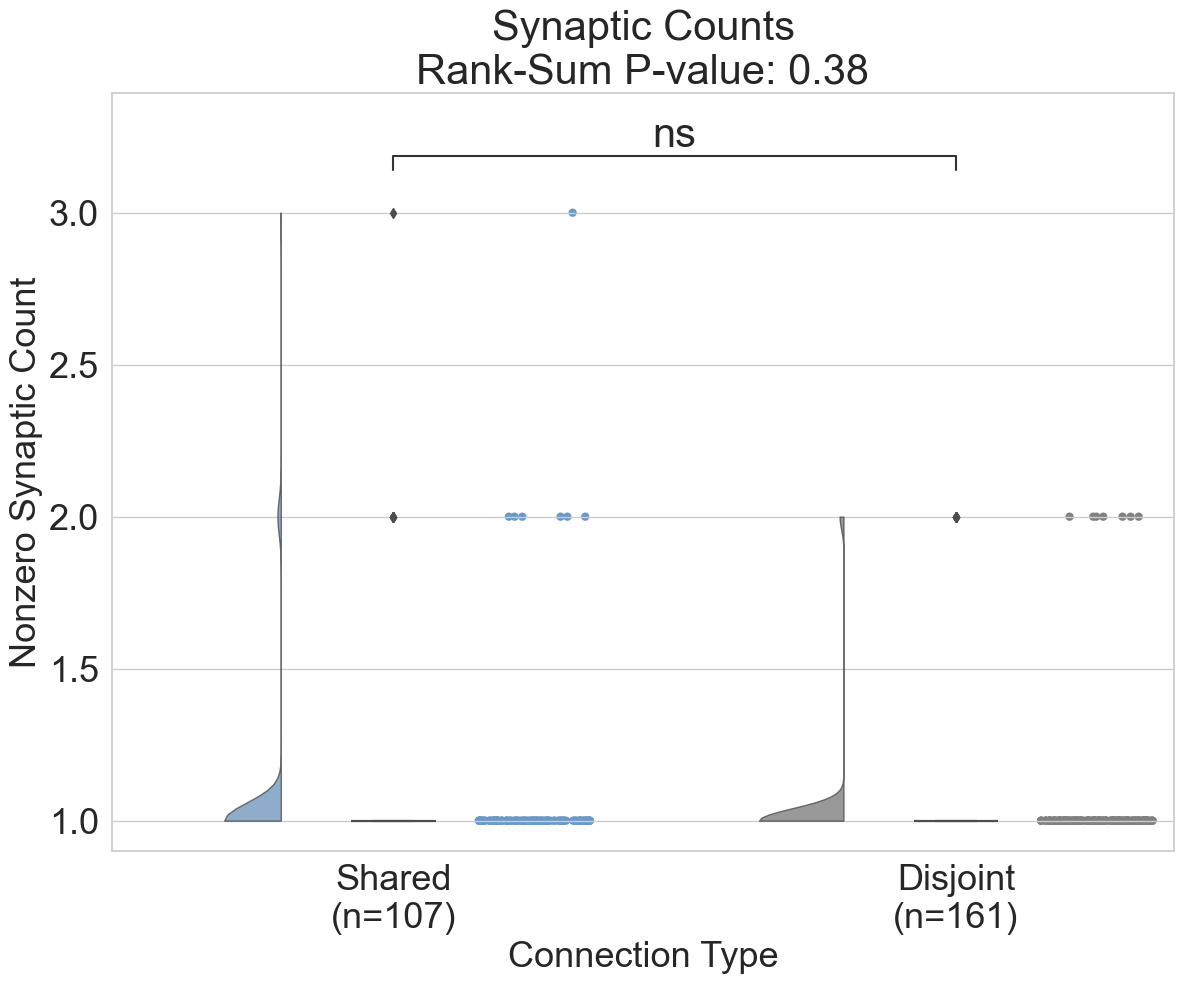

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=107) vs. Disjoint
(n=161): Custom statistical test, P_val:3.784e-01


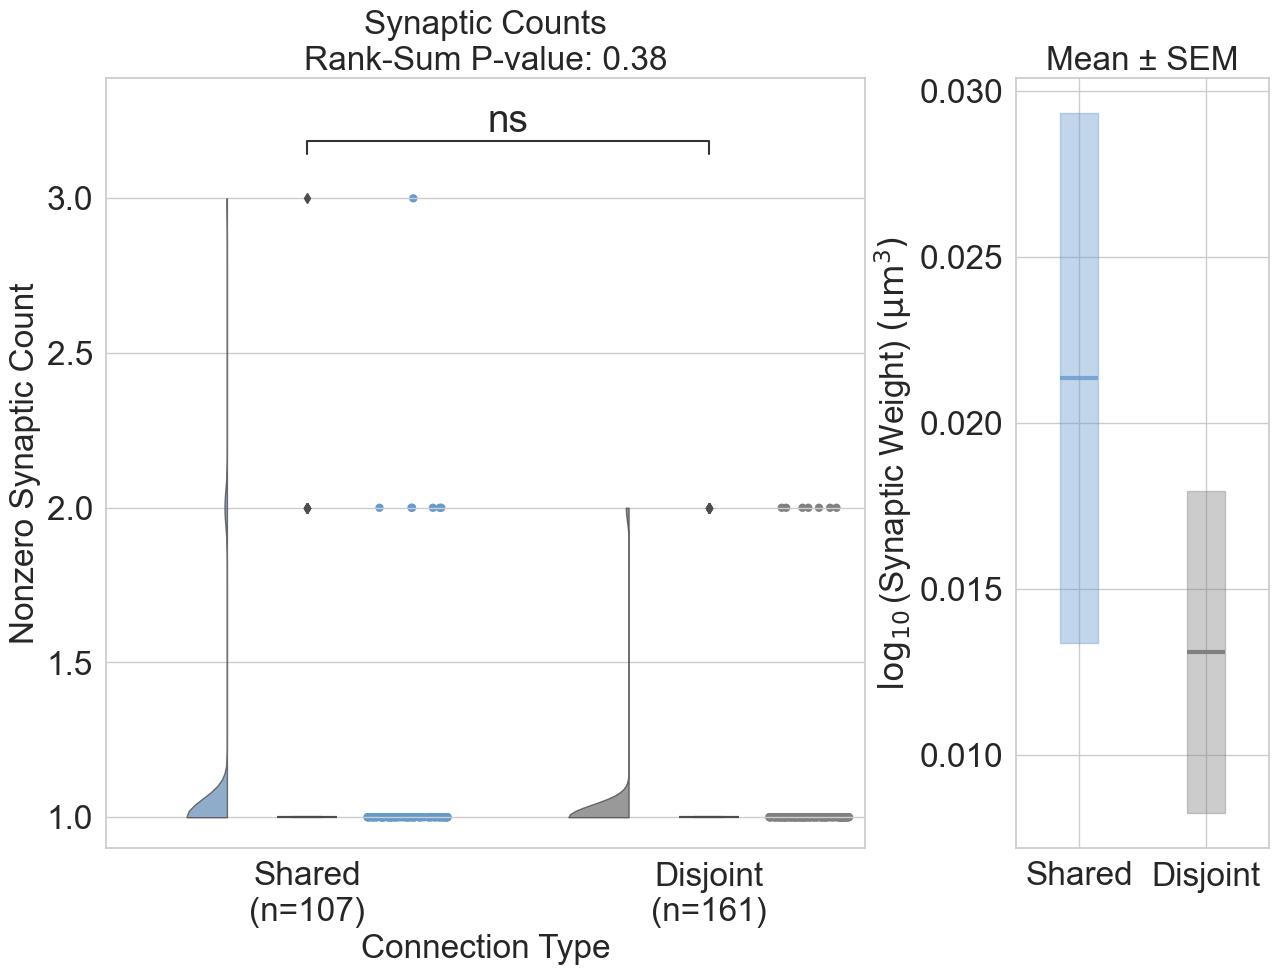

In [15]:
ranksum_signedrank_two_group_comparison(S_nonzero_pairwise,
                                        aggregation_method='connection',
                                        data_type='synaptic_count',
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.3555, P-value: 0.3611

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=39, n2=53
  Cohen's d        = 0.210
  HL shift         = 0
  Probability Sup. = 0.522
  Cliff's δ        = 0.044

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.267, 0.550]
  HL:    [0, 0]
  PS:    [0.455, 0.595]
  δ:     [-0.090, 0.189]

P-value stability
  median p = 0.2695
  95% range = [0.005343, 0.9064]
  proportion significant (α=0.05) = 0.162
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 17.5, P-value: 0.2767

[PAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n_pairs=33
  Cohen's d        = 0.129
  HL shift         = 0
  Probability Sup. = 0.515
  Cliff's δ        = 0.030

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.256, 0.394]
  HL:    [0, 0]
  PS:    [0.439, 0.591]
  δ:     [-0.121, 0.182]

P-value stability
  median

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


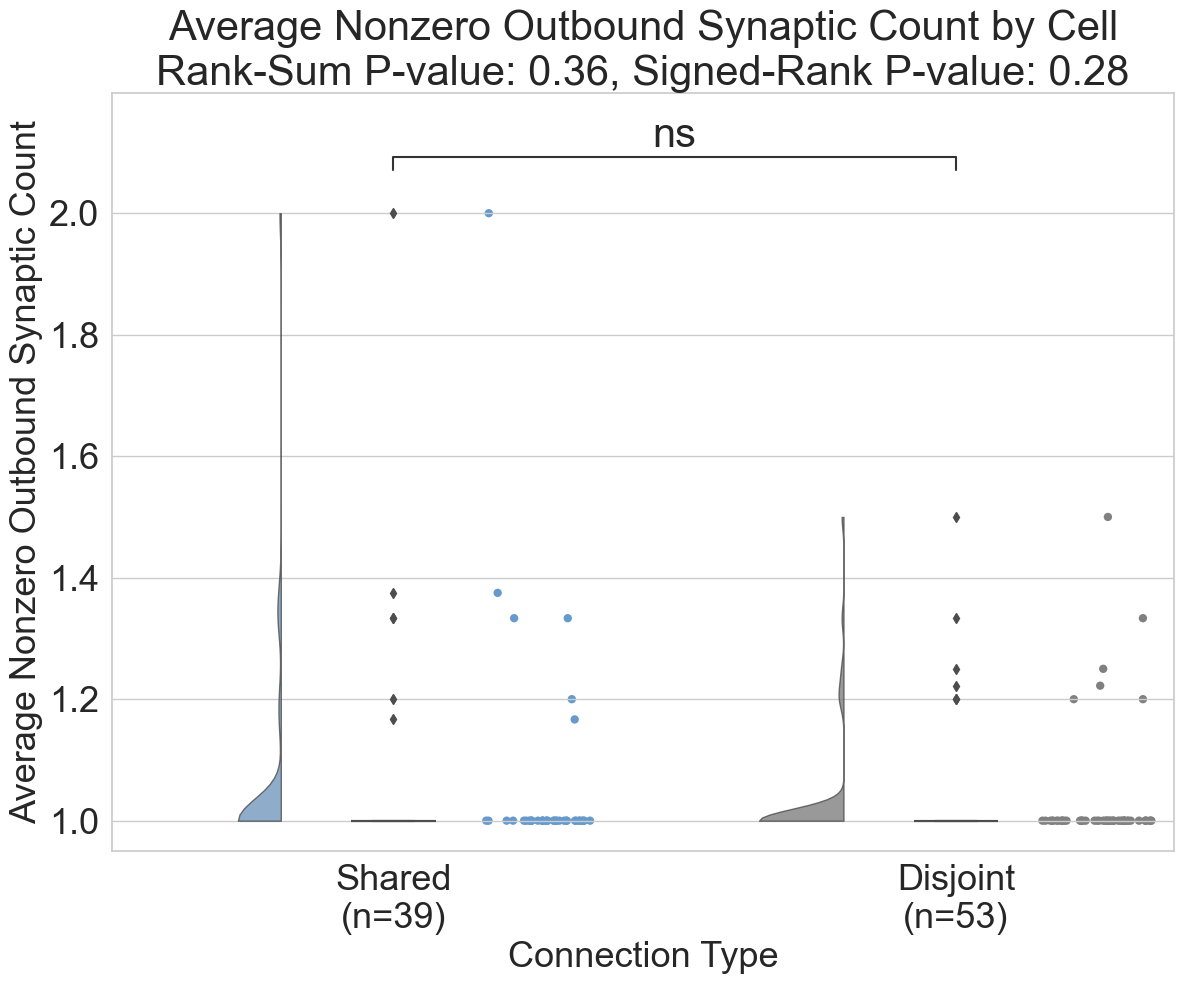

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=39) vs. Disjoint
(n=53): Custom statistical test, P_val:3.611e-01


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


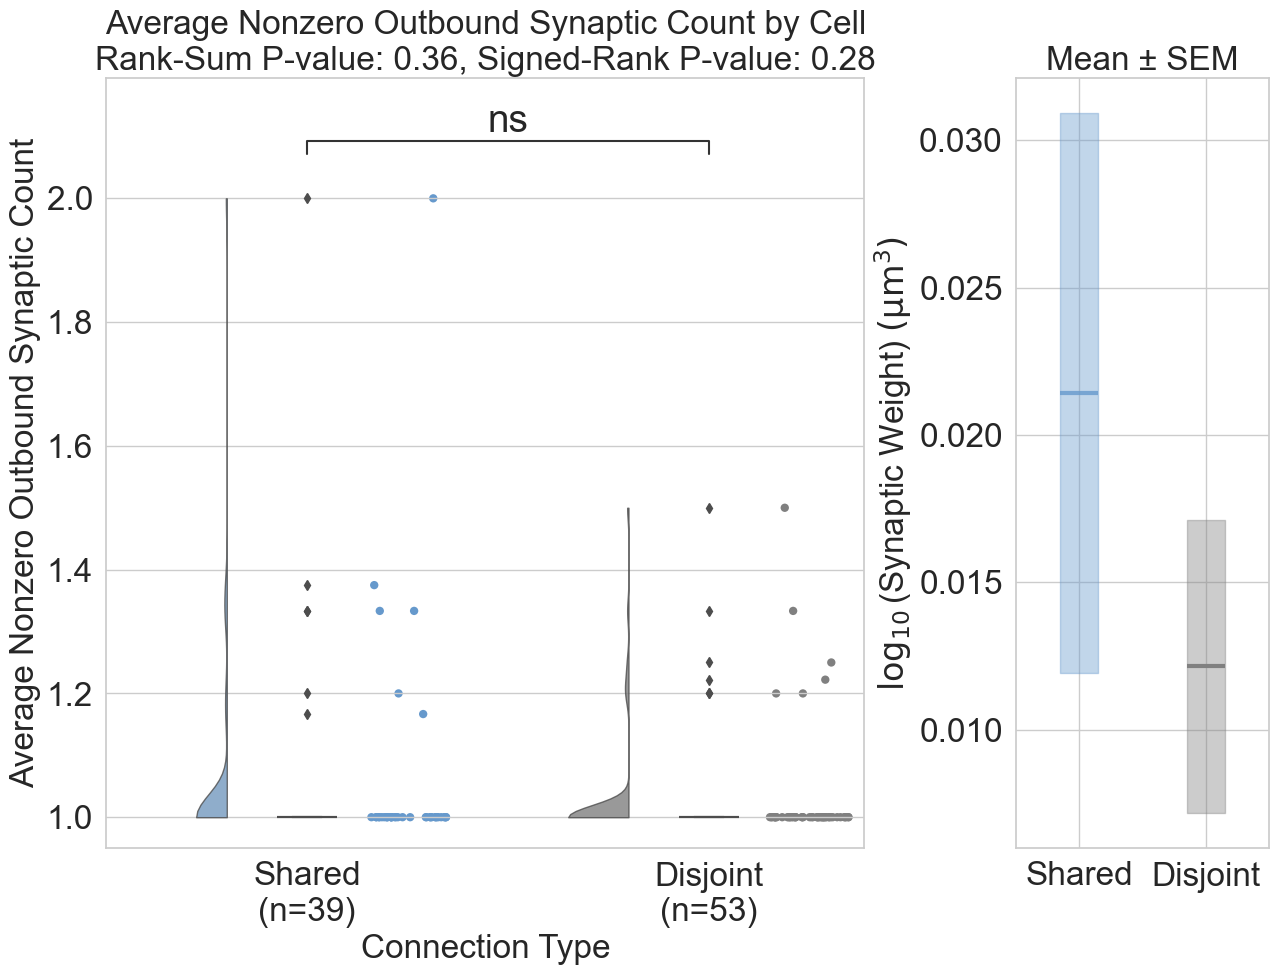

In [16]:
ranksum_signedrank_two_group_comparison(S_nonzero_out,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='synaptic_count',
                                        paired=True,
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.4394, P-value: 0.3302

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=71, n2=103
  Cohen's d        = 0.143
  HL shift         = 0
  Probability Sup. = 0.520
  Cliff's δ        = 0.039

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.195, 0.416]
  HL:    [0, 0]
  PS:    [0.480, 0.563]
  δ:     [-0.040, 0.126]

P-value stability
  median p = 0.1826
  95% range = [0.00141, 0.8487]
  proportion significant (α=0.05) = 0.226
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 13, P-value: 0.2981

[PAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n_pairs=39
  Cohen's d        = 0.105
  HL shift         = 0
  Probability Sup. = 0.526
  Cliff's δ        = 0.051

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.217, 0.362]
  HL:    [0, 0]
  PS:    [0.462, 0.590]
  δ:     [-0.077, 0.179]

P-value stability
  median p

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


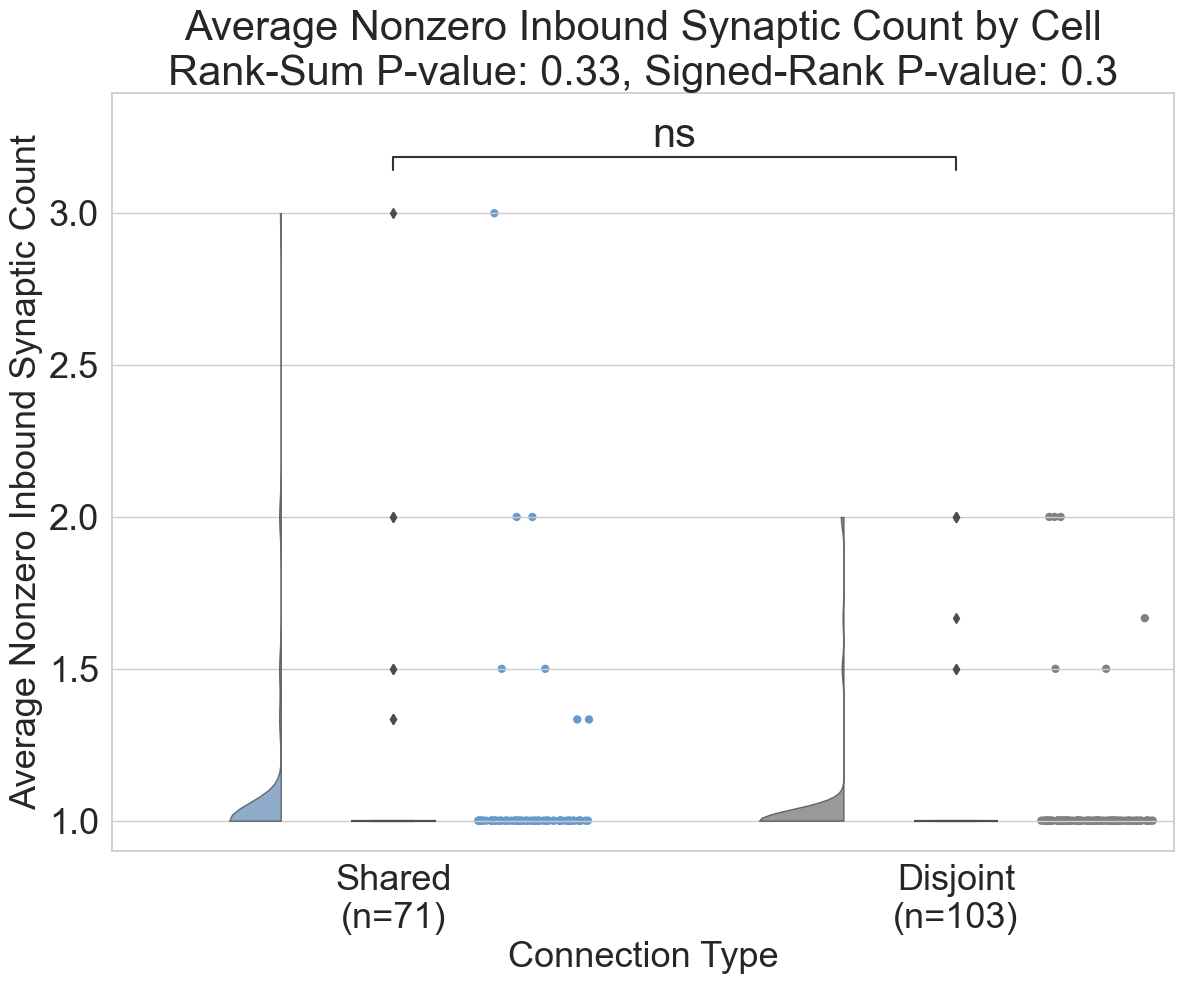

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "
C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=71) vs. Disjoint
(n=103): Custom statistical test, P_val:3.302e-01


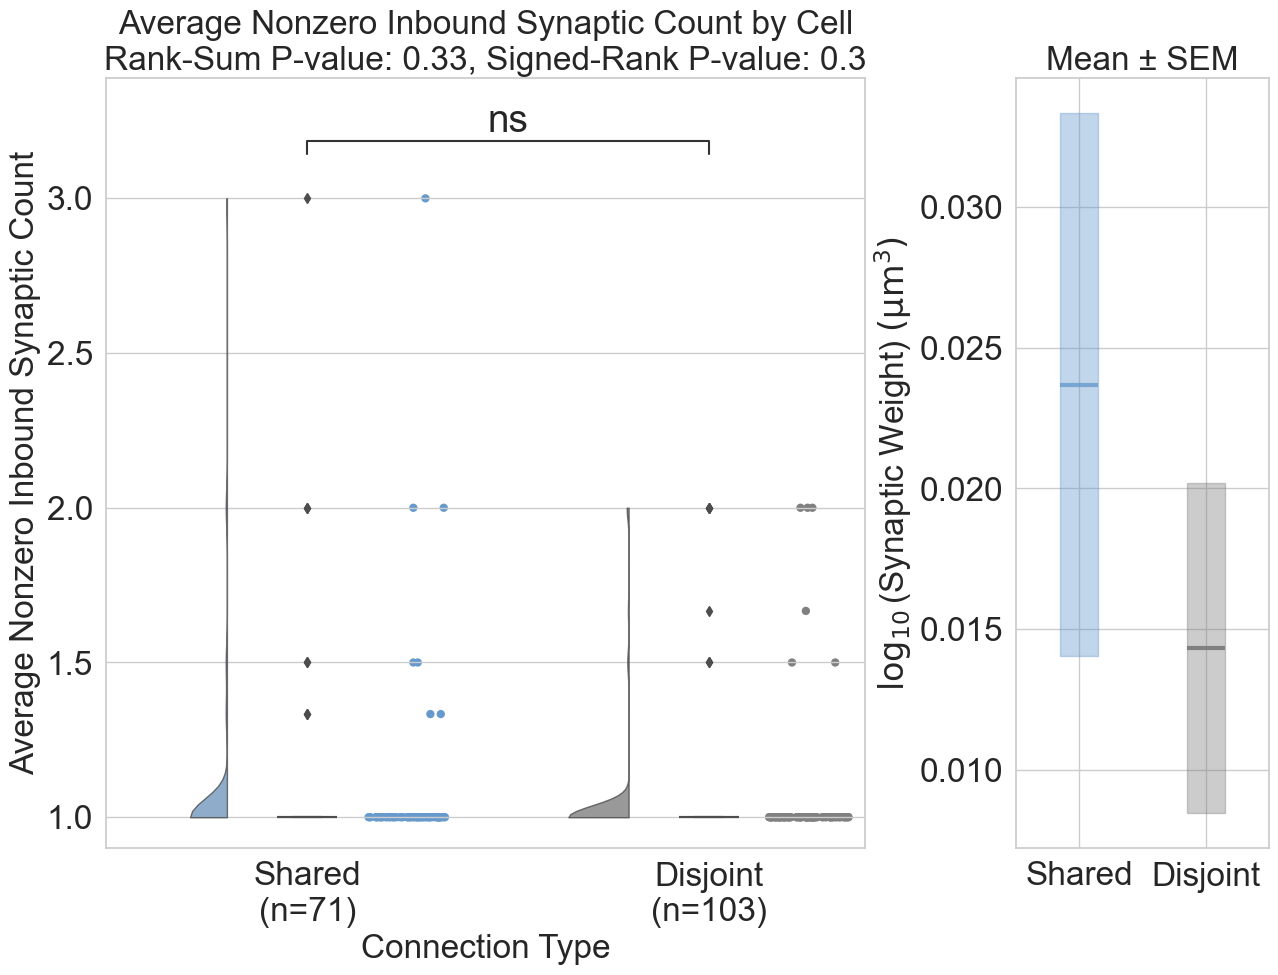

In [17]:
ranksum_signedrank_two_group_comparison(S_nonzero_in,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='synaptic_count',
                                        paired=True,
                                        non_zero=True,
                                        save=False,
                                        figure_name=None
                                        )

## Higher-Order Connectivity Analysis: Centrality

In [18]:
def centrality_bootstrap_effects_and_p(
    comparison_dict: Dict[str, Dict[Any, float]],
    B: int = 1000,
    seed: int = 747,
    alternative: str = "greater",
    alpha: float = 0.05,
    hl_max_pairs: int = 5_000_000,
    paired: bool = False,
    eps_tie: float = 0.0,
    mw_method: str = "asymptotic",
) -> Dict[str, Any]:
    """
    Bootstrap effect sizes and p-values for Group1 vs Group2.

    Groups:
      Group 1 ≡ comparison_dict['shared']   ≡ "All A"
      Group 2 ≡ comparison_dict['disjoint'] ≡ "No A"

    Effect sizes (all signed so that positive = evidence in direction of `alternative`):
      - Cohen's d        (pooled SD for unpaired; within-pair SD for paired)
      - Hodges–Lehmann   (median shift: cross-pair diffs for unpaired; z for paired)
      - PS (Â) and Cliff's δ (PS uses half-credit for ties; δ = 2*PS - 1)

    Tests:
      - Unpaired: Mann–Whitney (one-sided) for U→PS; you may also log rank-sum if desired.
      - Paired  : Wilcoxon signed-rank (one-sided) on z = Group1 - Group2.

    Bootstrap:
      - Unpaired: resample each group independently with replacement.
      - Paired  : resample pair indices with replacement (preserves pairing).

    Returns
    -------
    results : dict with 'point', 'CI95', and 'p_stability' sections.
    """
    rng = default_rng(seed)
    dir_alt = _dir_from_alt(alternative)

    
        # unpaired
    s = np.array(comparison_dict['All A'])
    d = np.array(comparison_dict['No A'])
    if s.size == 0 or d.size == 0:
        raise ValueError("Empty group(s) for unpaired analysis.")

    d_hat  = cohens_d(s, d, alternative=alternative, paired=False)
    HL_hat = hodges_lehmann(s, d, alternative=alternative, paired=False,
                                max_pairs=hl_max_pairs, rng=rng)
    PS_hat, delta_hat = ps_and_delta(s, d, alternative=alternative, paired=False, method=mw_method)

        # one-sided Mann–Whitney p-value consistent with direction
    alt = "greater" if dir_alt > 0 else "less"
    mw  = stats.mannwhitneyu(s, d, alternative=alt, method=mw_method)
    p_point = float(mw.pvalue)

        # bootstrap (resample groups independently)
    n1, n2 = s.size, d.size
    d_b = np.empty(B); hl_b = np.empty(B); delta_b = np.empty(B); ps_b = np.empty(B); p_b = np.empty(B)
    for b in range(B):
        si = rng.integers(0, n1, size=n1)
        di = rng.integers(0, n2, size=n2)
        sb, db = s[si], d[di]
        d_b[b]      = cohens_d(sb, db, alternative=alternative, paired=False)
        hl_b[b]     = hodges_lehmann(sb, db, alternative=alternative, paired=False,
                                         max_pairs=hl_max_pairs, rng=rng)
        A_b, del_b  = ps_and_delta(sb, db, alternative=alternative, paired=False, method=mw_method)
        ps_b[b]     = A_b
        delta_b[b]  = del_b
        p_b[b]      = stats.mannwhitneyu(sb, db, alternative=alt, method=mw_method).pvalue

    # CIs
    def ci(arr): return (float(np.percentile(arr, 2.5)), float(np.percentile(arr, 97.5)))
    d_CI, hl_CI, ps_CI, delta_CI = ci(d_b), ci(hl_b), ci(ps_b), ci(delta_b)

    results = {
        "paired": paired,
        "alternative": alternative,
        "point": {
            "d": float(d_hat),
            "HL": float(HL_hat),
            "PS": float(PS_hat),
            "delta": float(delta_hat),
        },
        "CI95": {
            "d": d_CI,
            "HL": hl_CI,
            "PS": ps_CI,
            "delta": delta_CI,
        },
        "p_stability": {
            "median_p": float(np.median(p_b)),
            "p_95pct_range": (float(np.percentile(p_b, 2.5)), float(np.percentile(p_b, 97.5))),
            "prop_sig_at_alpha": float((p_b < alpha).mean()),
        },
    }

    # Labeled, readable console output
    mode = "PAIRED" if paired else "UNPAIRED"
    n_info = f"n_pairs={len(s)}" if paired else f"n1={len(s)}, n2={len(d)}"
    print(f"\n[{mode}] Effect Size Estimates (positive = in direction of '{alternative}')")
    print(f"  {n_info}")
    print(f"  Cohen's d        = {results['point']['d']:.3f}")
    print(f"  HL shift         = {results['point']['HL']:.6g}")
    print(f"  Probability Sup. = {results['point']['PS']:.3f}")
    print(f"  Cliff's δ        = {results['point']['delta']:.3f}")

    print("\nEffect Size Confidence Intervals (95% percentile bootstrap)")
    print(f"  d:     [{results['CI95']['d'][0]:.3f}, {results['CI95']['d'][1]:.3f}]")
    print(f"  HL:    [{results['CI95']['HL'][0]:.6g}, {results['CI95']['HL'][1]:.6g}]")
    print(f"  PS:    [{results['CI95']['PS'][0]:.3f}, {results['CI95']['PS'][1]:.3f}]")
    print(f"  δ:     [{results['CI95']['delta'][0]:.3f}, {results['CI95']['delta'][1]:.3f}]")

    print("\nP-value stability")
    print(f"  median p = {results['p_stability']['median_p']:.4g}")
    print(f"  95% range = [{results['p_stability']['p_95pct_range'][0]:.4g}, {results['p_stability']['p_95pct_range'][1]:.4g}]")
    print(f"  proportion significant (α={alpha}) = {results['p_stability']['prop_sig_at_alpha']:.3f}")

    return results

def produce_centrality_plot(input_centrality_dict: dict,
                                     just_pyramidal=False,
                                     outdegree=False,
                                     indegree=False, 
                                     closeness=False, 
                                     betweenness=False,
                                     save=False,
                                     figure_name=None):
    """
    Produces a raincloud plot for centrality metrics.

    Parameters:
        input_centrality_dict (dict): Dictionary containing centrality values.
        just_pyramidal (bool): Whether to filter to pyramidal cells only.
        outdegree (bool): Whether to use outdegree centrality.
        indegree (bool): Whether to use indegree centrality.
        closeness (bool): Whether to use closeness centrality.
        betweenness (bool): Whether to use betweenness centrality.

    Returns:
        None
    """
    if outdegree and indegree:
        raise ValueError("Must either be working with outdegree or indegree.")
    if closeness and betweenness:
        raise ValueError("Must either be working with closeness or betweenness.")
    if (outdegree or indegree) and (closeness or betweenness):
        raise ValueError("Must either be working with directionality (indegree/outdegree) or higher-order (betweenness/closeness).")

    suffix = "of Co-Registered Cells"

    # Based on the connectome flags, set the correct y_label and plot title
    if outdegree:
        centrality_desc = "Outdegree_Centrality"
        suffix = "Outdegree Centrality " + suffix
        y_lab = "Outdegree Centrality"
    elif indegree:
        centrality_desc = "Indegree_Centrality"
        suffix = "Indegree Centrality " + suffix
        y_lab = "Indegree Centrality"
    elif closeness: 
        centrality_desc = "Closeness_Centrality"
        suffix = "Closeness Centrality " + suffix
        y_lab = "Closeness Centrality"
    elif betweenness:
        centrality_desc = "Betweenness_Centrality"
        suffix = "Betweenness Centrality " + suffix
        y_lab = "Betweenness Centrality"
    else:
        raise ValueError("Must Specify Degree")

    centrality_dict = {}
    for key in input_centrality_dict.keys():
        centrality_dict[key] = np.array(input_centrality_dict[key])

    all_arr = [centrality_dict['All A'], centrality_dict['No A']]
    result = stats.ranksums(centrality_dict['All A'], centrality_dict['No A'], 'greater')
    print(f"Rank-Sum Test (unpaired, All A > No A):\nStatistic: {result.statistic:.4g}, P-value: {result.pvalue:.4g}")
    centrality_bootstrap_effects_and_p(input_centrality_dict, alternative='greater')

    # Calculate sample sizes
    n_all_a = len(centrality_dict['All A'])
    n_no_a = len(centrality_dict['No A'])

    # Create a figure
    plt.figure(figsize=(12,10))
    sns.set_theme(style="whitegrid")

    # Prepare data for raincloud plot
    data = pd.DataFrame({
        "Values": np.concatenate(all_arr),
        "Group": [f"Assembly\n(n={n_all_a})"] * len(centrality_dict['All A']) + \
                 [f"Non-Assembly\n(n={n_no_a})"] * len(centrality_dict['No A'])
    })

    # Create the raincloud plot
    ax = pt.RainCloud(
        y="Values",
        x="Group",
        data=data,
        palette=[(.4, .6, .8, .5), 'grey'],
        width_viol=0.3,  # Adjust violin width
        alpha=0.8,  # Transparency of the cloud
        move=0.25,  # Adjust position of violins
        point_size = 6,
        orient="v"  # Horizontal orientation
    )

    # Set markings for significance
    y_labels = [f"Assembly\n(n={n_all_a})", f"Non-Assembly\n(n={n_no_a})"]
    pairs = [(y_labels[0], y_labels[1])]
    annot = Annotator(ax, 
                    pairs,
                    data=data,
                    x="Group",
                    y="Values",
                    order=y_labels # Force the order
                    )
    annot.set_pvalues([result.pvalue])
    annot.configure(text_format="star", loc="inside", fontsize=32)
    annot.annotate()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    ax.yaxis.get_offset_text().set_fontsize(32)

    # Add a multiline title to include the p-value, add y_label
    title = f'{suffix}\nRank-Sum P-value: {result.pvalue:.2g}'
    plt.title(title, size=32)
    plt.ylabel(y_lab, size=32)
    plt.xticks(fontsize=32)  # Adjust size of xticks
    plt.yticks(fontsize=32)  # Adjust size of yticks
    plt.xlabel("Assigned Assembly Status", size=32)

    if save == True:
        save_figure(figure_name)

    plt.tight_layout()
    plt.show()

### All Cells Proofread Connectome

In [19]:
# Pull Data from LSMM Data
with open('all_cells_proofread_connectome.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Generating Connectome...


100%|██████████| 137706/137706 [01:37<00:00, 1414.83it/s]


Generating Connectome...


100%|██████████| 137706/137706 [01:35<00:00, 1444.63it/s]


In [20]:
# Calculate Centrality Measurements
binary_connectome = data_a['structural']['binary_connectome']
all_to_all_graph = nx.from_numpy_array(binary_connectome, create_using=nx.DiGraph)

indegree_centrality = nx.in_degree_centrality(all_to_all_graph)
outdegree_centrality = nx.out_degree_centrality(all_to_all_graph)
closeness_centrality = nx.closeness_centrality(all_to_all_graph, wf_improved = True)
betweenness_centrality = nx.betweenness_centrality(all_to_all_graph, normalized= True)

In [21]:
connectome_index_by_assemblies = mappings_a['connectome_indexes_by_assembly']
assembly_connectome_indexes = np.unique(np.concatenate([val for key, val in connectome_index_by_assemblies.items() if key != 'No A']))
no_assembly_connectome_indexes = np.array(list(connectome_index_by_assemblies['No A']))

# Produce Grouped Counts for Inbound and Outbound Connections
indegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
outdegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
closeness_centrality_by_grouped_membership = {'No A': [], 'All A': []}
betweenness_centrality_by_grouped_membership = {'No A': [], 'All A': []}

# Add to dictionaries to plot
for assembly_cell_idx in assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['All A'].append(indegree_centrality[assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['All A'].append(outdegree_centrality[assembly_cell_idx])
    closeness_centrality_by_grouped_membership['All A'].append(closeness_centrality[assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['All A'].append(betweenness_centrality[assembly_cell_idx])
for no_assembly_cell_idx in no_assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['No A'].append(indegree_centrality[no_assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['No A'].append(outdegree_centrality[no_assembly_cell_idx])
    closeness_centrality_by_grouped_membership['No A'].append(closeness_centrality[no_assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['No A'].append(betweenness_centrality[no_assembly_cell_idx])

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.86, P-value: 0.03146

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=61, n2=19
  Cohen's d        = 0.544
  HL shift         = 0.00822562
  Probability Sup. = 0.642
  Cliff's δ        = 0.284

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [0.118, 0.986]
  HL:    [0, 0.0176263]
  PS:    [0.497, 0.771]
  δ:     [-0.006, 0.542]

P-value stability
  median p = 0.03037
  95% range = [0.0001938, 0.5183]
  proportion significant (α=0.05) = 0.593
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:3.146e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


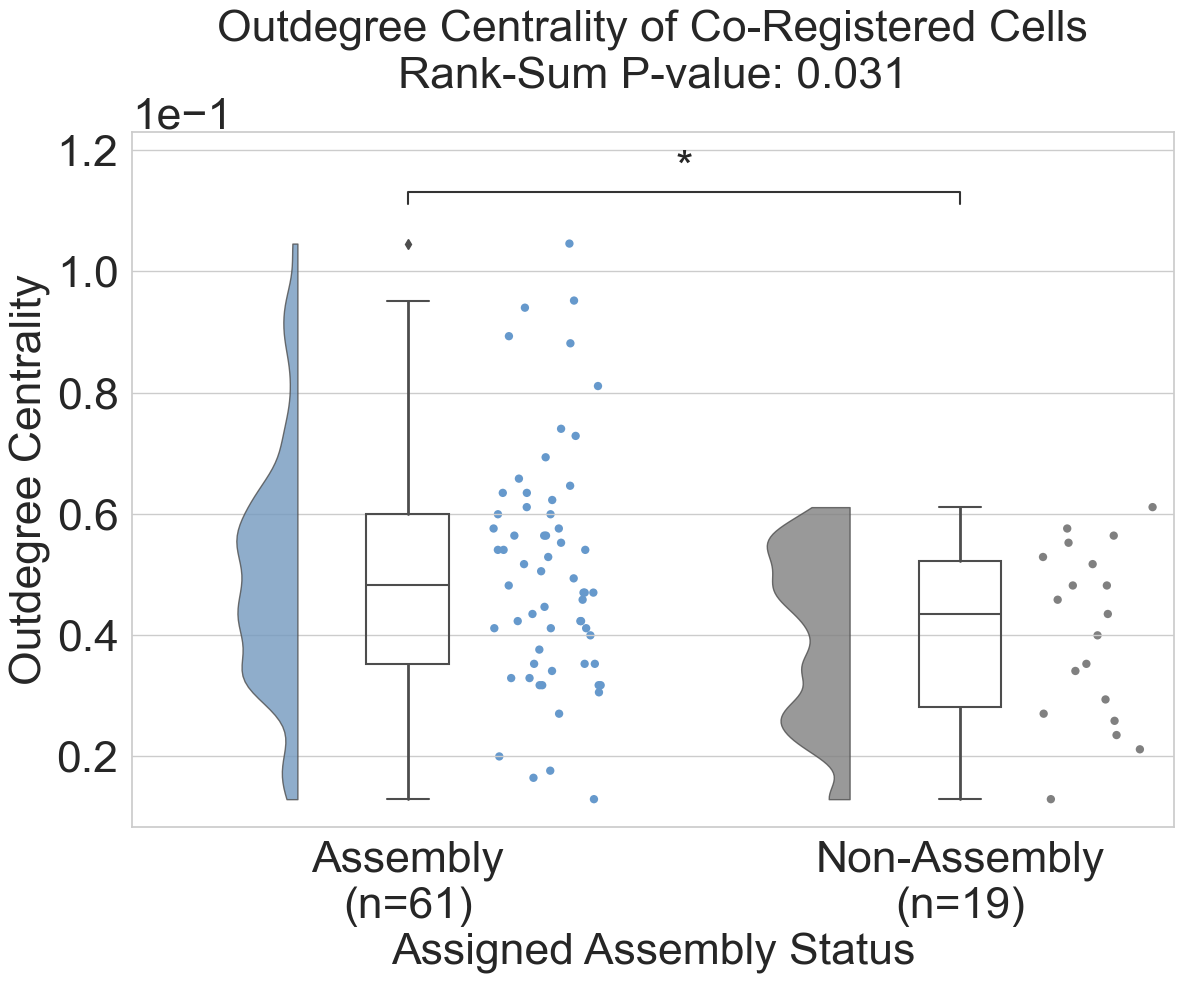

In [22]:
produce_centrality_plot(outdegree_centrality_by_grouped_membership,
                        outdegree = True, save=True, figure_name='Outdegree_Centrality_All')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.747, P-value: 0.04034

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=61, n2=19
  Cohen's d        = 0.491
  HL shift         = 0.0141011
  Probability Sup. = 0.633
  Cliff's δ        = 0.267

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.010, 1.040]
  HL:    [-0.00117509, 0.0282021]
  PS:    [0.488, 0.769]
  δ:     [-0.024, 0.538]

P-value stability
  median p = 0.03191
  95% range = [0.0002124, 0.5652]
  proportion significant (α=0.05) = 0.581
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:4.034e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


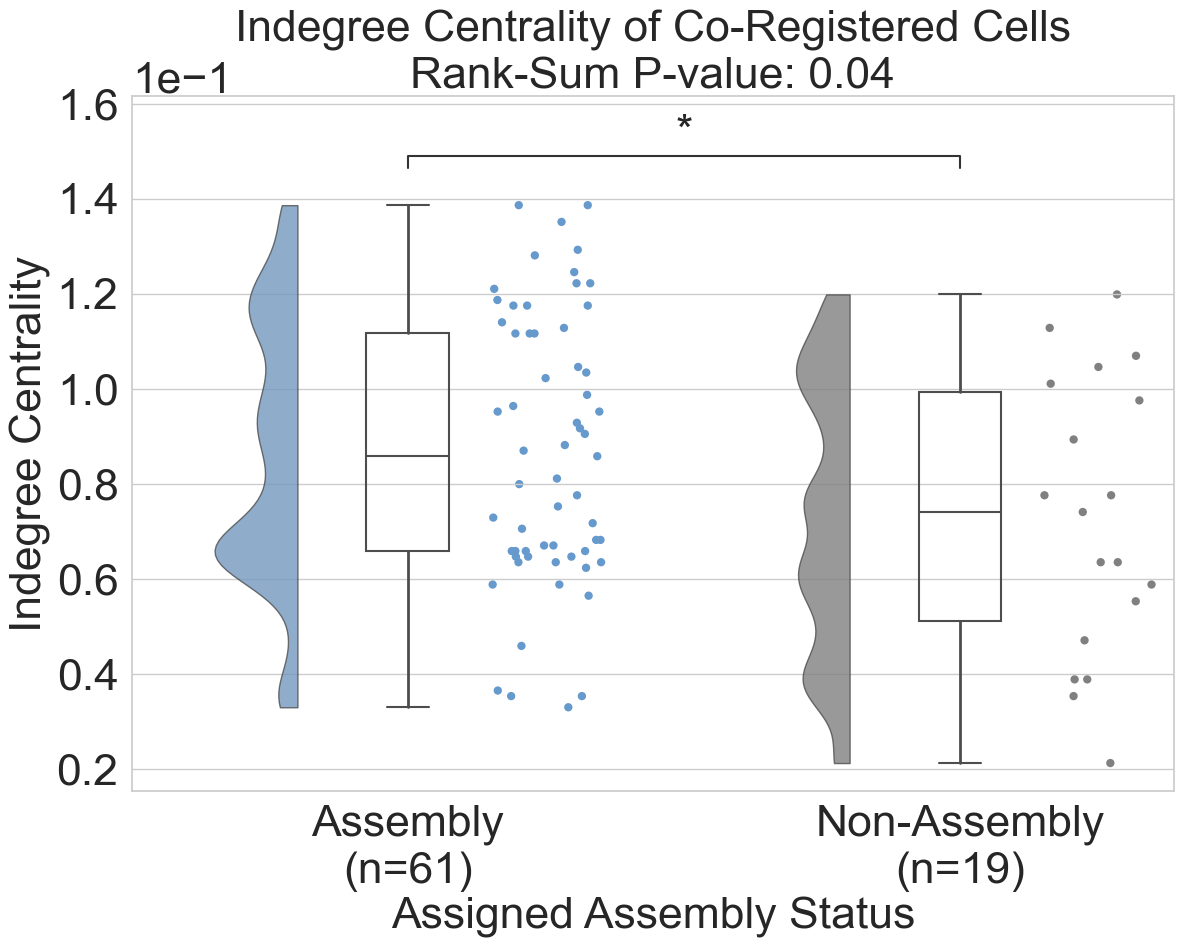

In [23]:
produce_centrality_plot(indegree_centrality_by_grouped_membership,
                        indegree = True, save=True, figure_name='Indegree_Centrality_All')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 2.719, P-value: 0.003273

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=61, n2=19
  Cohen's d        = 0.635
  HL shift         = 0.000106312
  Probability Sup. = 0.708
  Cliff's δ        = 0.415

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [0.221, 1.023]
  HL:    [3.11444e-05, 0.000168546]
  PS:    [0.563, 0.838]
  δ:     [0.125, 0.676]

P-value stability
  median p = 0.002701
  95% range = [4.882e-06, 0.2077]
  proportion significant (α=0.05) = 0.882
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:3.273e-03


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


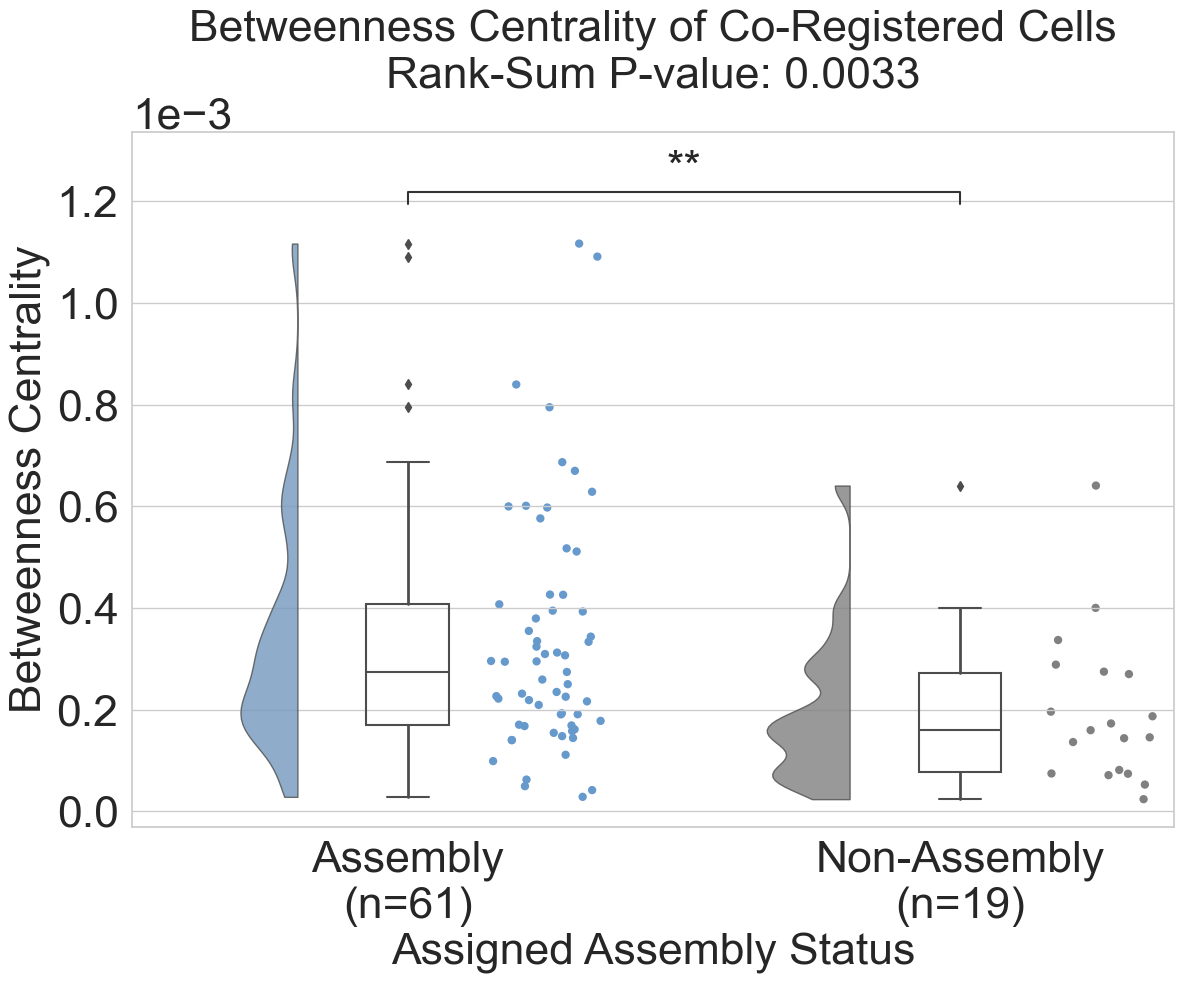

In [24]:
produce_centrality_plot(betweenness_centrality_by_grouped_membership,
                        betweenness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Betweenness_Centrality_Pyr')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.413, P-value: 0.07879

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=61, n2=19
  Cohen's d        = 0.391
  HL shift         = 0.00577382
  Probability Sup. = 0.608
  Cliff's δ        = 0.216

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.119, 0.945]
  HL:    [-0.00209518, 0.0154273]
  PS:    [0.462, 0.745]
  δ:     [-0.075, 0.490]

P-value stability
  median p = 0.06996
  95% range = [0.0006698, 0.6907]
  proportion significant (α=0.05) = 0.427
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:7.879e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


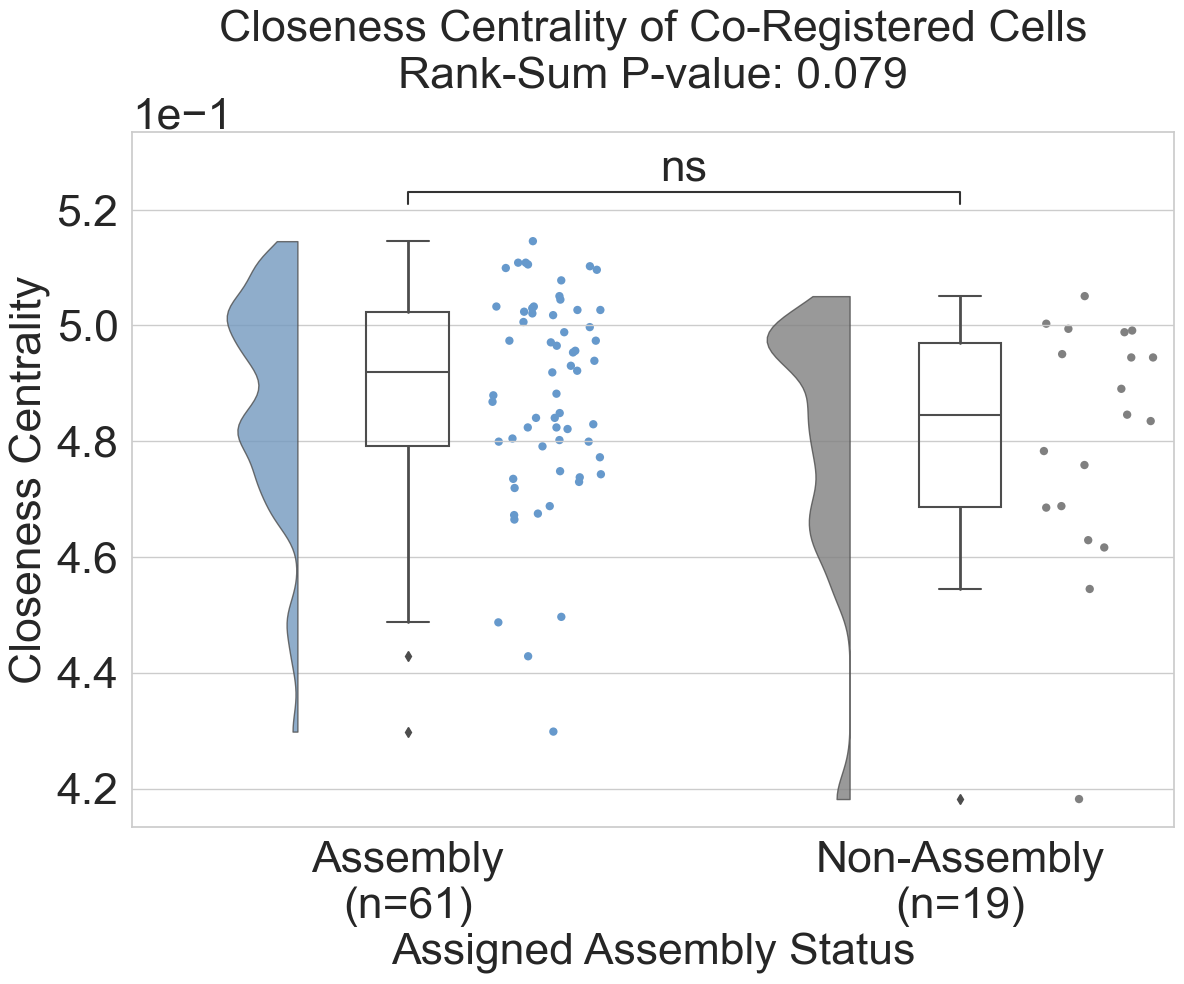

In [25]:
produce_centrality_plot(closeness_centrality_by_grouped_membership,
                        closeness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Closeness_Centrality_Pyr')

### Pyramidal Cells Proofread Connectome

In [26]:
# Pull Data from LSMM Data
with open('pyr_cells_proofread_connectome.json') as f:
    lsmm_json_input = json.load(f)
v1dd_data = LSMMData.LSMMData(lsmm_json_input)

data_a = v1dd_data.data
params_a = v1dd_data.params
dirs_a = v1dd_data.dirs
mappings_a = v1dd_data.mappings

Filtering to pyramidal cells only
459
Generating Connectome...


100%|██████████| 4565/4565 [00:01<00:00, 3112.60it/s]


Generating Connectome...


100%|██████████| 4565/4565 [00:01<00:00, 2980.27it/s]


In [27]:
# Calculate Centrality Measurements
binary_connectome = data_a['structural']['binary_connectome']
all_to_all_graph = nx.from_numpy_array(binary_connectome, create_using=nx.DiGraph)

indegree_centrality = nx.in_degree_centrality(all_to_all_graph)
outdegree_centrality = nx.out_degree_centrality(all_to_all_graph)
closeness_centrality = nx.closeness_centrality(all_to_all_graph, wf_improved = True)
betweenness_centrality = nx.betweenness_centrality(all_to_all_graph, normalized= True)

In [28]:
connectome_index_by_assemblies = mappings_a['connectome_indexes_by_assembly']
assembly_connectome_indexes = np.unique(np.concatenate([val for key, val in connectome_index_by_assemblies.items() if key != 'No A']))
no_assembly_connectome_indexes = np.array(list(connectome_index_by_assemblies['No A']))

# Produce Grouped Counts for Inbound and Outbound Connections
indegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
outdegree_centrality_by_grouped_membership = {'No A': [], 'All A': []}
closeness_centrality_by_grouped_membership = {'No A': [], 'All A': []}
betweenness_centrality_by_grouped_membership = {'No A': [], 'All A': []}

# Add to dictionaries to plot
for assembly_cell_idx in assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['All A'].append(indegree_centrality[assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['All A'].append(outdegree_centrality[assembly_cell_idx])
    closeness_centrality_by_grouped_membership['All A'].append(closeness_centrality[assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['All A'].append(betweenness_centrality[assembly_cell_idx])
for no_assembly_cell_idx in no_assembly_connectome_indexes:
    indegree_centrality_by_grouped_membership['No A'].append(indegree_centrality[no_assembly_cell_idx])
    outdegree_centrality_by_grouped_membership['No A'].append(outdegree_centrality[no_assembly_cell_idx])
    closeness_centrality_by_grouped_membership['No A'].append(closeness_centrality[no_assembly_cell_idx])
    betweenness_centrality_by_grouped_membership['No A'].append(betweenness_centrality[no_assembly_cell_idx])

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.899, P-value: 0.02876

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=61, n2=19
  Cohen's d        = 0.571
  HL shift         = 0.00436681
  Probability Sup. = 0.645
  Cliff's δ        = 0.290

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [0.277, 0.851]
  HL:    [0, 0.00873362]
  PS:    [0.515, 0.760]
  δ:     [0.030, 0.520]

P-value stability
  median p = 0.02989
  95% range = [0.0003042, 0.4234]
  proportion significant (α=0.05) = 0.614
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:2.876e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


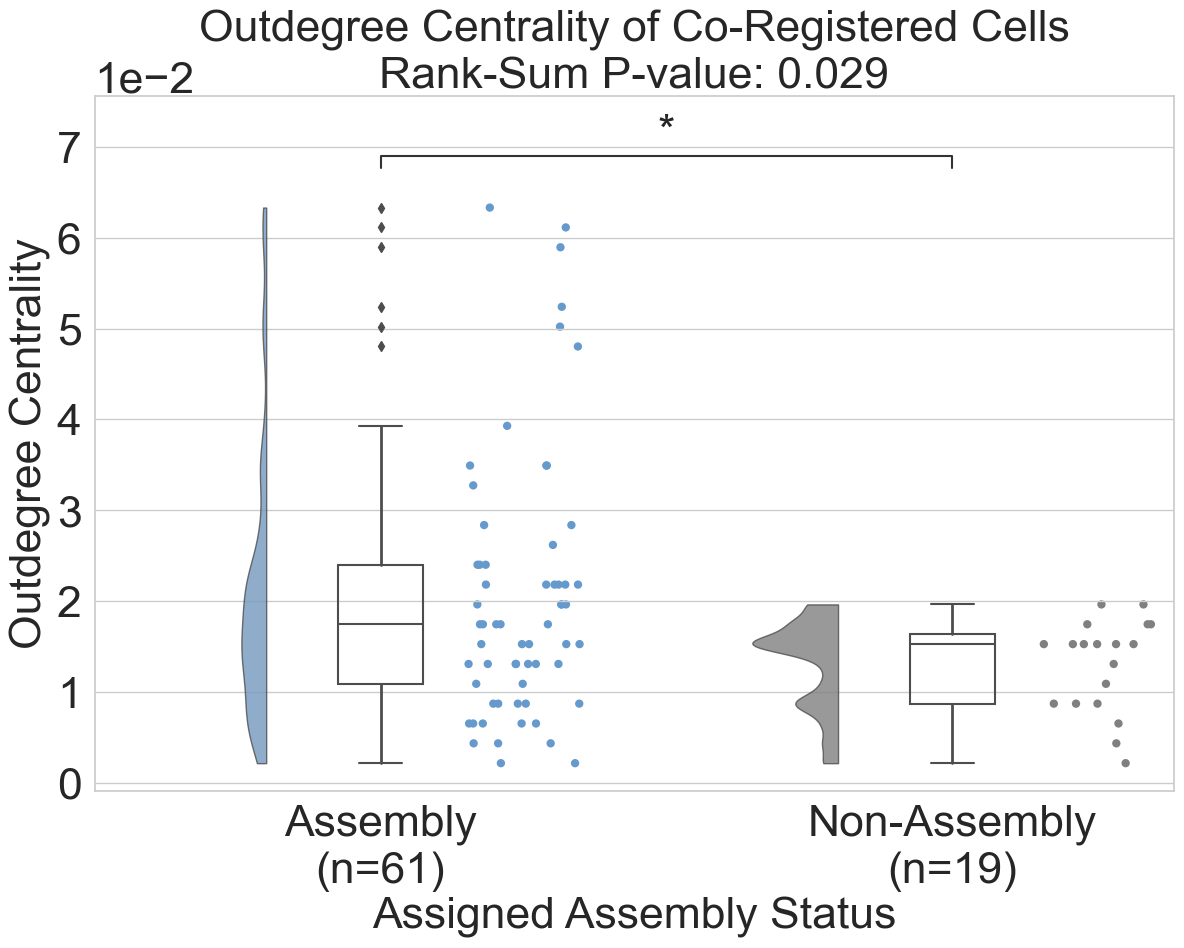

In [29]:
produce_centrality_plot(outdegree_centrality_by_grouped_membership,
                        outdegree = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Outdegree_Centrality_Pyr')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.538, P-value: 0.06207

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=61, n2=19
  Cohen's d        = 0.393
  HL shift         = 0.00218341
  Probability Sup. = 0.617
  Cliff's δ        = 0.235

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.086, 0.888]
  HL:    [0, 0.00873362]
  PS:    [0.466, 0.749]
  δ:     [-0.067, 0.498]

P-value stability
  median p = 0.05751
  95% range = [0.0005253, 0.6733]
  proportion significant (α=0.05) = 0.477
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:6.207e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


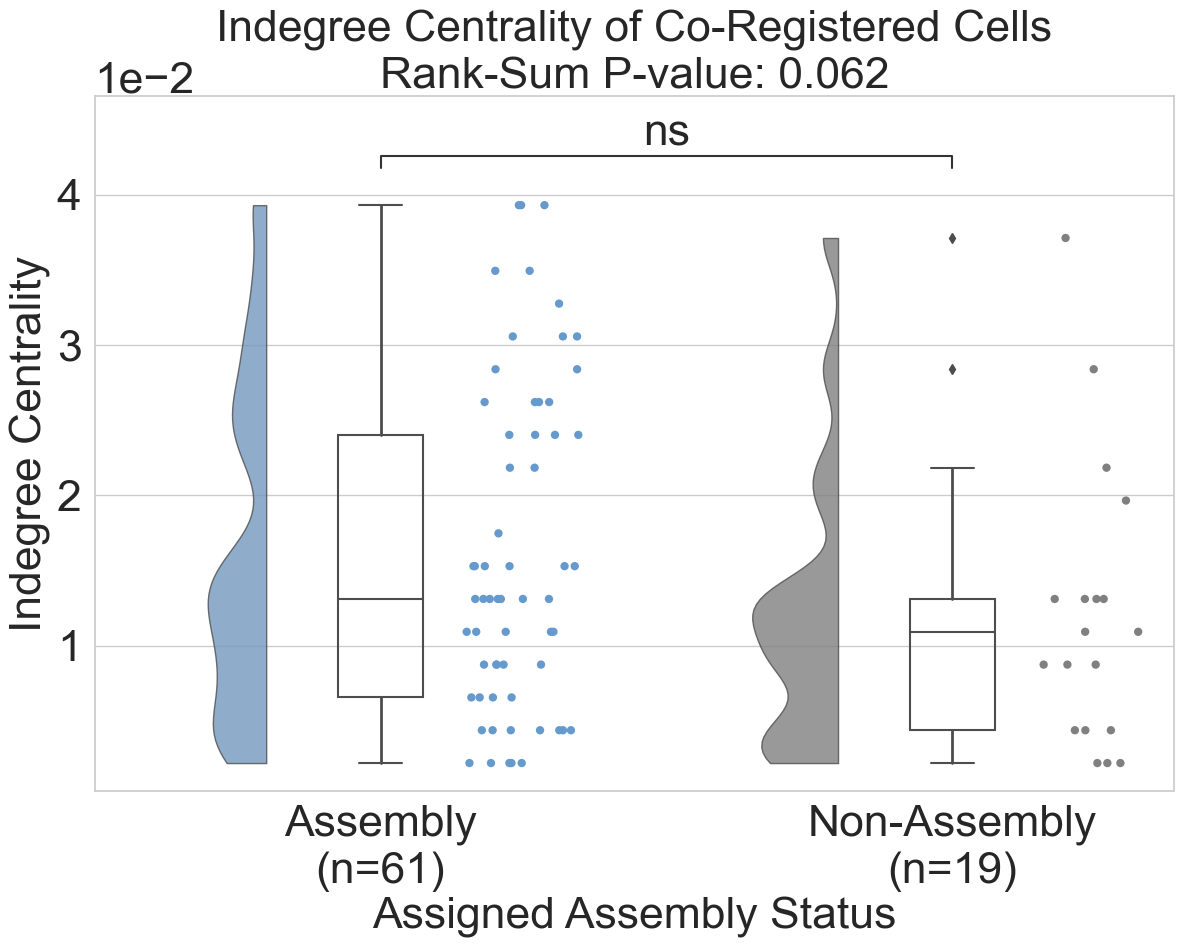

In [30]:
produce_centrality_plot(indegree_centrality_by_grouped_membership,
                        indegree = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Indegree_Centrality_Pyr')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 1.894, P-value: 0.02913

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=61, n2=19
  Cohen's d        = 0.477
  HL shift         = 0.00106893
  Probability Sup. = 0.645
  Cliff's δ        = 0.289

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [0.143, 0.765]
  HL:    [1.28675e-05, 0.00215889]
  PS:    [0.500, 0.779]
  δ:     [0.001, 0.558]

P-value stability
  median p = 0.02726
  95% range = [0.0001296, 0.5002]
  proportion significant (α=0.05) = 0.624
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:2.913e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


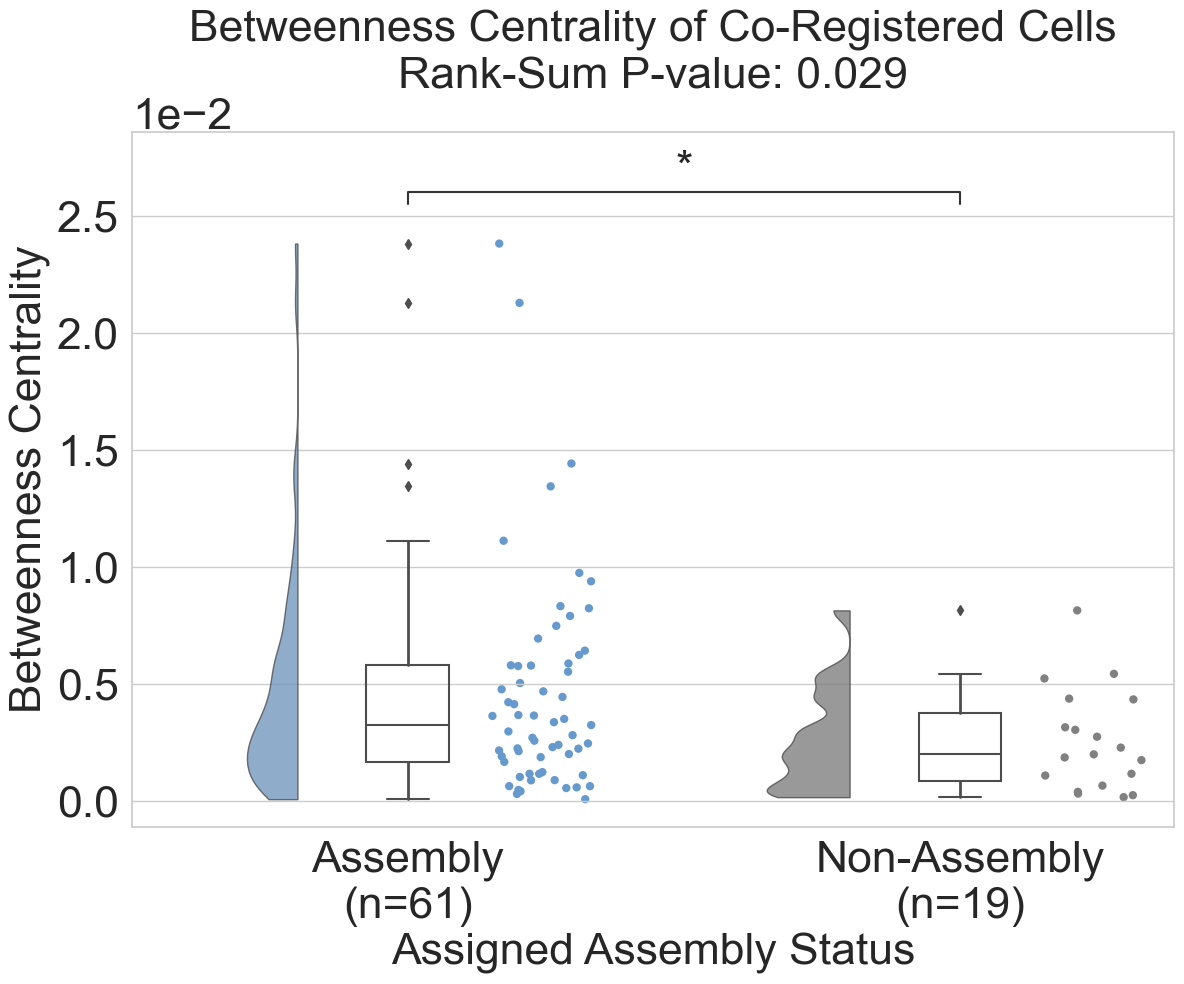

In [31]:
produce_centrality_plot(betweenness_centrality_by_grouped_membership,
                        betweenness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Betweenness_Centrality_Pyr')

Rank-Sum Test (unpaired, All A > No A):
Statistic: 0.8423, P-value: 0.1998

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=61, n2=19
  Cohen's d        = 0.132
  HL shift         = 0.00773406
  Probability Sup. = 0.564
  Cliff's δ        = 0.129

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.275, 0.705]
  HL:    [-0.00986201, 0.0285218]
  PS:    [0.417, 0.705]
  δ:     [-0.167, 0.411]

P-value stability
  median p = 0.1888
  95% range = [0.003608, 0.8638]
  proportion significant (α=0.05) = 0.205
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Assembly
(n=61) vs. Non-Assembly
(n=19): Custom statistical test, P_val:1.998e-01


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


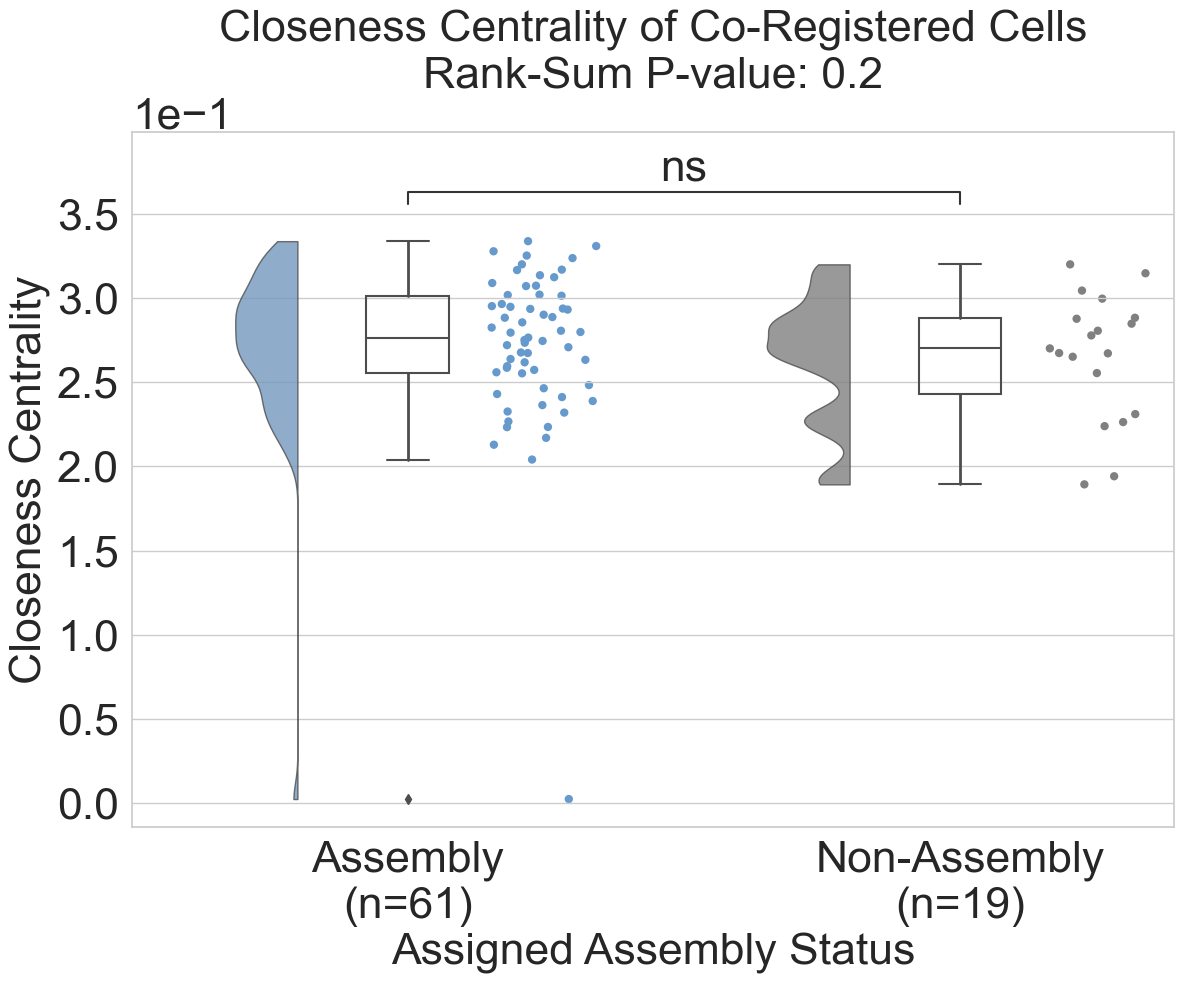

In [32]:
produce_centrality_plot(closeness_centrality_by_grouped_membership,
                        closeness = True,
                        just_pyramidal = True, 
                        save=True,
                        figure_name='Closeness_Centrality_Pyr')

# Chains: Standard

In [33]:
with open('all_cells_proofread_connectome.json') as f:
    loaded_json = json.load(f)
my_data = LSMMData.LSMMData(loaded_json)
# with open('pyr_rect.data', 'wb') as f:
#     pickle.dump(my_data, f)

data_a = my_data.data
params_a = my_data.params
dirs_a = my_data.dirs
mappings_a = my_data.mappings

Generating Connectome...


100%|██████████| 137706/137706 [01:32<00:00, 1485.53it/s]


Generating Connectome...


100%|██████████| 137706/137706 [01:42<00:00, 1338.90it/s]


In [34]:
# Make a graph
cell_table = data_a['structural']['pre_cell'].copy()
cell_table['connectome_index'] = cell_table.index
post_cell_table = data_a['structural']['post_cell'].copy()
post_cell_table['connectome_index'] = post_cell_table.index

synapse_table = data_a['structural']['synapse']
# adjacency_matrix = data_a['structural']['binary_connectome']
binary_connectome = data_a['structural']['binary_connectome']

index_to_root_id = [mappings_a['connectome_index_to_root_id'][i] for i in range(binary_connectome.shape[0])]

summed_size_connectome = data_a['structural']['summed_size_connectome']
summed_size_connectome_df = pd.DataFrame(
    summed_size_connectome,
    index=index_to_root_id,
    columns=index_to_root_id
)

pyr_graph = nx.from_numpy_array(binary_connectome, create_using=nx.DiGraph)
pyr_graph = nx.relabel_nodes(pyr_graph, {i: index_to_root_id[i] for i in range(len(index_to_root_id))})

# Or uncomment below to generate new motif analysis results (Can take quite a while on larger graphs)
# Motif Analysis with DotMotif: 2 Chain, All Pyr
executor = GrandIsoExecutor(graph= pyr_graph)
chain_defs = Motif("""
                A -> B
                B -> C
              """)

chain_results = executor.find(chain_defs)

two_chain_results_array = np.array([list(c.values()) for c in tqdm(chain_results)])

### Pool necessary Data
chain_count_string_array = ['pyr_cell_2chain']
individual_assembly_indexes = [mappings_a['connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]
individual_post_assembly_indexes = [mappings_a['post_connectome_indexes_by_assembly'][f'A {i}'] for i in range(1,16)]

coregistered_post_cell_indexes = mappings_a['assemblies_by_post_connectome_index'].keys()
coregistered_cell_indexes = mappings_a['assemblies_by_connectome_index'].keys()
no_a_cell_indexes = mappings_a['connectome_indexes_by_assembly']['No A']
no_a_post_cell_indexes = mappings_a['post_connectome_indexes_by_assembly']['No A']
pooled_assembly_indexes = list(set(coregistered_cell_indexes) - set(no_a_cell_indexes))
pooled_assembly_post_indexes = list(set(coregistered_post_cell_indexes) - set(no_a_post_cell_indexes))

assembly_to_root_ids = mappings_a['pt_root_ids_by_assembly']
assembly_root_ids_set = set(mappings_a['assemblies_by_pt_root_id'].keys())

# Filter synapses_table to only synapses between two assembly cells (including No A)
synapses_df = synapse_table[synapse_table['pre_pt_root_id'].isin(assembly_root_ids_set)]
synapses_df = synapses_df[synapses_df['post_pt_root_id'].isin(assembly_root_ids_set)]

# Filter cell tables to only assembly cells (including 'No A')
assembly_cell_table = cell_table[cell_table['pt_root_id'].isin(assembly_root_ids_set)]
assembly_post_cell_table = post_cell_table[post_cell_table['pt_root_id'].isin(assembly_root_ids_set)]

assembly_pre_root_ids = set(assembly_cell_table['pt_root_id'].values)
assembly_post_root_ids = set(assembly_post_cell_table['pt_root_id'].values)
all_root_ids = assembly_pre_root_ids | assembly_post_root_ids

100%|██████████| 6052393/6052393 [00:05<00:00, 1137028.47it/s]


In [35]:
# Initialize dictionaries to store weights and binary connectivity
W_chain_excitatory = {}
W_chain_inhibitory = {}
B_chain_excitatory = {}
B_chain_inhibitory = {}

# Define all potential (pre-cell, post-cell) pairs with excitatory and inhibitory chain types
for j in all_root_ids:
    for i in all_root_ids:
        if j != i:  # Exclude autapses
            W_chain_excitatory[(j, i)] = 0
            W_chain_inhibitory[(j, i)] = 0
            B_chain_excitatory[(j, i)] = 0
            B_chain_inhibitory[(j, i)] = 0

pt_root_id_to_classification = cell_table.set_index('pt_root_id')['classification_system'].to_dict()

# Process each row in `two_chain_results_array` to populate weights and binary connectivity
for _, row in enumerate(two_chain_results_array):
    pre_cell, mid_cell, post_cell = row  # j: pre-cell, k: middle cell, i: post-cell
    if pre_cell in all_root_ids and post_cell in all_root_ids:
    # Determine chain type (excitatory if middle cell is in excitatory set, else inhibitory)
        if pt_root_id_to_classification[mid_cell] == 'inhibitory':
            W_chain = W_chain_inhibitory
            B_chain = B_chain_inhibitory
        elif pt_root_id_to_classification[mid_cell] == 'excitatory':
            W_chain = W_chain_excitatory
            B_chain = B_chain_excitatory
    # Get synapse weights for connections j -> k and k -> i
        w_jk = summed_size_connectome_df.loc[pre_cell, mid_cell] * (9 * 9 * 45) / (10**9) # cubic micrometers
        w_ki = summed_size_connectome_df.loc[mid_cell, post_cell] * (9 * 9 * 45) / (10**9) # cubic micrometers
    
    # Updates weights and binary connectivity
        W_chain[(pre_cell, post_cell)] += (w_jk * w_ki)
        B_chain[(pre_cell, post_cell)] = 1

In [36]:
## PARIWISE NONZERO PSD and CONNECTION PROBABILITY BY CONNECTION TYPE
# Aggregate nonzero pairs and calculate connectivity probabilities by connection type
W_chain_nonzero_pairwise_excitatory = {}
W_chain_nonzero_pairwise_inhibitory = {}
B_chain_pairwise_excitatory = {}
B_chain_pairwise_inhibitory = {}

for cond_function in comparison_functions:
    # Initialize dictionaries per connection type
    W_chain_nonzero_pairwise_excitatory[cond_function.__name__] = {}
    W_chain_nonzero_pairwise_inhibitory[cond_function.__name__] = {}
    B_chain_pairwise_excitatory[cond_function.__name__] = {}
    B_chain_pairwise_inhibitory[cond_function.__name__] = {}

    # Process all (j, i) pairs from excitatory/inhibitory dictionaries
    for (j, i) in W_chain_excitatory.keys():
        if cond_function(j, i, A):
            # Set binary connectivity for each connection type
            B_chain_pairwise_excitatory[cond_function.__name__][(j, i)] = 1 if W_chain_excitatory[(j, i)] > 0 else 0
            B_chain_pairwise_inhibitory[cond_function.__name__][(j, i)] = 1 if W_chain_inhibitory[(j, i)] > 0 else 0
            
            # Store only nonzero weights
            if W_chain_excitatory[(j, i)] > 0:
                W_chain_nonzero_pairwise_excitatory[cond_function.__name__][(j, i)] = W_chain_excitatory[(j, i)]
            if W_chain_inhibitory[(j, i)] > 0:
                W_chain_nonzero_pairwise_inhibitory[cond_function.__name__][(j, i)] = W_chain_inhibitory[(j, i)]


## ADD IN NORMALIZATION BY # POTENTIAL CONNECTIONS
## Inbound, Outbound Collections
from collections import Counter

classification_map = cell_table.set_index('connectome_index')['classification_system'].to_dict() # Map to tell us if its Excitatory or Inhibitory 
backup_assembly_pre_root_ids = assembly_pre_root_ids
backup_assembly_post_root_ids = assembly_post_root_ids
classification_counts = Counter(classification_map.values())

num_excitatory = classification_counts.get('excitatory', 0)
num_inhibitory = classification_counts.get('inhibitory', 0)
# Aggregate chain weights and connectivity for outbound and inbound paths
W_nonzero_chain_out_excitatory = {}
W_nonzero_chain_out_inhibitory = {}
W_nonzero_chain_in_excitatory = {}
W_nonzero_chain_in_inhibitory = {}
B_chain_out_excitatory = {}
B_chain_out_inhibitory = {}
B_chain_in_excitatory = {}
B_chain_in_inhibitory = {}

# Iterate through connection types in C (e.g., shared, disjoint)
for connection_type in comparison_functions:
    # Initialize per connection type dictionaries
    W_nonzero_chain_out_excitatory[connection_type.__name__] = {}
    W_nonzero_chain_out_inhibitory[connection_type.__name__] = {}
    W_nonzero_chain_in_excitatory[connection_type.__name__] = {}
    W_nonzero_chain_in_inhibitory[connection_type.__name__] = {}
    B_chain_out_excitatory[connection_type.__name__] = {}
    B_chain_out_inhibitory[connection_type.__name__] = {}
    B_chain_in_excitatory[connection_type.__name__] = {}
    B_chain_in_inhibitory[connection_type.__name__] = {}
    # Outbound analysis (from pre-cell j to post-cell i through middle cell k)
    for j in all_root_ids:
        potential_partners_out = {i for i in all_root_ids if i != j and connection_type(j, i, A)}
        if potential_partners_out:  # Only proceed if valid post-cell partners exist
            realized_chains_count_excitatory = 0
            realized_chains_count_inhibitory = 0
            sum_weights_excitatory = 0
            sum_weights_inhibitory = 0
            potential_excitatory_chains = (num_excitatory - 2) * (len(potential_partners_out)) # maybe middle cell is in set of coregistered that satisfies condition
            potential_inhibitory_chains = num_inhibitory * len(potential_partners_out)
            for i in potential_partners_out:
                temporary_chain_results = two_chain_results_array[(two_chain_results_array[:, 0] == j) & (two_chain_results_array[:, 2] == i)]

                for chain in temporary_chain_results:
                    j, k, i = chain
                    w_jk = summed_size_connectome_df.loc[j, k]
                    w_ki = summed_size_connectome_df.loc[k, i]
                    # Check chain type and accumulate only when both segments have valid weights
                    if pt_root_id_to_classification.get(k) == 'excitatory':
                        sum_weights_excitatory += w_jk * w_ki
                        realized_chains_count_excitatory += 1  # Increase excitatory chain count
                    elif pt_root_id_to_classification.get(k) == 'inhibitory':
                        sum_weights_inhibitory += w_jk * w_ki
                        realized_chains_count_inhibitory += 1  # Increase inhibitory chain count

            # Normalize weights by realized chain count only if nonzero
            if realized_chains_count_excitatory > 0:
                W_nonzero_chain_out_excitatory[connection_type.__name__][j] = sum_weights_excitatory / realized_chains_count_excitatory
            if realized_chains_count_inhibitory > 0:
                W_nonzero_chain_out_inhibitory[connection_type.__name__][j] = sum_weights_inhibitory / realized_chains_count_inhibitory

            # Calculate binary connectivity only if there are potential partners
            B_chain_out_excitatory[connection_type.__name__][j] = realized_chains_count_excitatory / potential_excitatory_chains if len(potential_partners_out) > 0 else 0
            B_chain_out_inhibitory[connection_type.__name__][j] = realized_chains_count_inhibitory / potential_inhibitory_chains if len(potential_partners_out) > 0 else 0
    
    for i in all_root_ids:
        potential_partners_in = {j for j in all_root_ids if i != j and connection_type(j, i, A)}
        if potential_partners_in:  # Only proceed if valid post-cell partners exist
            realized_chains_count_excitatory = 0
            realized_chains_count_inhibitory = 0
            sum_weights_excitatory = 0
            sum_weights_inhibitory = 0
            potential_excitatory_chains = (num_excitatory - 2) * (len(potential_partners_in)) # maybe middle cell is in set of coregistered that satisfies condition
            potential_inhibitory_chains = num_inhibitory * len(potential_partners_in)
            for j in potential_partners_in:
                temporary_chain_results = two_chain_results_array[(two_chain_results_array[:, 0] == j) & (two_chain_results_array[:, 2] == i)]

                for chain in temporary_chain_results:
                    j, k, i = chain
                    w_jk = summed_size_connectome_df.loc[j, k]
                    w_ki = summed_size_connectome_df.loc[k, i]
                    # Check chain type and accumulate only when both segments have valid weights
                    if pt_root_id_to_classification.get(k) == 'excitatory':
                        sum_weights_excitatory += w_jk * w_ki
                        realized_chains_count_excitatory += 1  # Increase excitatory chain count
                    elif pt_root_id_to_classification.get(k) == 'inhibitory':
                        sum_weights_inhibitory += w_jk * w_ki
                        realized_chains_count_inhibitory += 1  # Increase inhibitory chain count

            # Normalize weights by realized chain count only if nonzero
            if realized_chains_count_excitatory > 0:
                W_nonzero_chain_in_excitatory[connection_type.__name__][i] = sum_weights_excitatory / realized_chains_count_excitatory
            if realized_chains_count_inhibitory > 0:
                W_nonzero_chain_in_inhibitory[connection_type.__name__][i] = sum_weights_inhibitory / realized_chains_count_inhibitory

            # Calculate binary connectivity only if there are potential partners
            B_chain_in_excitatory[connection_type.__name__][i] = realized_chains_count_excitatory / potential_excitatory_chains if len(potential_partners_in) > 0 else 0
            B_chain_in_inhibitory[connection_type.__name__][i] = realized_chains_count_inhibitory / potential_inhibitory_chains if len(potential_partners_in) > 0 else 0

In [37]:
# Save all produced sets
save_folder = 'master_freeze_produced_sets/chain_connections/'
with open(f"{save_folder}W_chain_nonzero_pairwise_excitatory.pkl", "wb") as f:
    pickle.dump(W_chain_nonzero_pairwise_excitatory, f)
with open(f"{save_folder}W_chain_nonzero_pairwise_inhibitory.pkl", "wb") as f:
    pickle.dump(W_chain_nonzero_pairwise_inhibitory, f)
with open(f"{save_folder}B_chain_pairwise_excitatory.pkl", "wb") as f:
    pickle.dump(B_chain_pairwise_excitatory, f)
with open(f"{save_folder}B_chain_pairwise_inhibitory.pkl", "wb") as f:
    pickle.dump(B_chain_pairwise_inhibitory, f)
with open(f"{save_folder}W_nonzero_chain_out_excitatory.pkl", "wb") as f:
    pickle.dump(W_nonzero_chain_out_excitatory, f)
with open(f"{save_folder}W_nonzero_chain_out_inhibitory.pkl", "wb") as f:
    pickle.dump(W_nonzero_chain_out_inhibitory, f)
with open(f"{save_folder}W_nonzero_chain_in_excitatory.pkl", "wb") as f:
    pickle.dump(W_nonzero_chain_in_excitatory, f)
with open(f"{save_folder}W_nonzero_chain_in_inhibitory.pkl", "wb") as f:
    pickle.dump(W_nonzero_chain_in_inhibitory, f)
with open(f"{save_folder}B_chain_out_excitatory.pkl", "wb") as f:
    pickle.dump(B_chain_out_excitatory, f)
with open(f"{save_folder}B_chain_out_inhibitory.pkl", "wb") as f:
    pickle.dump(B_chain_out_inhibitory, f)
with open(f"{save_folder}B_chain_in_excitatory.pkl", "wb") as f:
    pickle.dump(B_chain_in_excitatory, f)
with open(f"{save_folder}B_chain_in_inhibitory.pkl", "wb") as f:
    pickle.dump(B_chain_in_inhibitory, f)

# plots

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -0.6376, P-value: 0.2619

[UNPAIRED] Effect Size Estimates (positive = in direction of 'less')
  n1=60, n2=61
  Cohen's d        = 0.127
  HL shift         = 124573
  Probability Sup. = 0.534
  Cliff's δ        = 0.067

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.229, 0.480]
  HL:    [-245348, 485467]
  PS:    [0.432, 0.634]
  δ:     [-0.136, 0.267]

P-value stability
  median p = 0.2601
  95% range = [0.005659, 0.9021]
  proportion significant (α=0.05) = 0.134
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 606, P-value: 0.01146

[PAIRED] Effect Size Estimates (positive = in direction of 'less')
  n_pairs=60
  Cohen's d        = 0.315
  HL shift         = 134369
  Probability Sup. = 0.600
  Cliff's δ        = 0.200

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [0.068, 0.605]
  HL:    [-23351.2, 297052]
  PS:    [0.483, 0.733]
  δ:     [-0.033, 0.467]


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


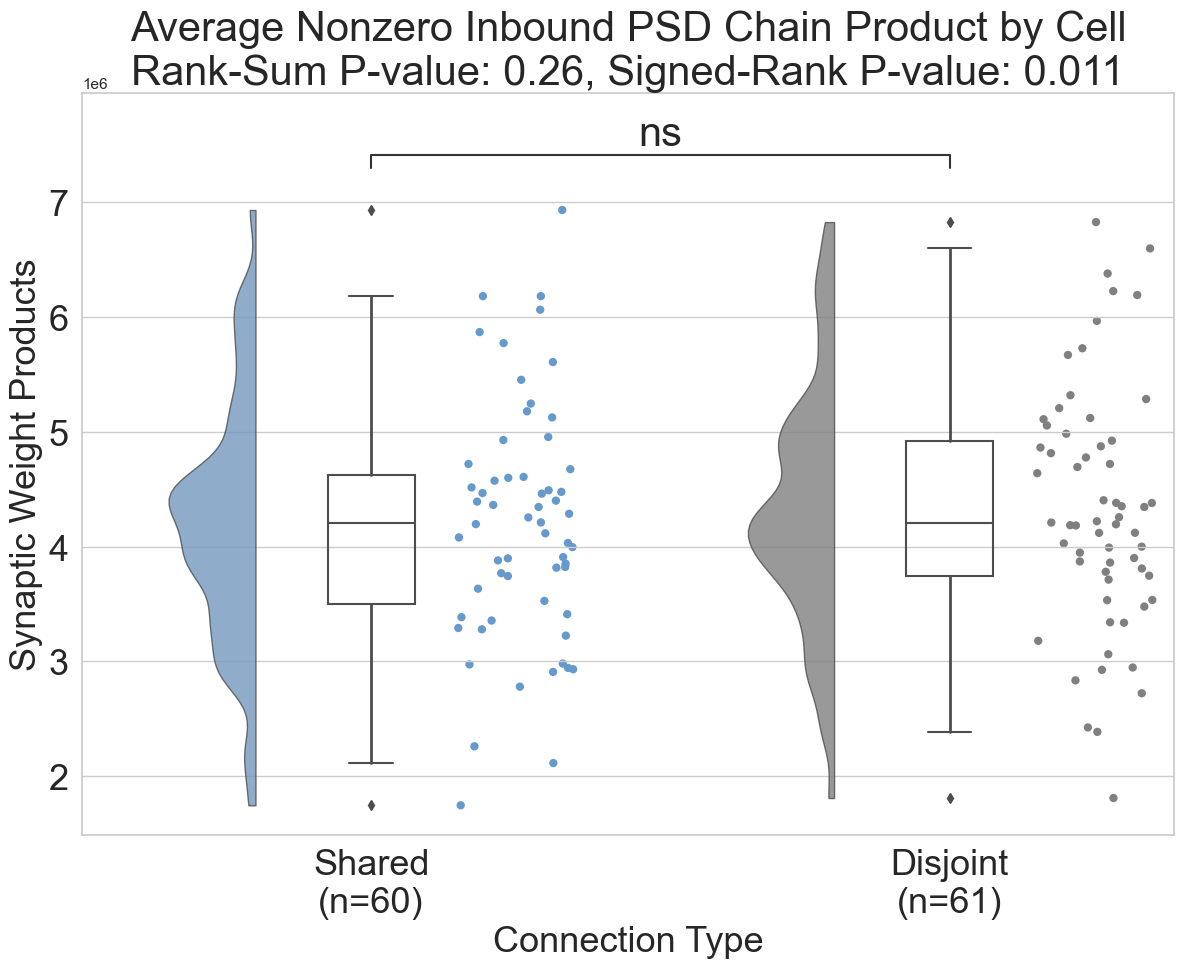

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:2.619e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


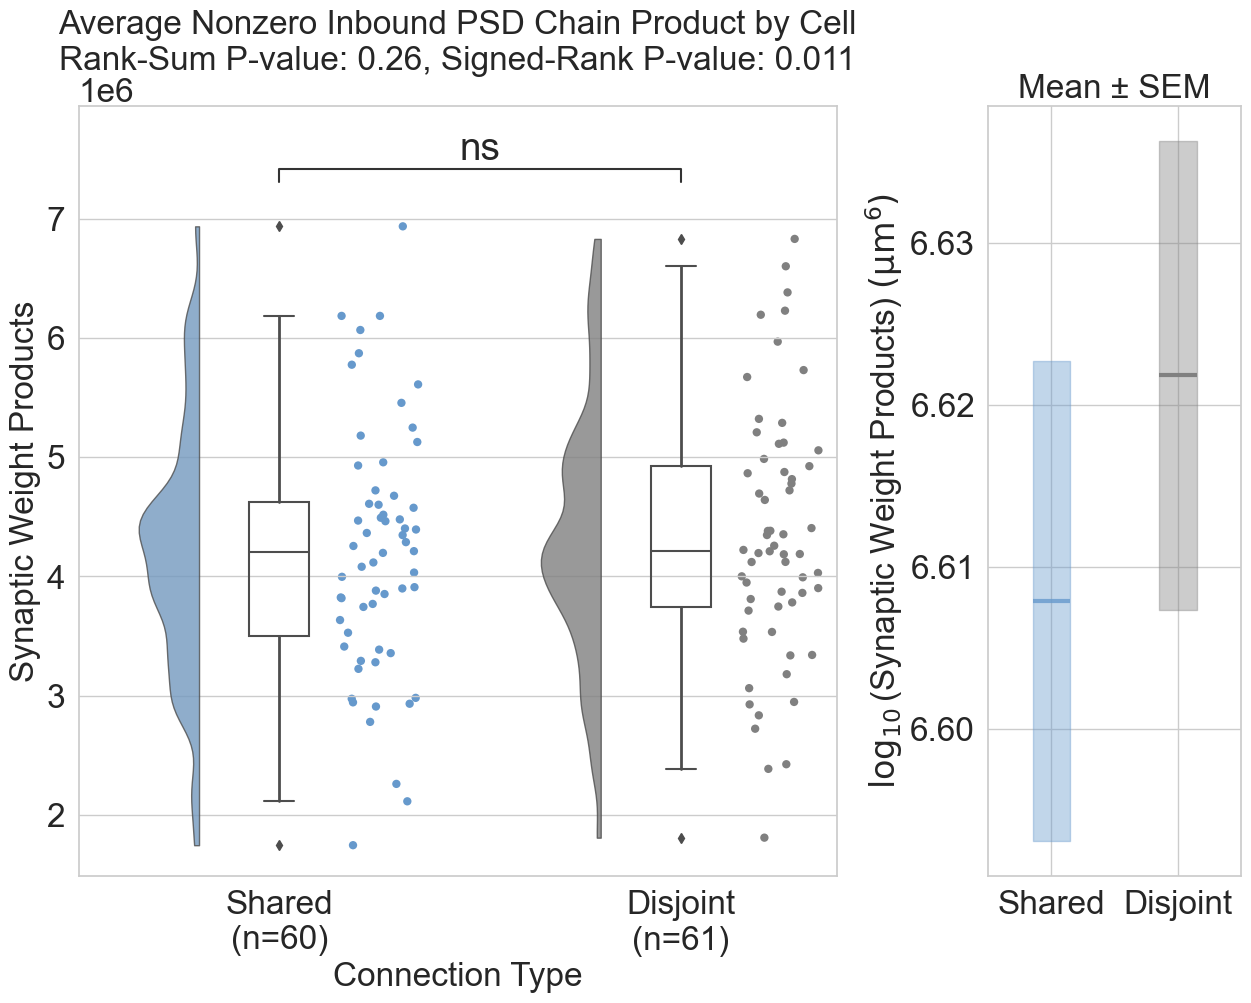

In [38]:
ranksum_signedrank_two_group_comparison(W_nonzero_chain_in_inhibitory,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.3382, P-value: 0.3676

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=239, n2=307
  Cohen's d        = -0.048
  HL shift         = 9.39335e-07
  Probability Sup. = 0.508
  Cliff's δ        = 0.017

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.216, 0.130]
  HL:    [-5.24246e-06, 7.54562e-06]
  PS:    [0.462, 0.561]
  δ:     [-0.076, 0.122]

P-value stability
  median p = 0.3524
  95% range = [0.007214, 0.9368]
  proportion significant (α=0.05) = 0.123
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=239) vs. Disjoint
(n=307): Custom statistical test, P_val:3.676e-01


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


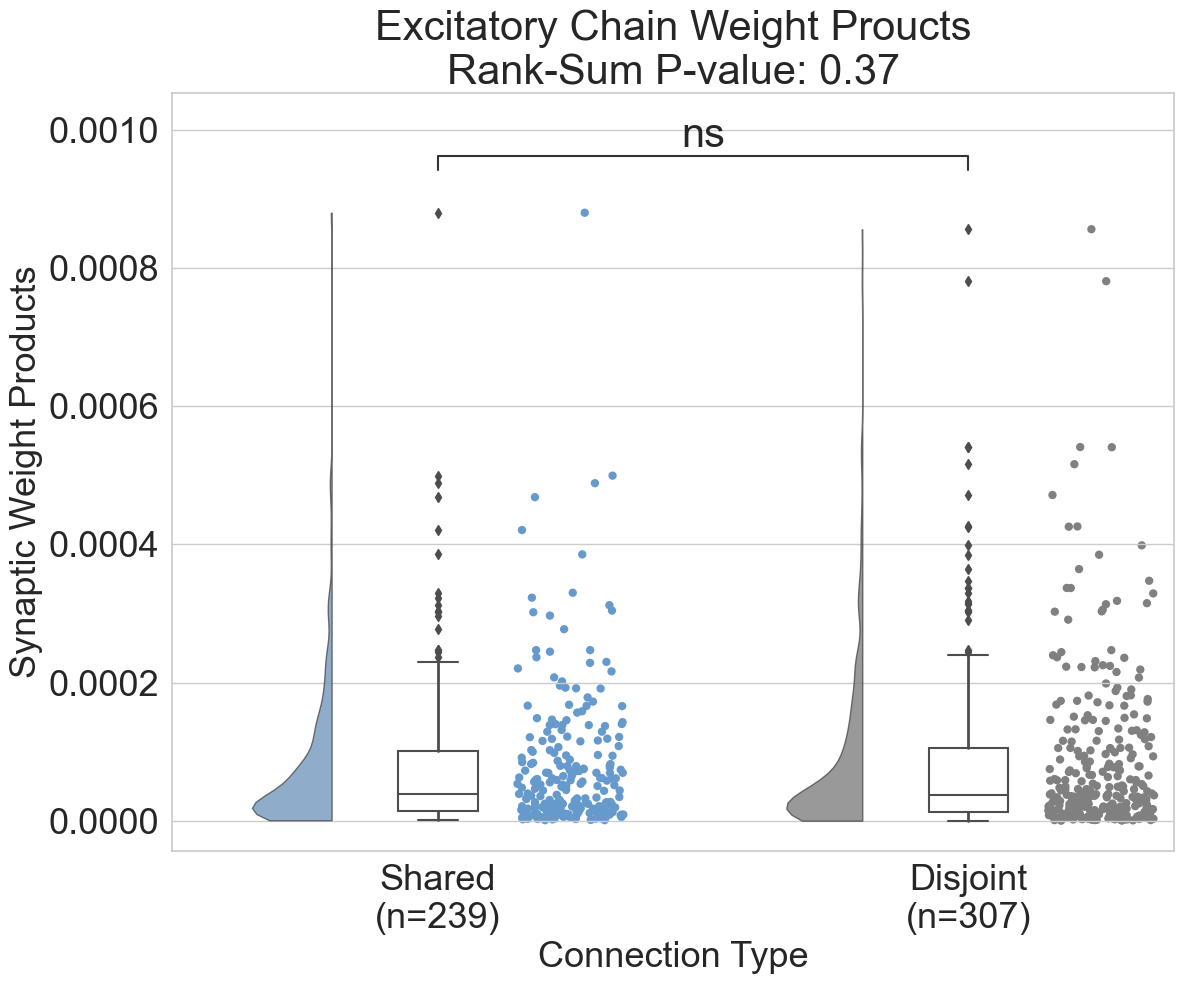

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=239) vs. Disjoint
(n=307): Custom statistical test, P_val:3.676e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


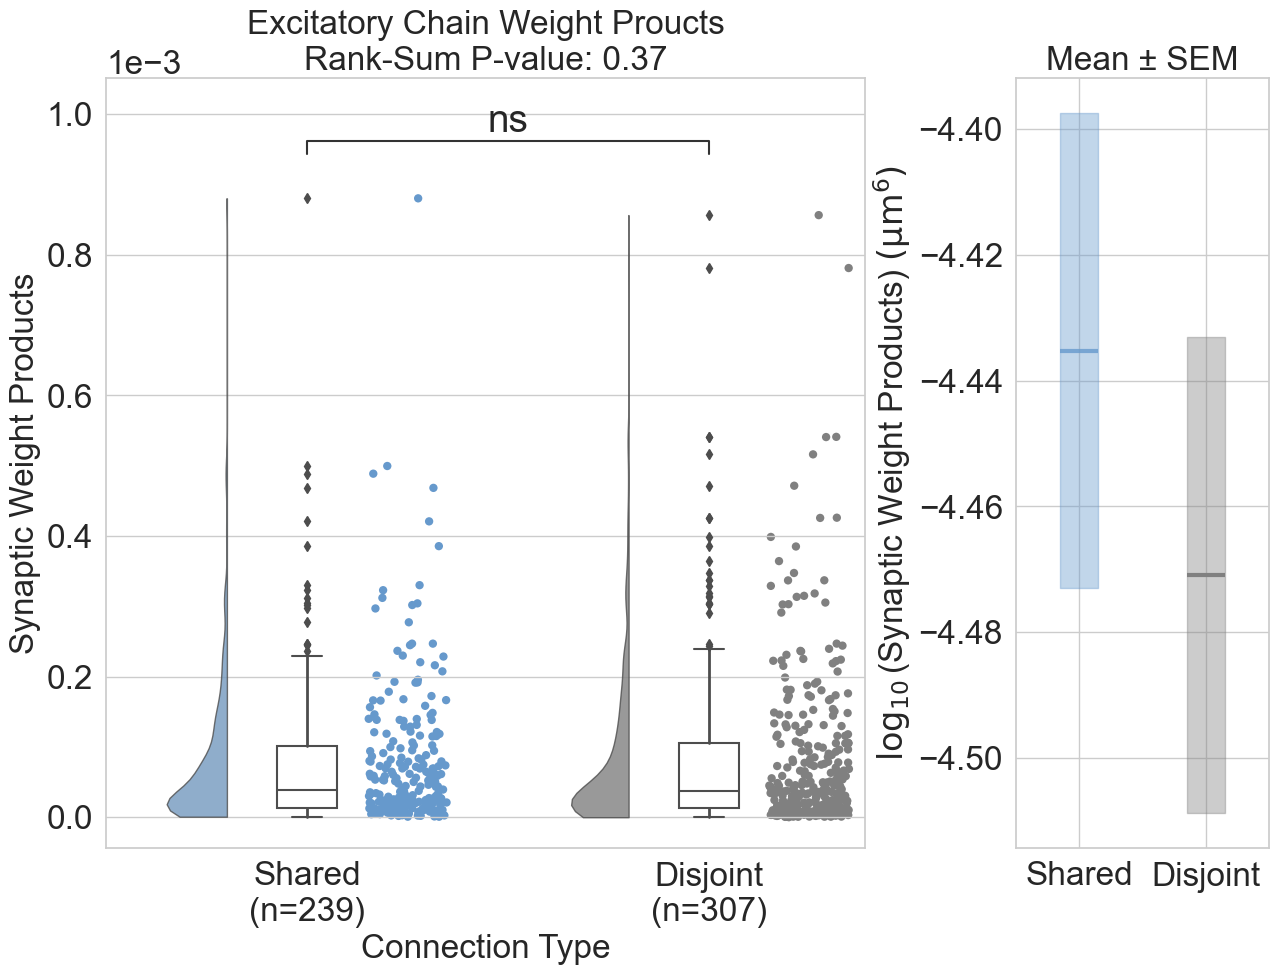

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -2.302, P-value: 0.01066

[UNPAIRED] Effect Size Estimates (positive = in direction of 'less')
  n1=1608, n2=2049
  Cohen's d        = 0.071
  HL shift         = 3.88568e-05
  Probability Sup. = 0.522
  Cliff's δ        = 0.044

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [0.010, 0.136]
  HL:    [7.47329e-06, 7.16734e-05]
  PS:    [0.504, 0.542]
  δ:     [0.008, 0.083]

P-value stability
  median p = 0.01067
  95% range = [7.536e-06, 0.331]
  proportion significant (α=0.05) = 0.765
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=1608) vs. Disjoint
(n=2049): Custom statistical test, P_val:1.066e-02


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


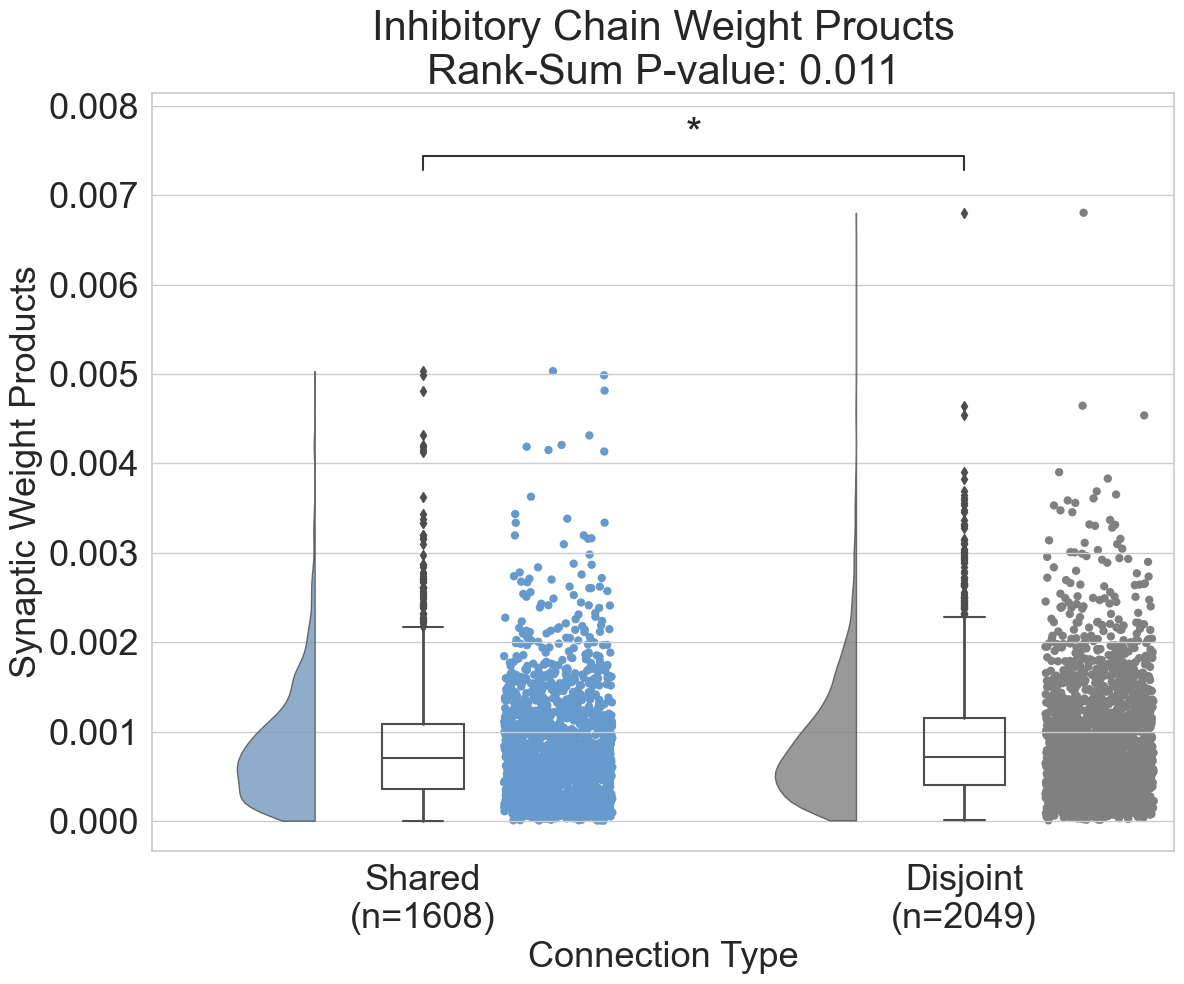

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=1608) vs. Disjoint
(n=2049): Custom statistical test, P_val:1.066e-02


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


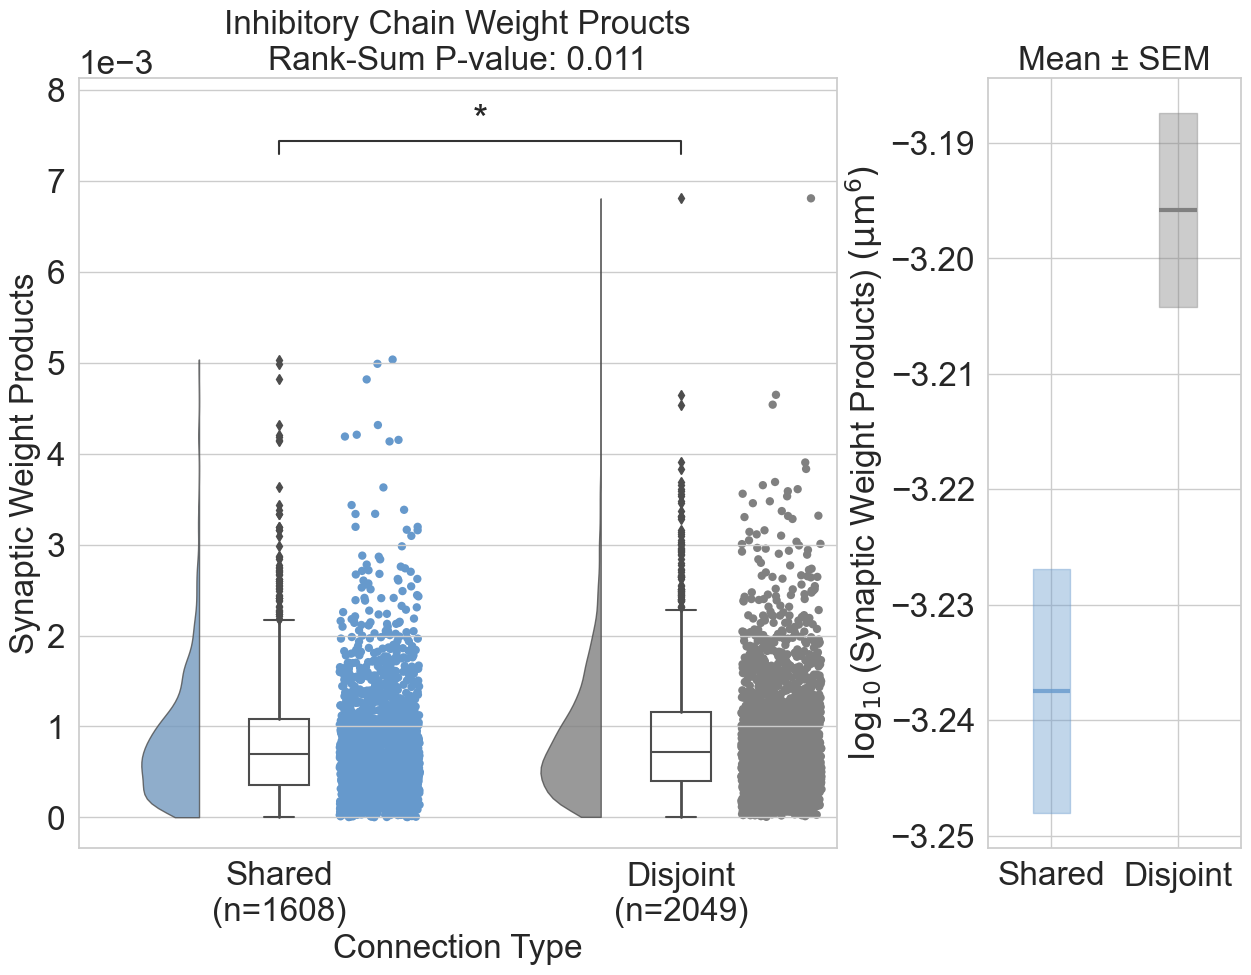

In [39]:
ranksum_signedrank_two_group_comparison(W_chain_nonzero_pairwise_excitatory,
                                        aggregation_method='connection',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Nonzero_PSD_by_Conn_E_Chain'
                                        )


ranksum_signedrank_two_group_comparison(W_chain_nonzero_pairwise_inhibitory,
                                        aggregation_method='connection',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Nonzero_PSD_by_Conn_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.3655, P-value: 0.6426

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=60, n2=61
  Cohen's d        = -0.012
  HL shift         = -1.05075e-05
  Probability Sup. = 0.481
  Cliff's δ        = -0.039

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.379, 0.379]
  HL:    [-0.00010803, 0.000103875]
  PS:    [0.375, 0.590]
  δ:     [-0.250, 0.180]

P-value stability
  median p = 0.6487
  95% range = [0.04389, 0.9913]
  proportion significant (α=0.05) = 0.028
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 829, P-value: 0.5813

[PAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n_pairs=60
  Cohen's d        = -0.016
  HL shift         = -3.23065e-05
  Probability Sup. = 0.417
  Cliff's δ        = -0.167

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.254, 0.273]
  HL:    [-7.84666e-05, 4.8823e-05]
  PS:    [0

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


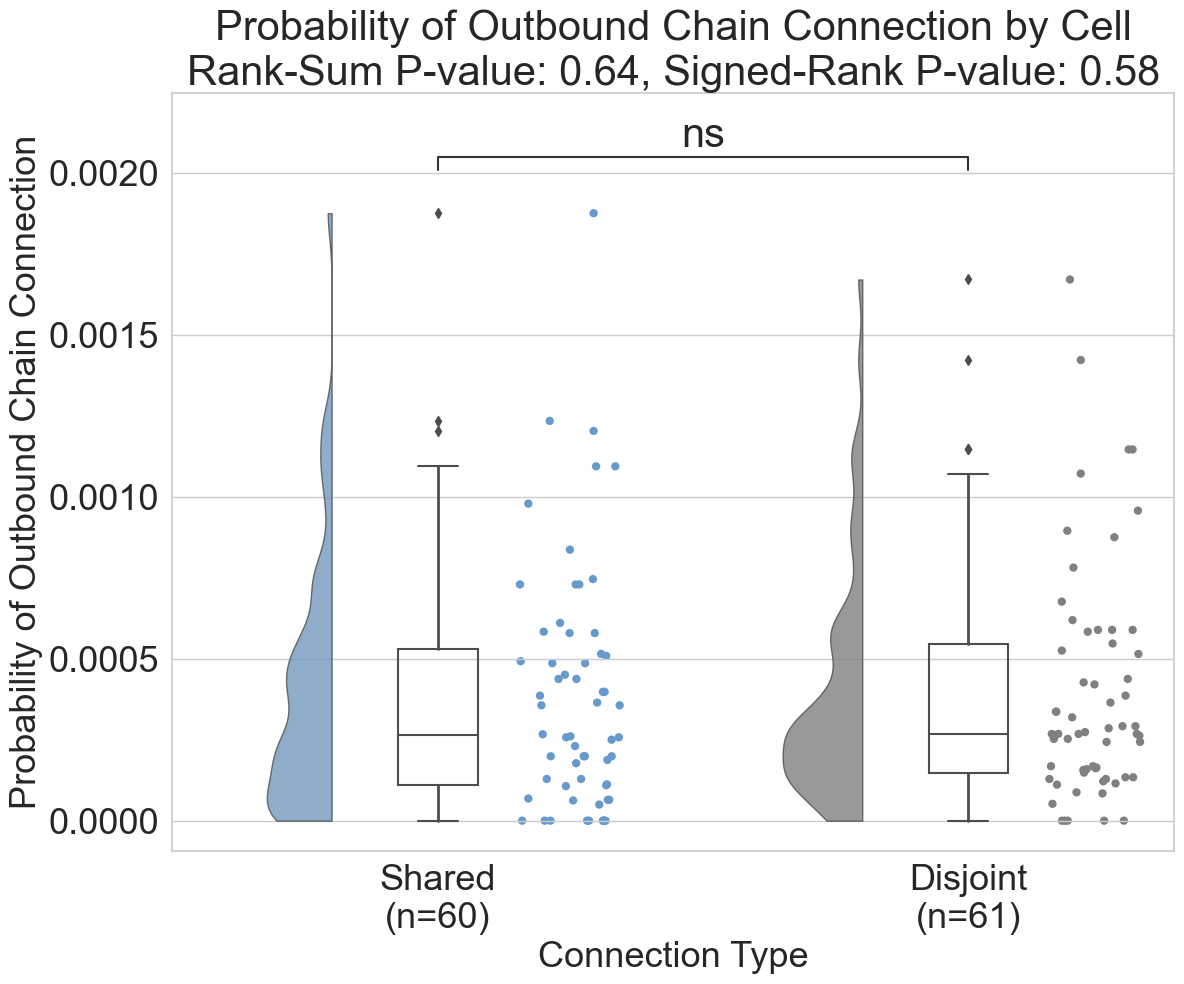

C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:108: RuntimeWarning: divide by zero encountered in log10
  shared_log = np.log10(shared_values)
C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:109: RuntimeWarning: divide by zero encountered in log10
  disjoint_log = np.log10(disjoint_values)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:6.426e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


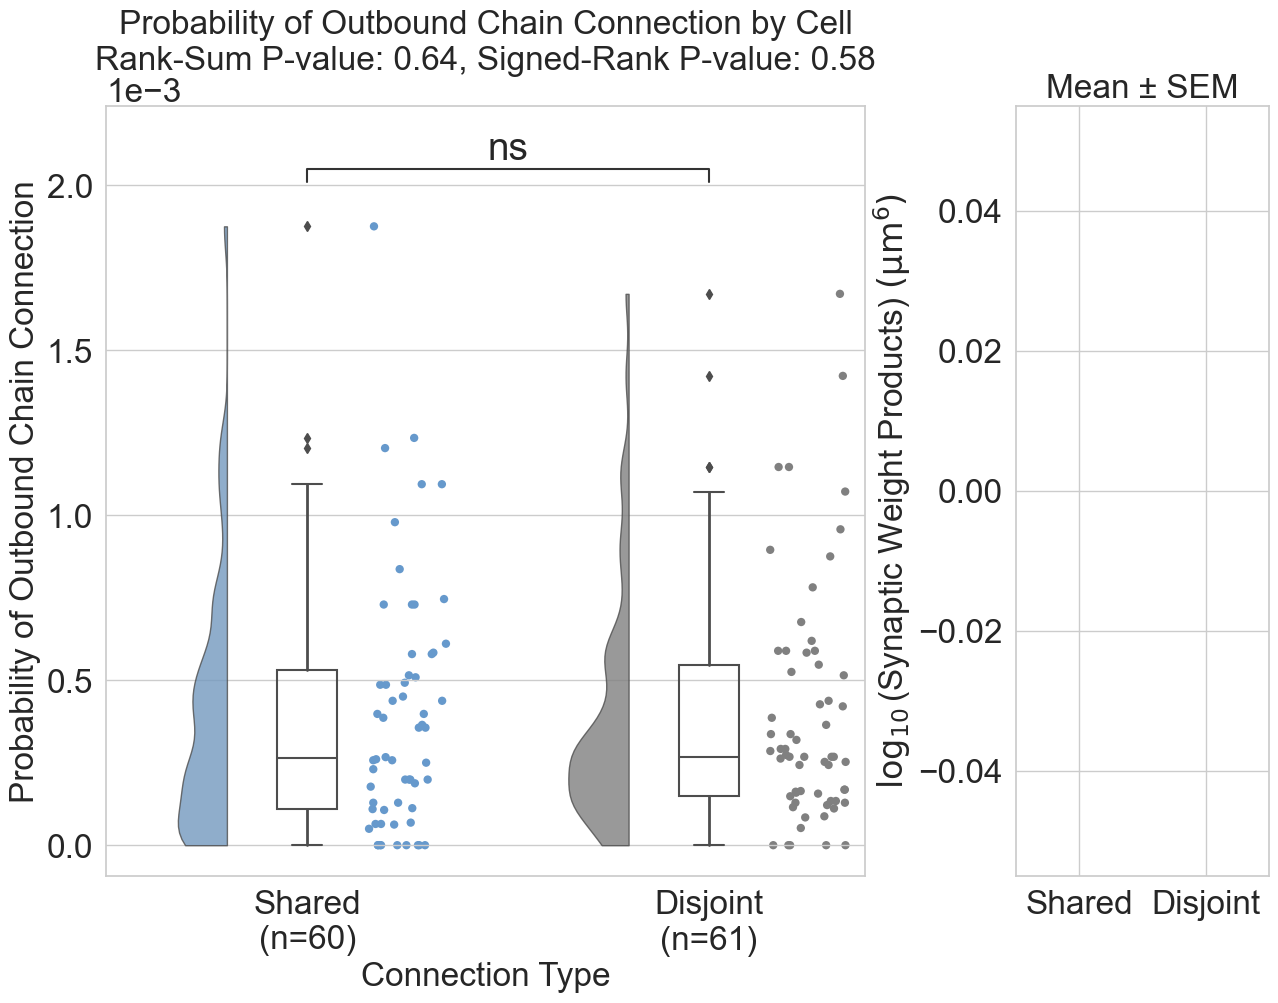

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: 0.4251, P-value: 0.6646

[UNPAIRED] Effect Size Estimates (positive = in direction of 'less')
  n1=60, n2=61
  Cohen's d        = -0.089
  HL shift         = -0.00113279
  Probability Sup. = 0.478
  Cliff's δ        = -0.045

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.415, 0.293]
  HL:    [-0.00446694, 0.00323033]
  PS:    [0.381, 0.586]
  δ:     [-0.239, 0.172]

P-value stability
  median p = 0.6703
  95% range = [0.05146, 0.9884]
  proportion significant (α=0.05) = 0.024
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 1336, P-value: 0.999

[PAIRED] Effect Size Estimates (positive = in direction of 'less')
  n_pairs=60
  Cohen's d        = -0.315
  HL shift         = -0.00113837
  Probability Sup. = 0.367
  Cliff's δ        = -0.267

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.711, -0.048]
  HL:    [-0.00233735, -0.000308326]
  PS:    [0.250, 0.

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


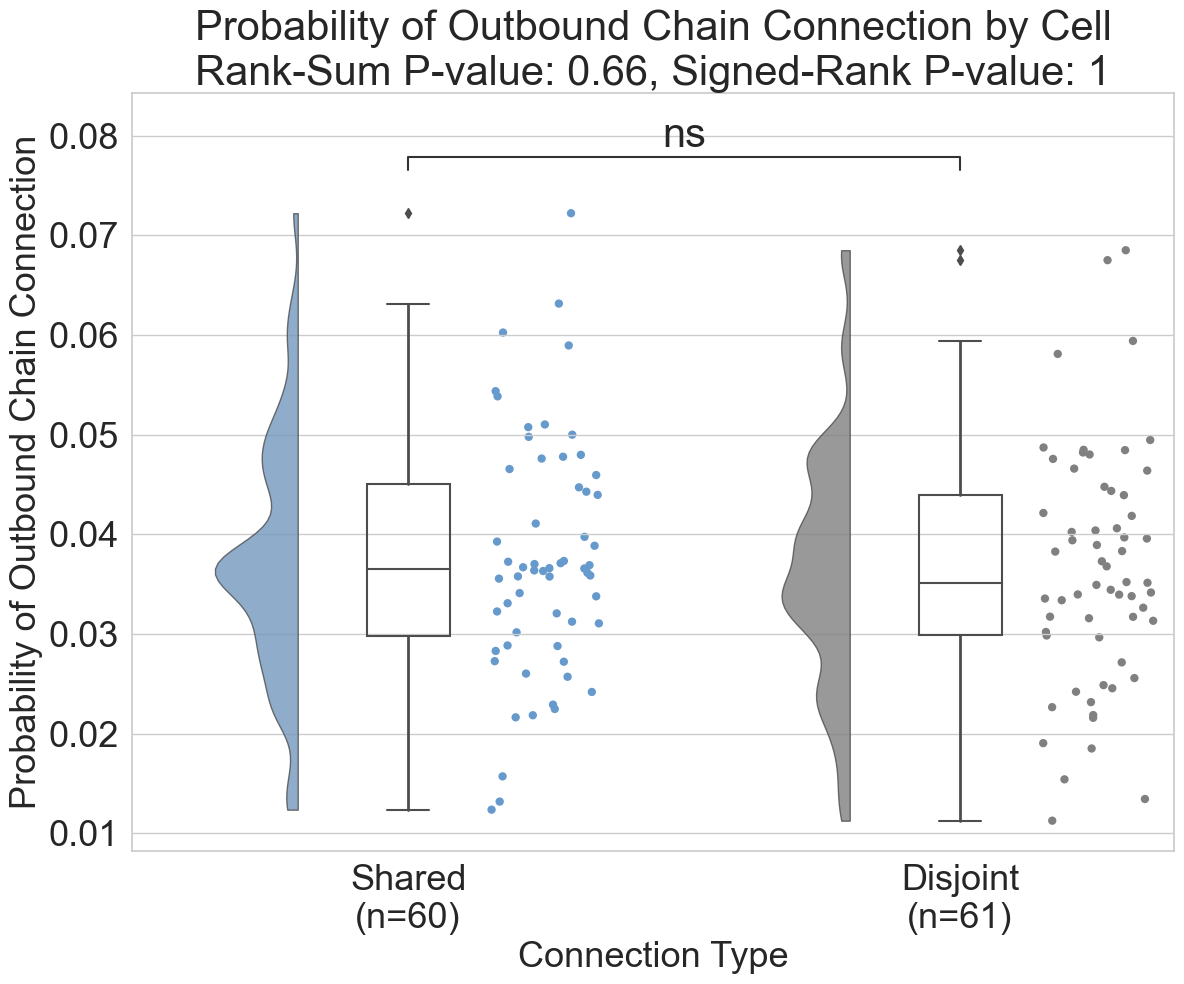

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:6.646e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


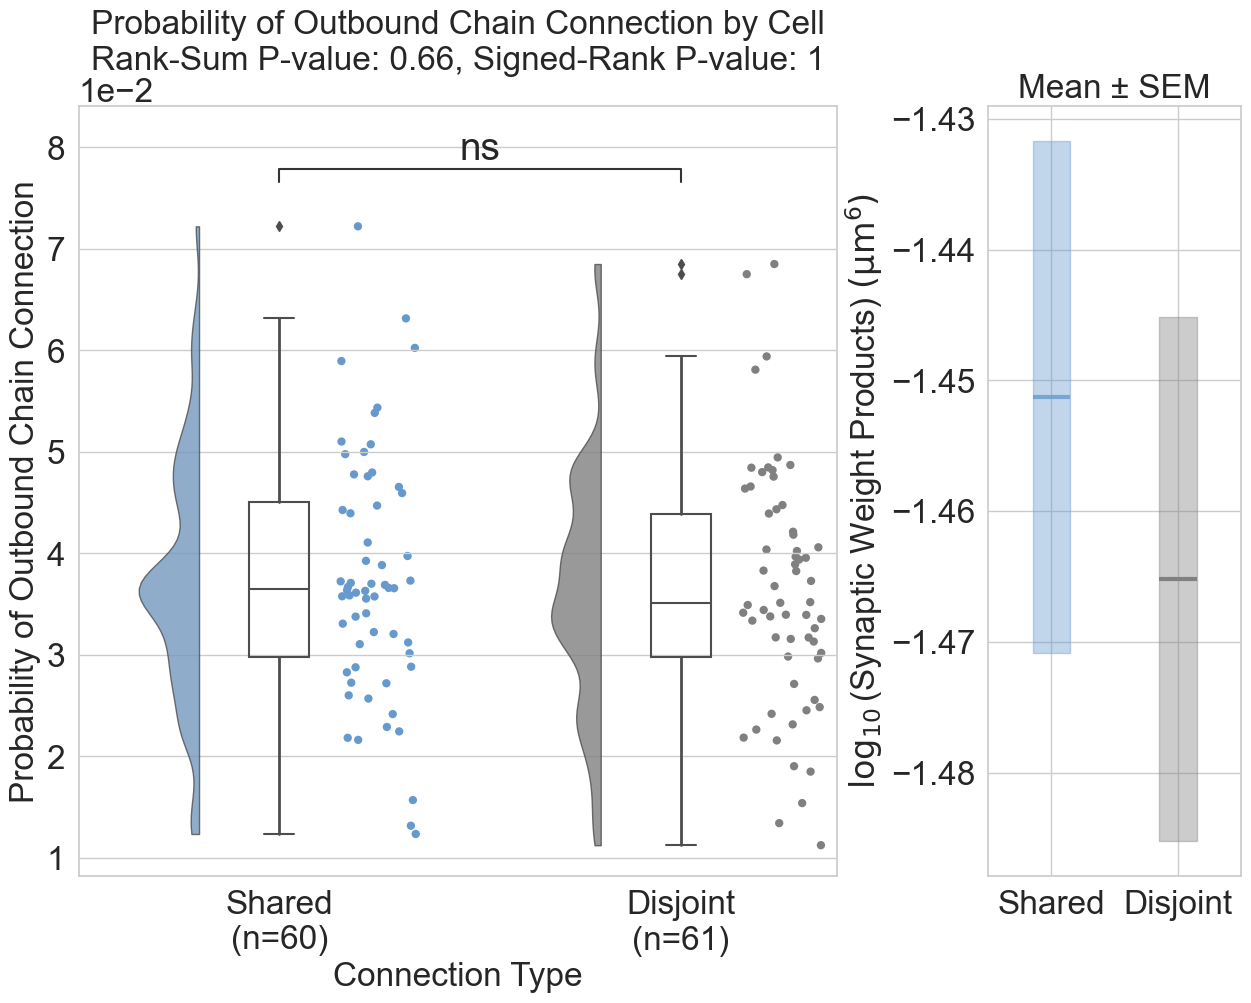

In [40]:
ranksum_signedrank_two_group_comparison(B_chain_out_excitatory,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Prob_Outbound_Conn_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(B_chain_out_inhibitory,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Prob_Outbound_Conn_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.0499, P-value: 0.4801

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=51, n2=56
  Cohen's d        = 0.097
  HL shift         = 25718.2
  Probability Sup. = 0.503
  Cliff's δ        = 0.006

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.306, 0.472]
  HL:    [-1.2748e+06, 1.09474e+06]
  PS:    [0.391, 0.616]
  δ:     [-0.219, 0.231]

P-value stability
  median p = 0.4714
  95% range = [0.01989, 0.9744]
  proportion significant (α=0.05) = 0.067
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 596, P-value: 0.4696

[PAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n_pairs=48
  Cohen's d        = 0.052
  HL shift         = -19544.5
  Probability Sup. = 0.500
  Cliff's δ        = 0.000

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.254, 0.310]
  HL:    [-1.53363e+06, 1.07247e+06]
  PS:    [0.354, 0.646]


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


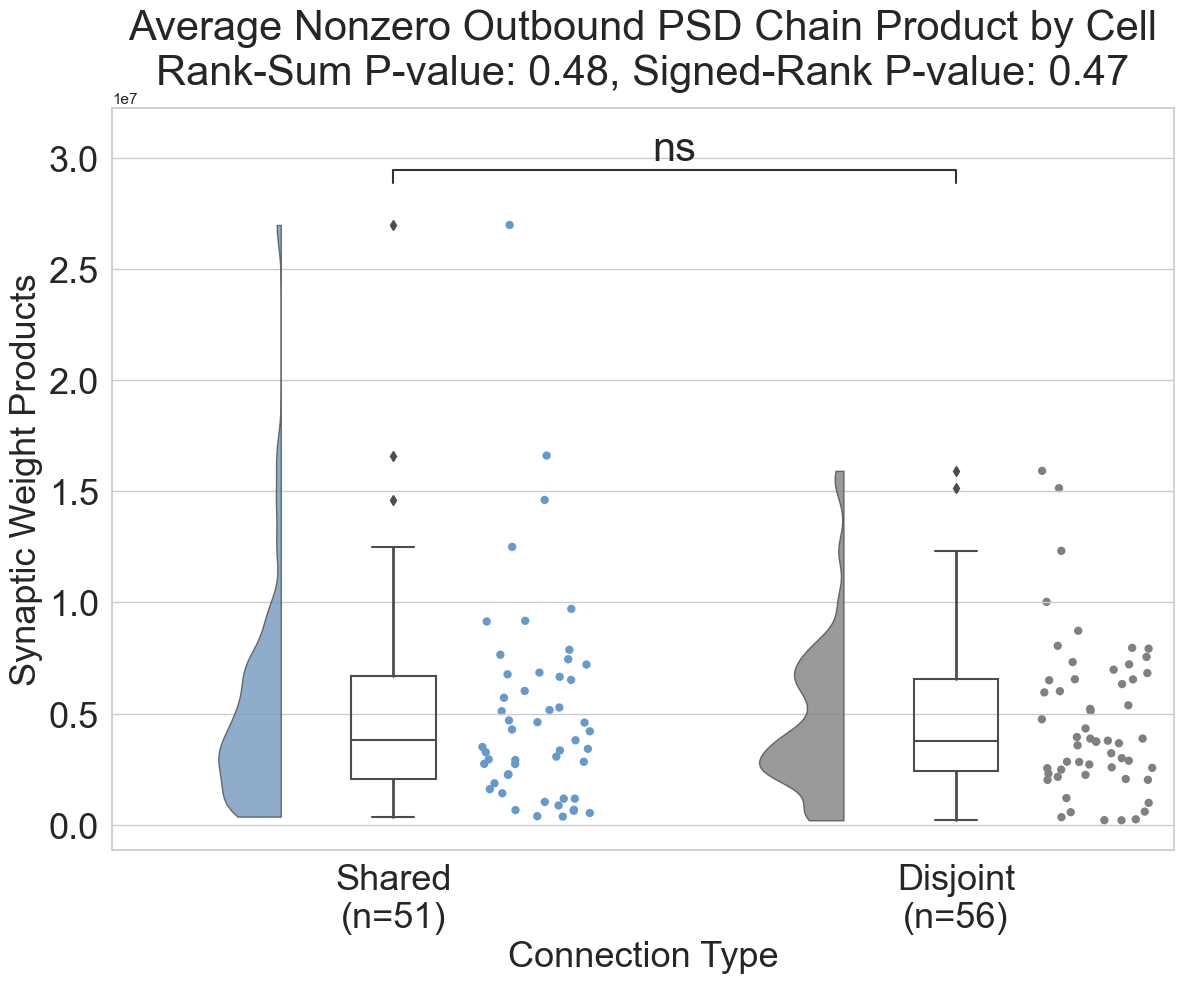

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=51) vs. Disjoint
(n=56): Custom statistical test, P_val:4.801e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


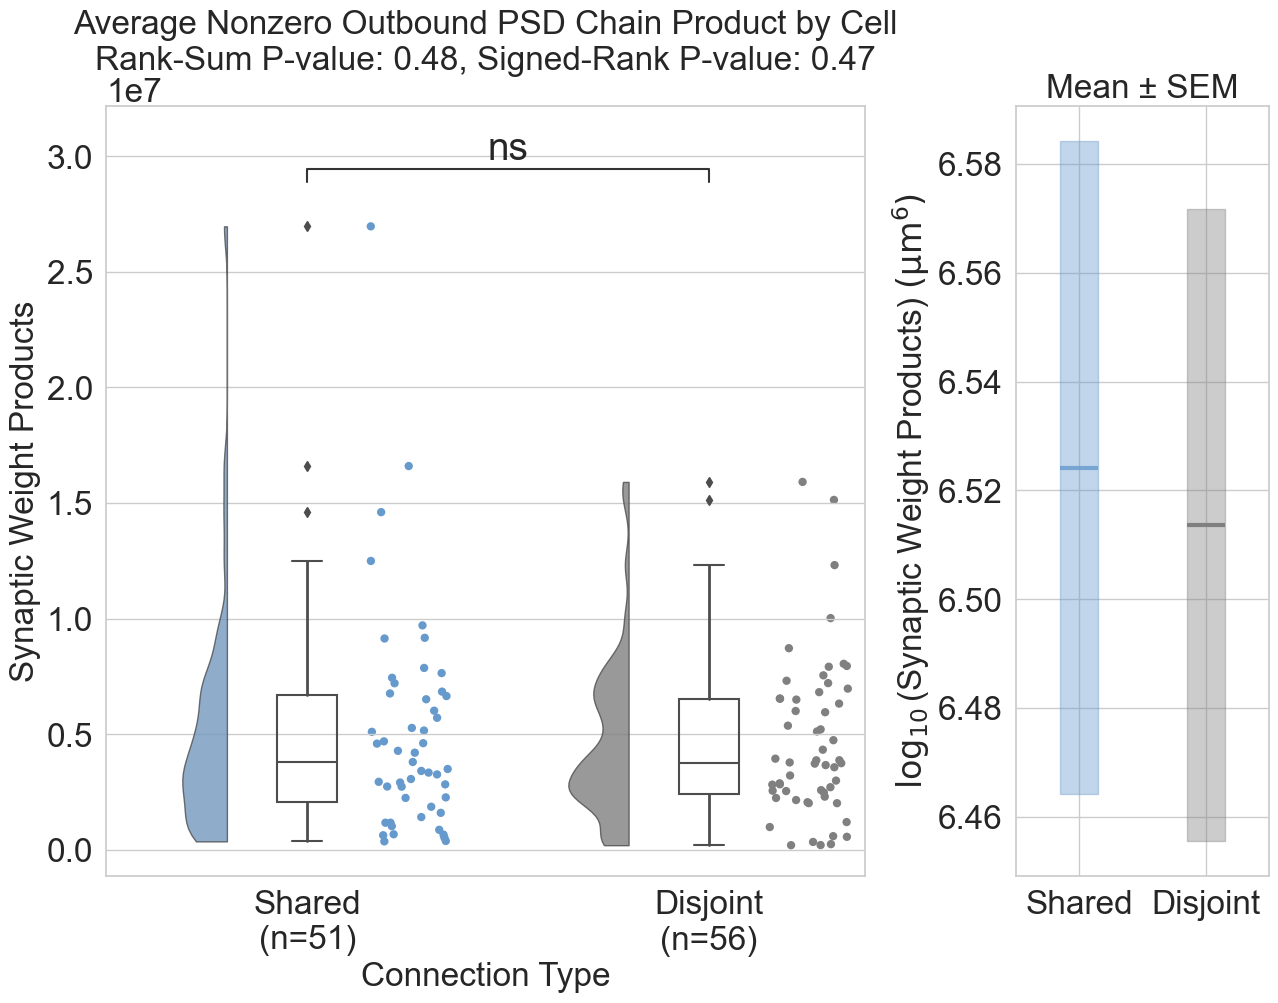

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -1.337, P-value: 0.09053

[UNPAIRED] Effect Size Estimates (positive = in direction of 'less')
  n1=60, n2=61
  Cohen's d        = 0.179
  HL shift         = 240451
  Probability Sup. = 0.570
  Cliff's δ        = 0.141

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.169, 0.550]
  HL:    [-92429.4, 627755]
  PS:    [0.467, 0.670]
  δ:     [-0.066, 0.340]

P-value stability
  median p = 0.08967
  95% range = [0.0006246, 0.7357]
  proportion significant (α=0.05) = 0.384
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 493, P-value: 0.0009463

[PAIRED] Effect Size Estimates (positive = in direction of 'less')
  n_pairs=60
  Cohen's d        = 0.317
  HL shift         = 193997
  Probability Sup. = 0.683
  Cliff's δ        = 0.367

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [0.064, 0.691]
  HL:    [75652.1, 442996]
  PS:    [0.567, 0.800]
  δ:     [0.133, 0.60

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


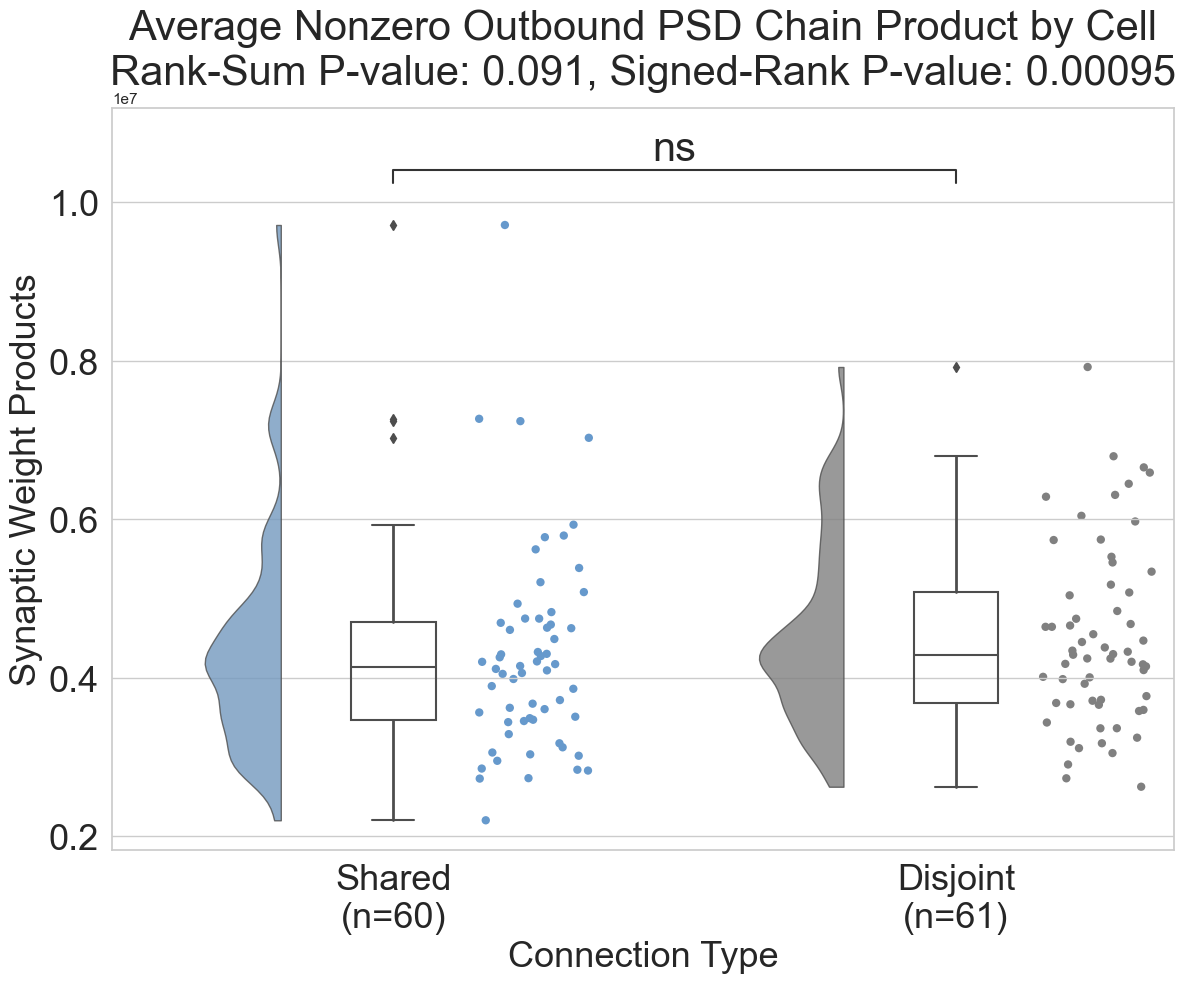

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:9.053e-02


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


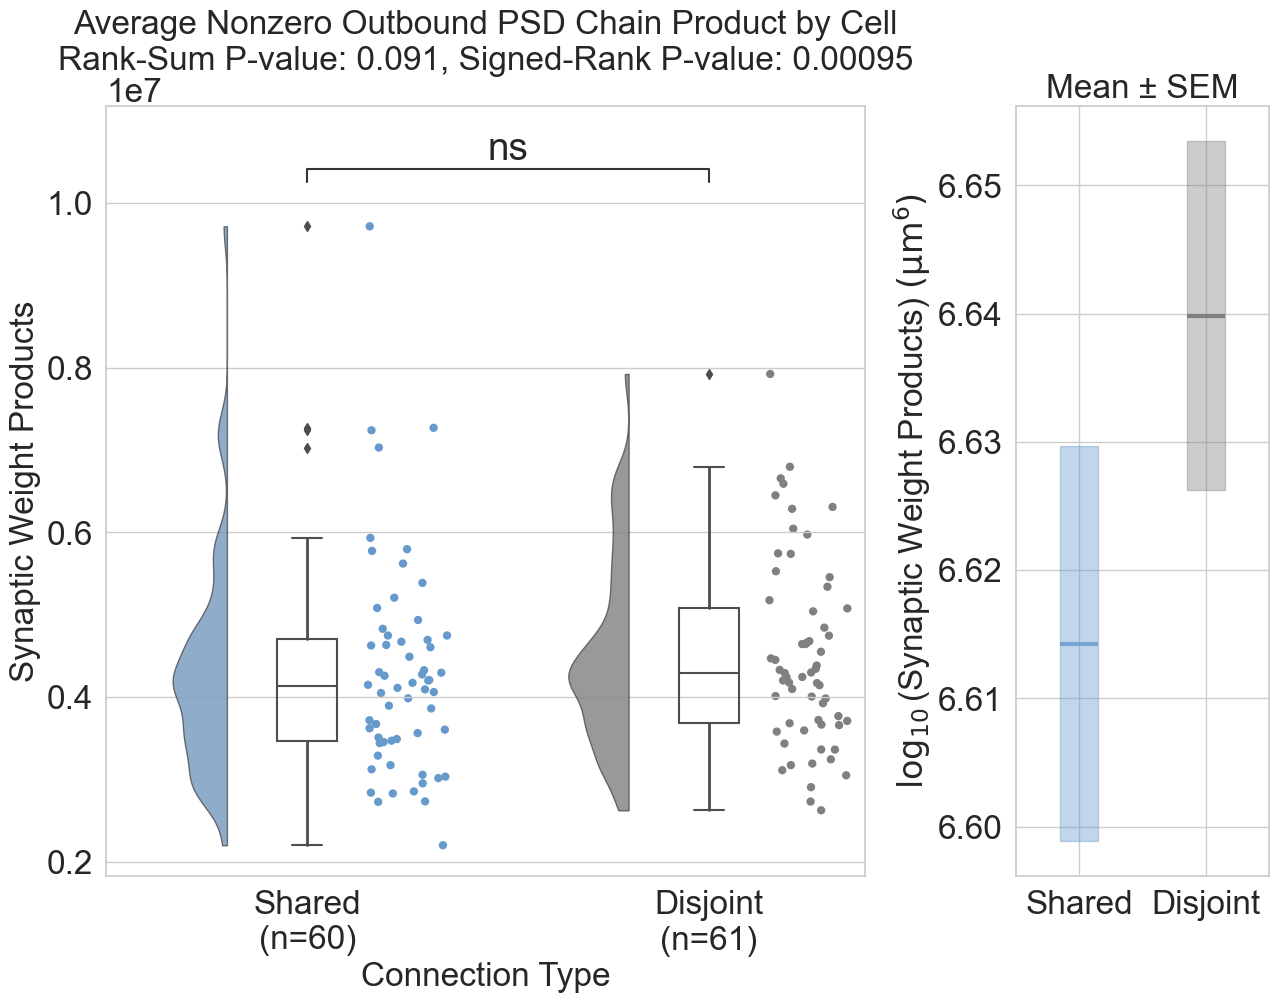

In [41]:
ranksum_signedrank_two_group_comparison(W_nonzero_chain_out_excitatory,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Outbound_PSD_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(W_nonzero_chain_out_inhibitory,
                                        aggregation_method='cell',
                                        directionality='outbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Outbound_PSD_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: -0.3396, P-value: 0.6329

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=60, n2=61
  Cohen's d        = -0.102
  HL shift         = -1.61492e-05
  Probability Sup. = 0.482
  Cliff's δ        = -0.036

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.431, 0.263]
  HL:    [-0.000120811, 0.000100997]
  PS:    [0.383, 0.583]
  δ:     [-0.233, 0.167]

P-value stability
  median p = 0.6075
  95% range = [0.05689, 0.9871]
  proportion significant (α=0.05) = 0.020
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 607, P-value: 0.8783

[PAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n_pairs=60
  Cohen's d        = -0.137
  HL shift         = -4.2221e-05
  Probability Sup. = 0.417
  Cliff's δ        = -0.167

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.386, 0.101]
  HL:    [-8.41609e-05, 0]
  PS:    [0.300, 0.5

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


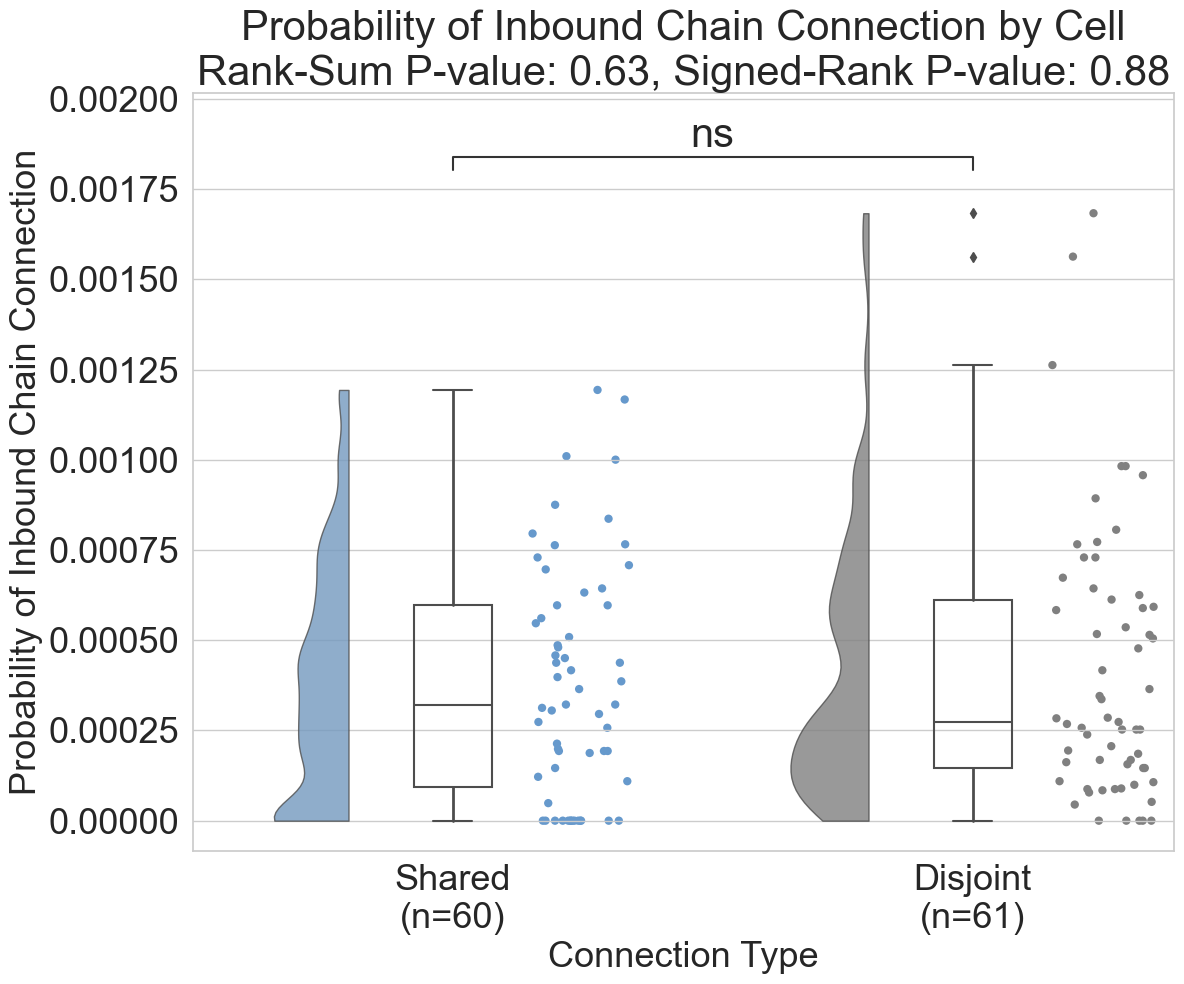

C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:108: RuntimeWarning: divide by zero encountered in log10
  shared_log = np.log10(shared_values)
C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:109: RuntimeWarning: divide by zero encountered in log10
  disjoint_log = np.log10(disjoint_values)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:6.329e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


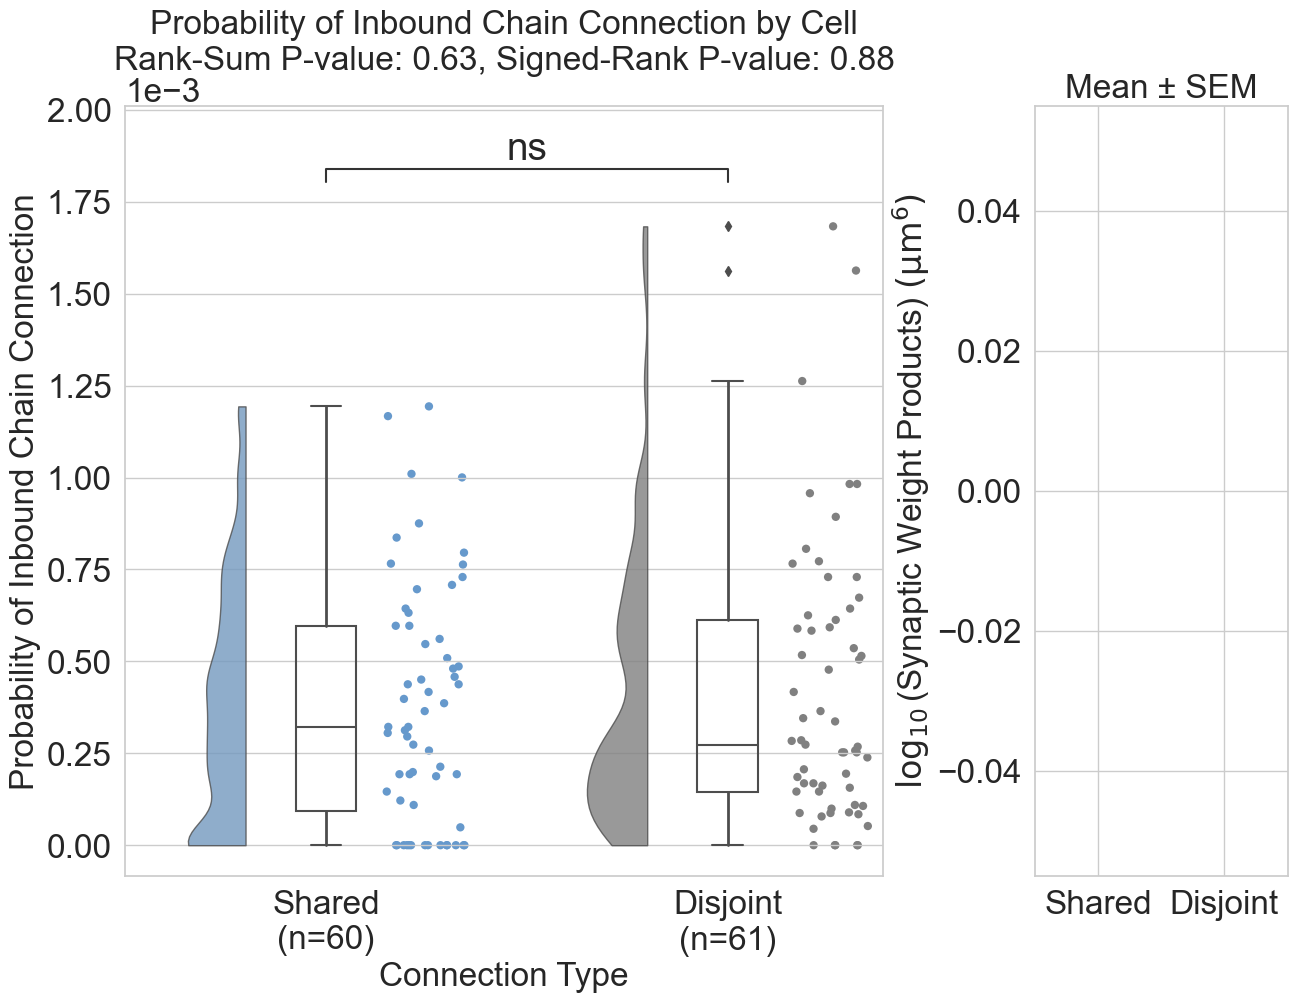

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -0.4977, P-value: 0.3094

[UNPAIRED] Effect Size Estimates (positive = in direction of 'less')
  n1=60, n2=61
  Cohen's d        = 0.077
  HL shift         = 0.000753208
  Probability Sup. = 0.526
  Cliff's δ        = 0.052

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.287, 0.445]
  HL:    [-0.00280379, 0.00425306]
  PS:    [0.423, 0.628]
  δ:     [-0.154, 0.256]

P-value stability
  median p = 0.3208
  95% range = [0.007676, 0.9285]
  proportion significant (α=0.05) = 0.124
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 619, P-value: 0.01466

[PAIRED] Effect Size Estimates (positive = in direction of 'less')
  n_pairs=60
  Cohen's d        = 0.262
  HL shift         = 0.00171842
  Probability Sup. = 0.717
  Cliff's δ        = 0.433

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [0.004, 0.520]
  HL:    [0.000904722, 0.00224473]
  PS:    [0.583, 0.817]
 

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


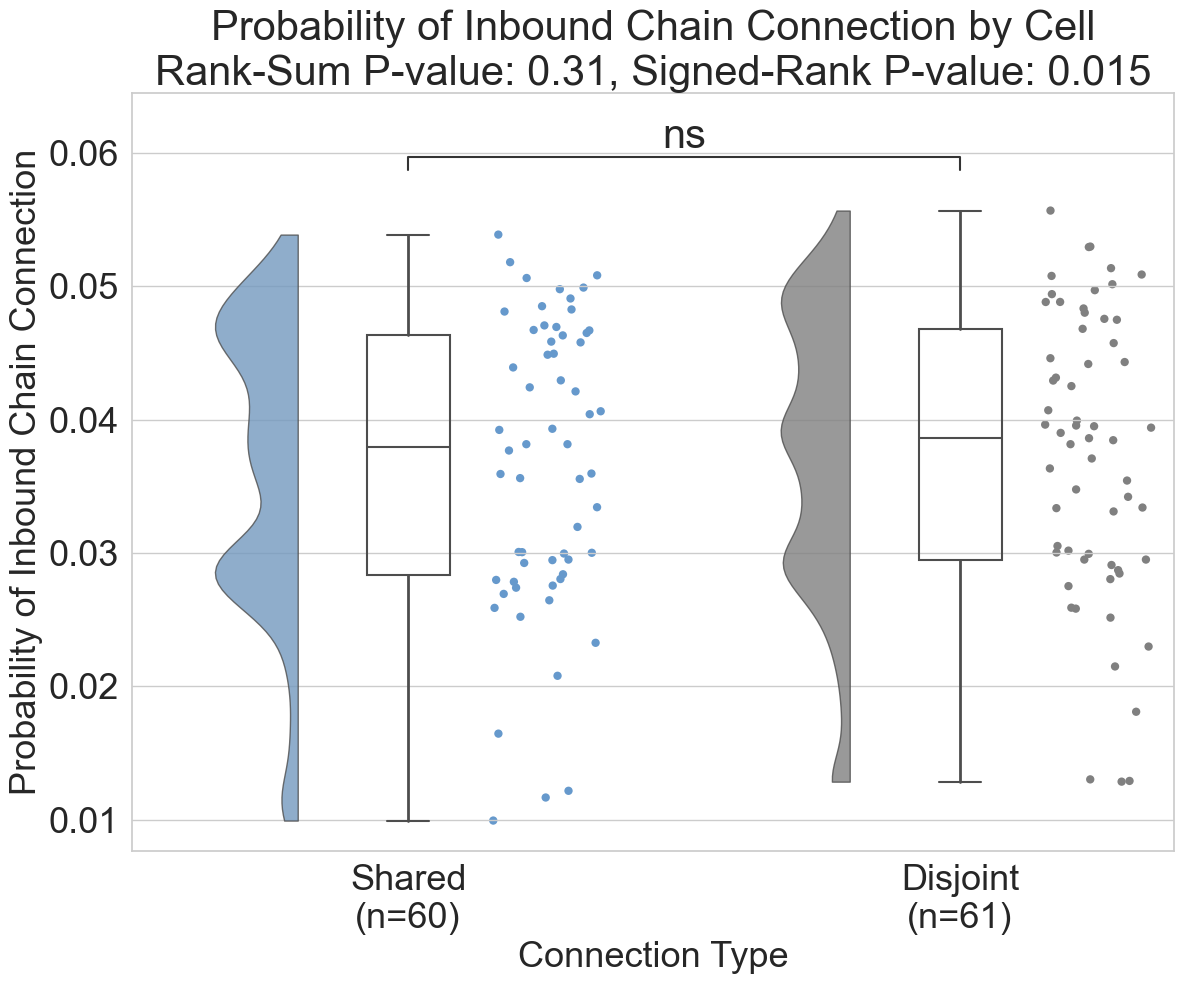

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:3.094e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


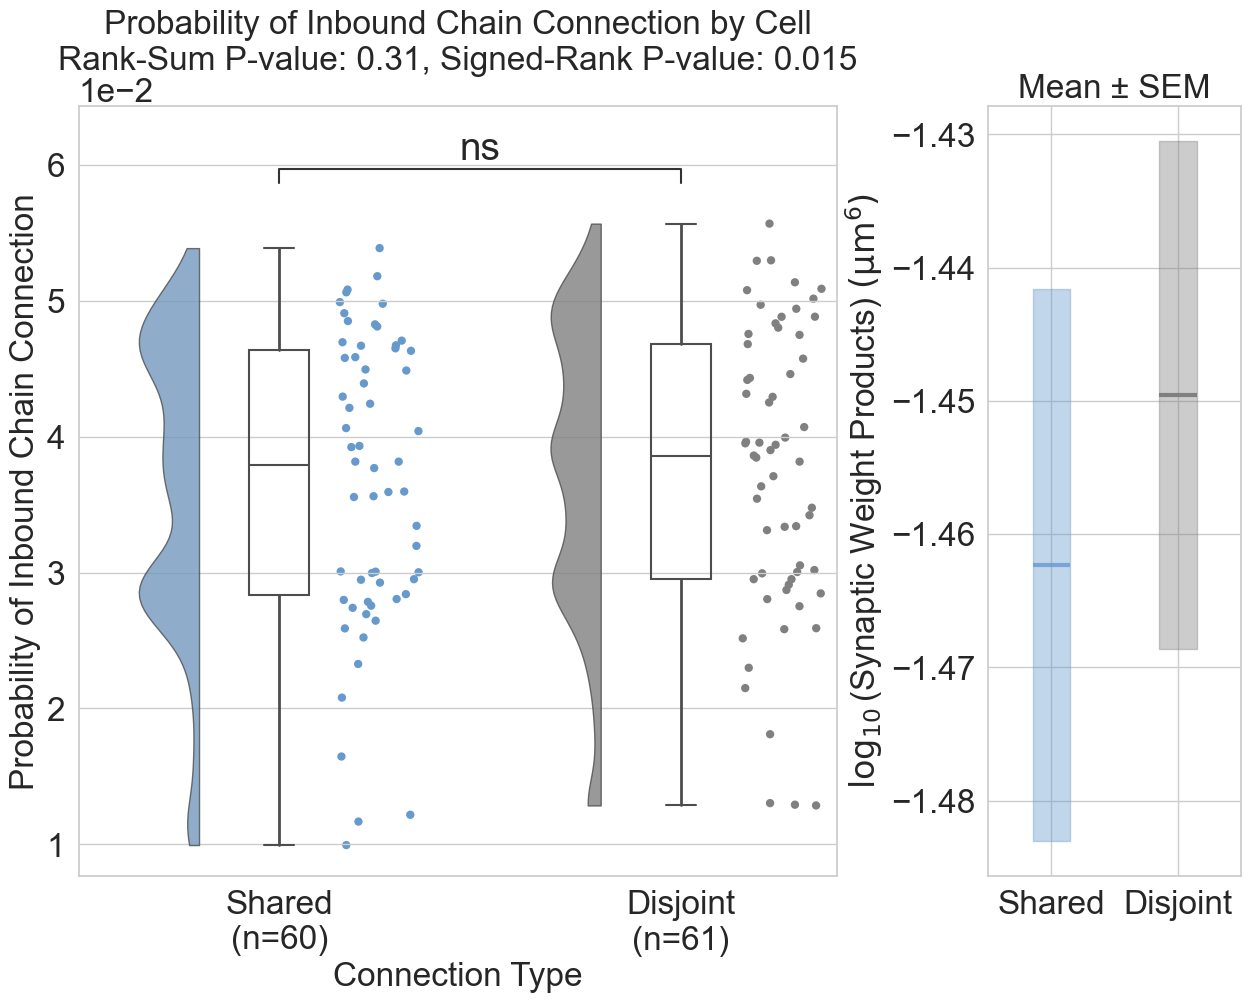

In [42]:
ranksum_signedrank_two_group_comparison(B_chain_in_excitatory,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Prob_Inbound_Conn_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(B_chain_in_inhibitory,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='binary',
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Prob_Inbound_Conn_I_Chain'
                                        )

Wilcoxon Rank-Sum Test (unpaired, shared > disjoint):
Statistic: 0.7263, P-value: 0.2338

[UNPAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n1=46, n2=56
  Cohen's d        = 0.186
  HL shift         = 412712
  Probability Sup. = 0.542
  Cliff's δ        = 0.084

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.191, 0.574]
  HL:    [-749474, 1.62403e+06]
  PS:    [0.432, 0.659]
  δ:     [-0.137, 0.318]

P-value stability
  median p = 0.2166
  95% range = [0.003001, 0.8825]
  proportion significant (α=0.05) = 0.189
Wilcoxon Signed-Rank Test (paired, shared > disjoint):
Statistic: 502, P-value: 0.571

[PAIRED] Effect Size Estimates (positive = in direction of 'greater')
  n_pairs=45
  Cohen's d        = 0.044
  HL shift         = -133996
  Probability Sup. = 0.489
  Cliff's δ        = -0.022

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.258, 0.326]
  HL:    [-2.14199e+06, 1.23001e+06]
  PS:    [0.333, 0.644]
  δ: 

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


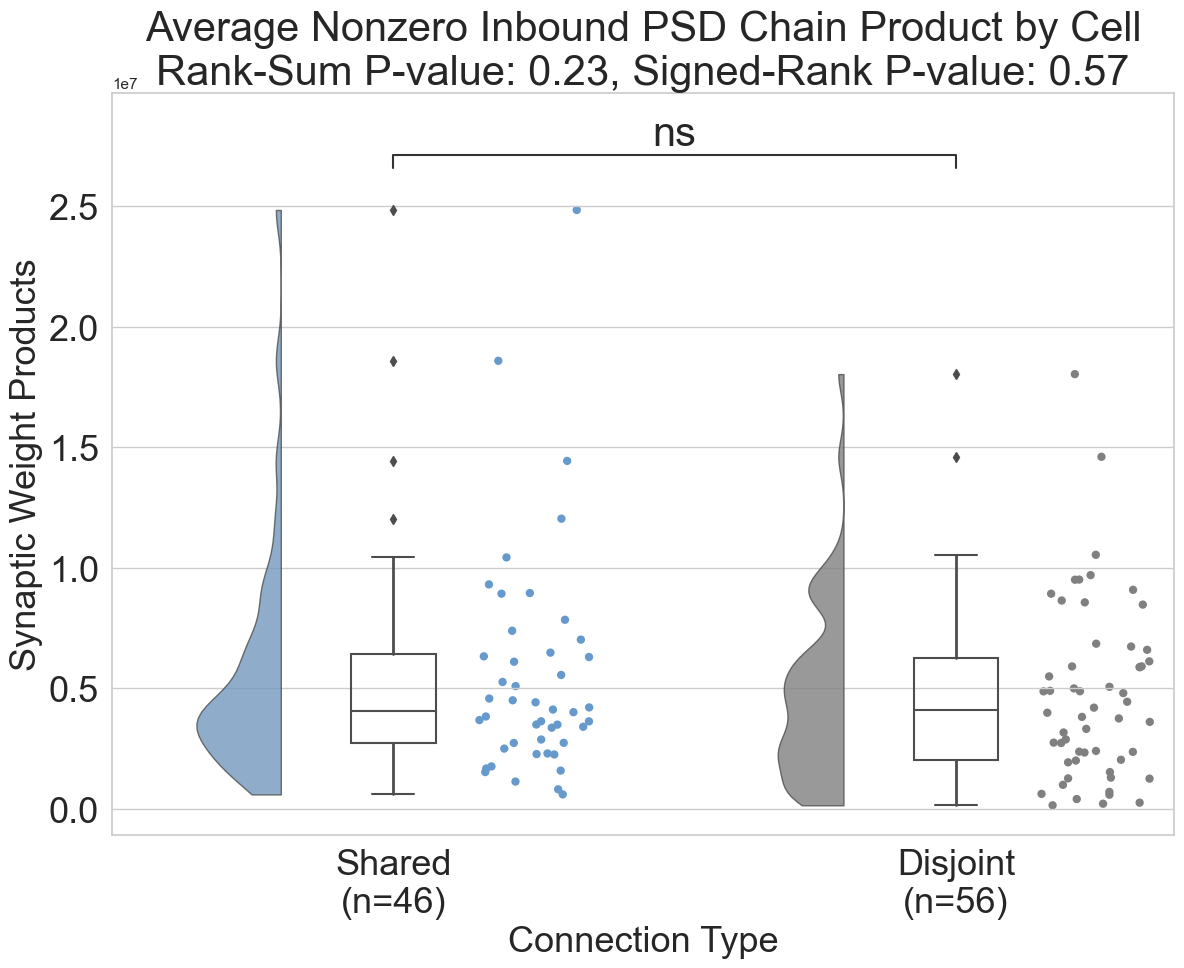

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=46) vs. Disjoint
(n=56): Custom statistical test, P_val:2.338e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


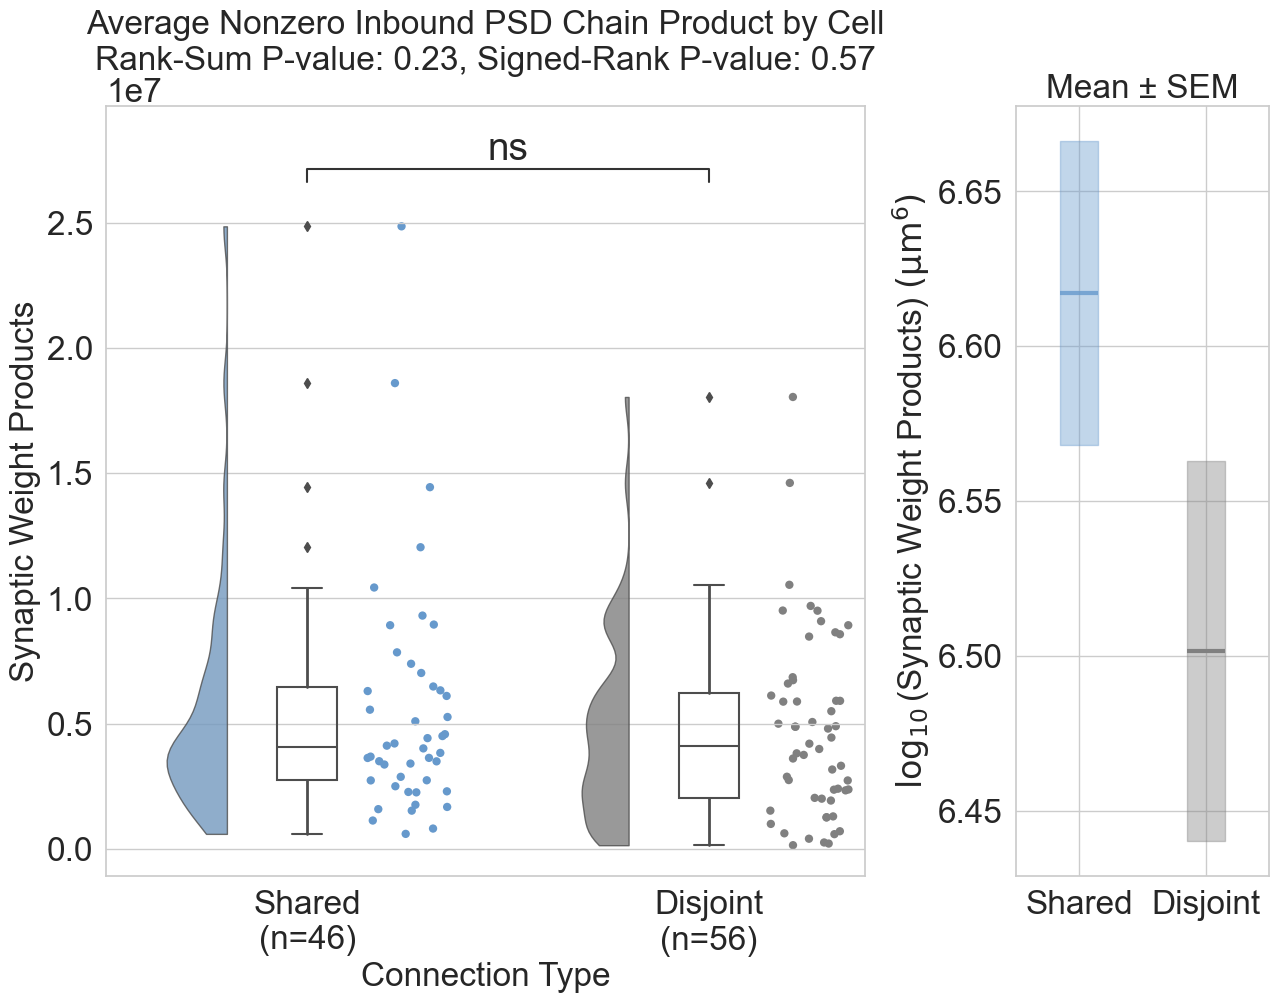

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -0.6376, P-value: 0.2619

[UNPAIRED] Effect Size Estimates (positive = in direction of 'less')
  n1=60, n2=61
  Cohen's d        = 0.127
  HL shift         = 124573
  Probability Sup. = 0.534
  Cliff's δ        = 0.067

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.229, 0.480]
  HL:    [-245348, 485467]
  PS:    [0.432, 0.634]
  δ:     [-0.136, 0.267]

P-value stability
  median p = 0.2601
  95% range = [0.005659, 0.9021]
  proportion significant (α=0.05) = 0.134
Wilcoxon Signed-Rank Test (paired, shared < disjoint):
Statistic: 606, P-value: 0.01146

[PAIRED] Effect Size Estimates (positive = in direction of 'less')
  n_pairs=60
  Cohen's d        = 0.315
  HL shift         = 134369
  Probability Sup. = 0.600
  Cliff's δ        = 0.200

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [0.068, 0.605]
  HL:    [-23351.2, 297052]
  PS:    [0.483, 0.733]
  δ:     [-0.033, 0.467]


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


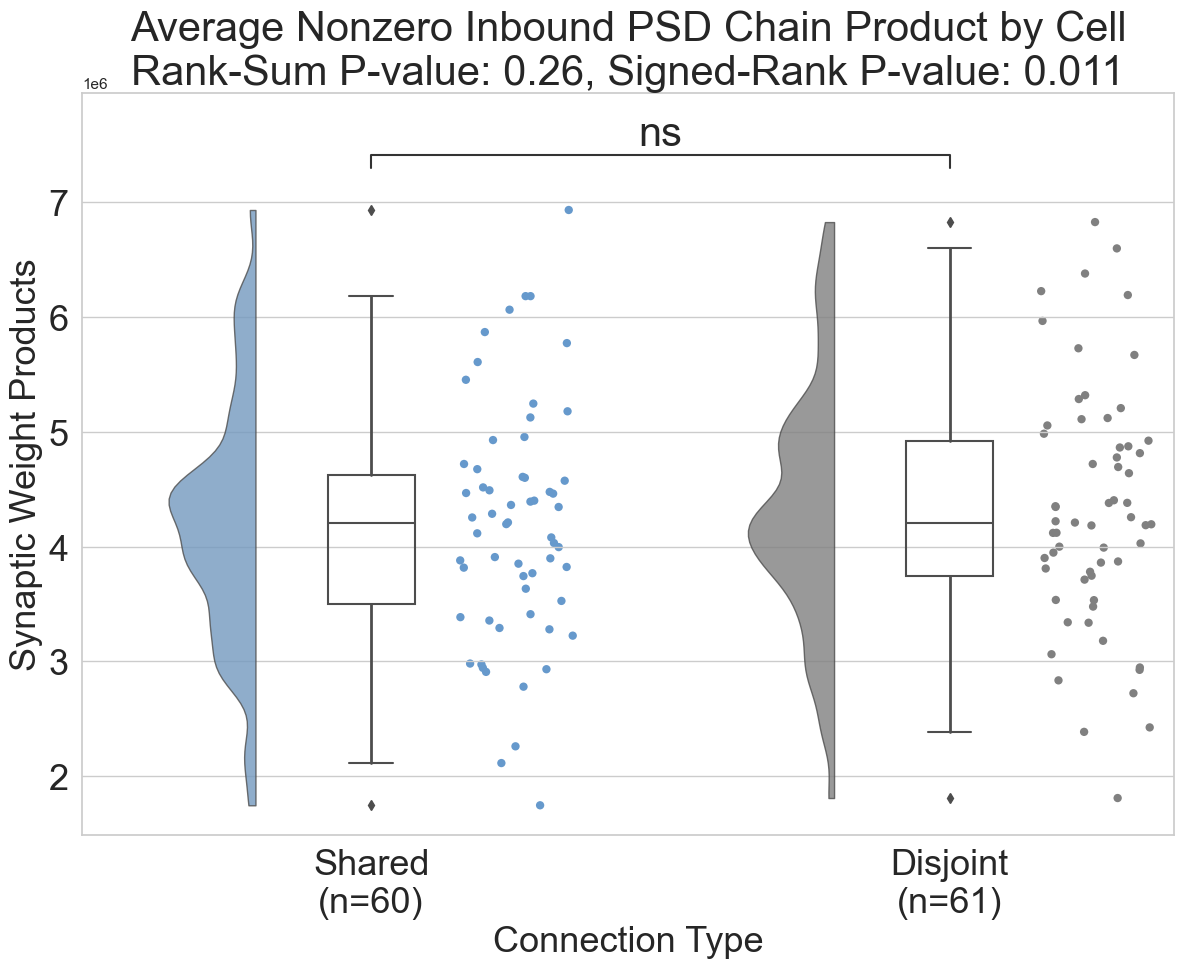

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=60) vs. Disjoint
(n=61): Custom statistical test, P_val:2.619e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


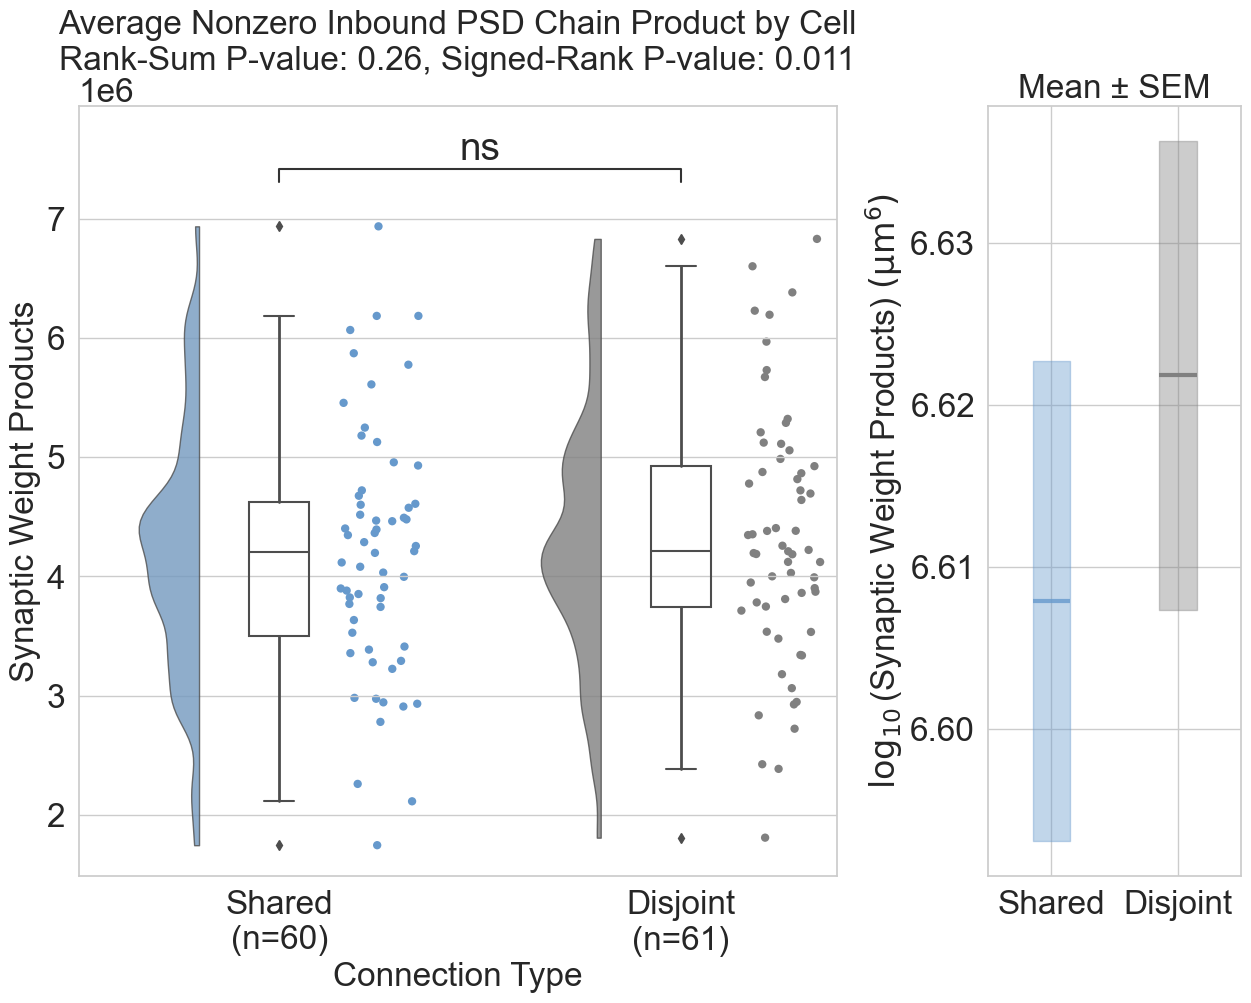

In [43]:
ranksum_signedrank_two_group_comparison(W_nonzero_chain_in_excitatory,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Excitatory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD_E_Chain'
                                        )

ranksum_signedrank_two_group_comparison(W_nonzero_chain_in_inhibitory,
                                        aggregation_method='cell',
                                        directionality='inbound',
                                        data_type='summed_psd',
                                        non_zero=True,
                                        paired=True,
                                        chain_test=True,
                                        chain_description= "Inhibitory",
                                        save=True,
                                        figure_name='Avg_Nonzero_Inbound_PSD_I_Chain'
                                        )

# Subsampling:

Wilcoxon Rank-Sum Test (unpaired, shared < disjoint):
Statistic: -1.106, P-value: 0.1343

[UNPAIRED] Effect Size Estimates (positive = in direction of 'less')
  n1=239, n2=307
  Cohen's d        = 0.063
  HL shift         = 4.75498e-05
  Probability Sup. = 0.528
  Cliff's δ        = 0.055

Effect Size Confidence Intervals (95% percentile bootstrap)
  d:     [-0.111, 0.243]
  HL:    [-3.67543e-05, 0.000137155]
  PS:    [0.479, 0.577]
  δ:     [-0.043, 0.154]

P-value stability
  median p = 0.1489
  95% range = [0.0009913, 0.8047]
  proportion significant (α=0.05) = 0.273
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=239) vs. Disjoint
(n=307): Custom statistical test, P_val:1.343e-01


c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


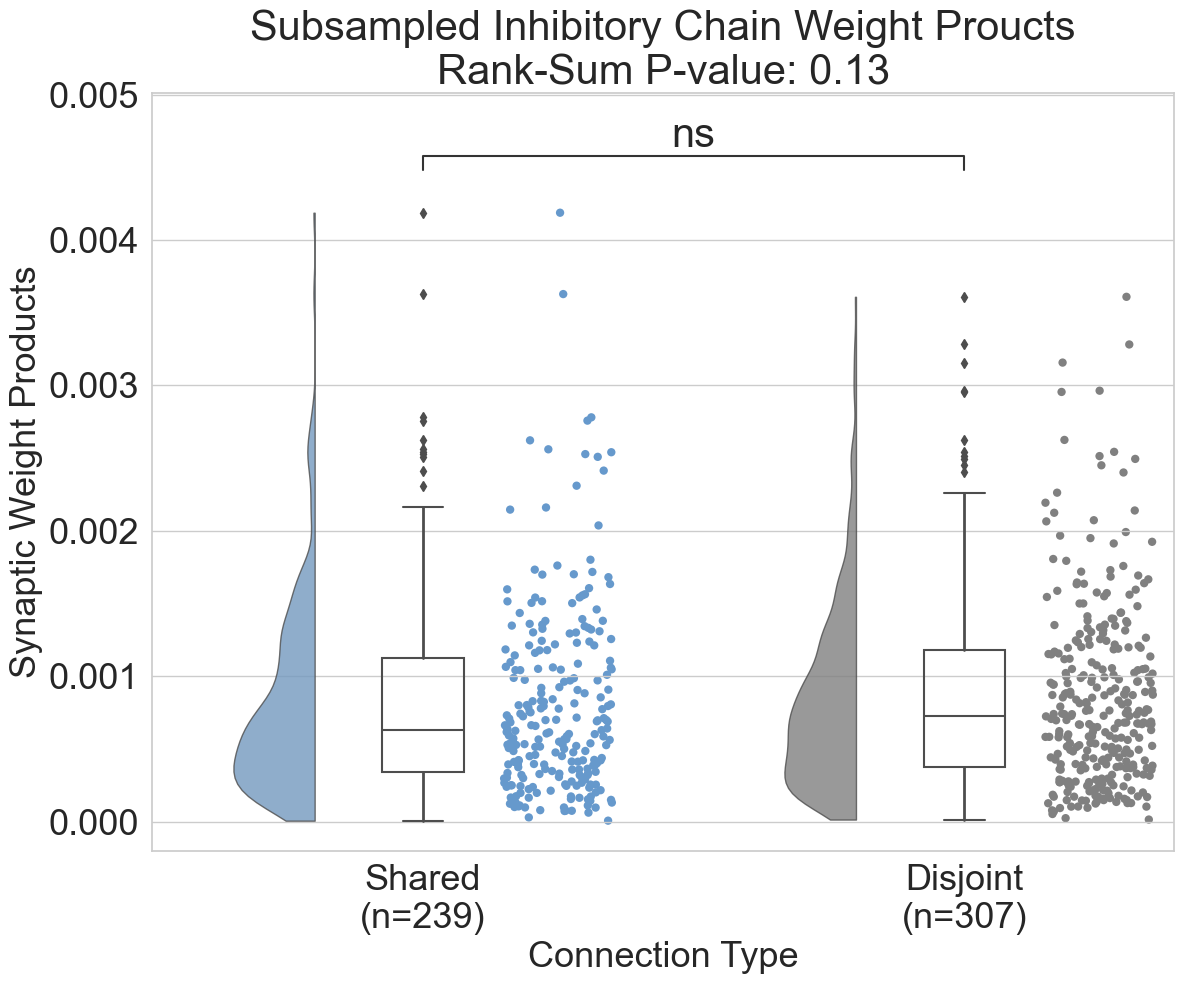

c:\Users\trevo\anaconda3\envs\analysis\Lib\site-packages\statannotations\Annotator.py:825: UserWarning: Annotator was reconfigured without applying the test (again) which will probably lead to unexpected results
  warnings.warn("Annotator was reconfigured without applying the "


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Shared
(n=239) vs. Disjoint
(n=307): Custom statistical test, P_val:1.343e-01


C:\Users\trevo\AppData\Local\Temp\ipykernel_18536\1852521774.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


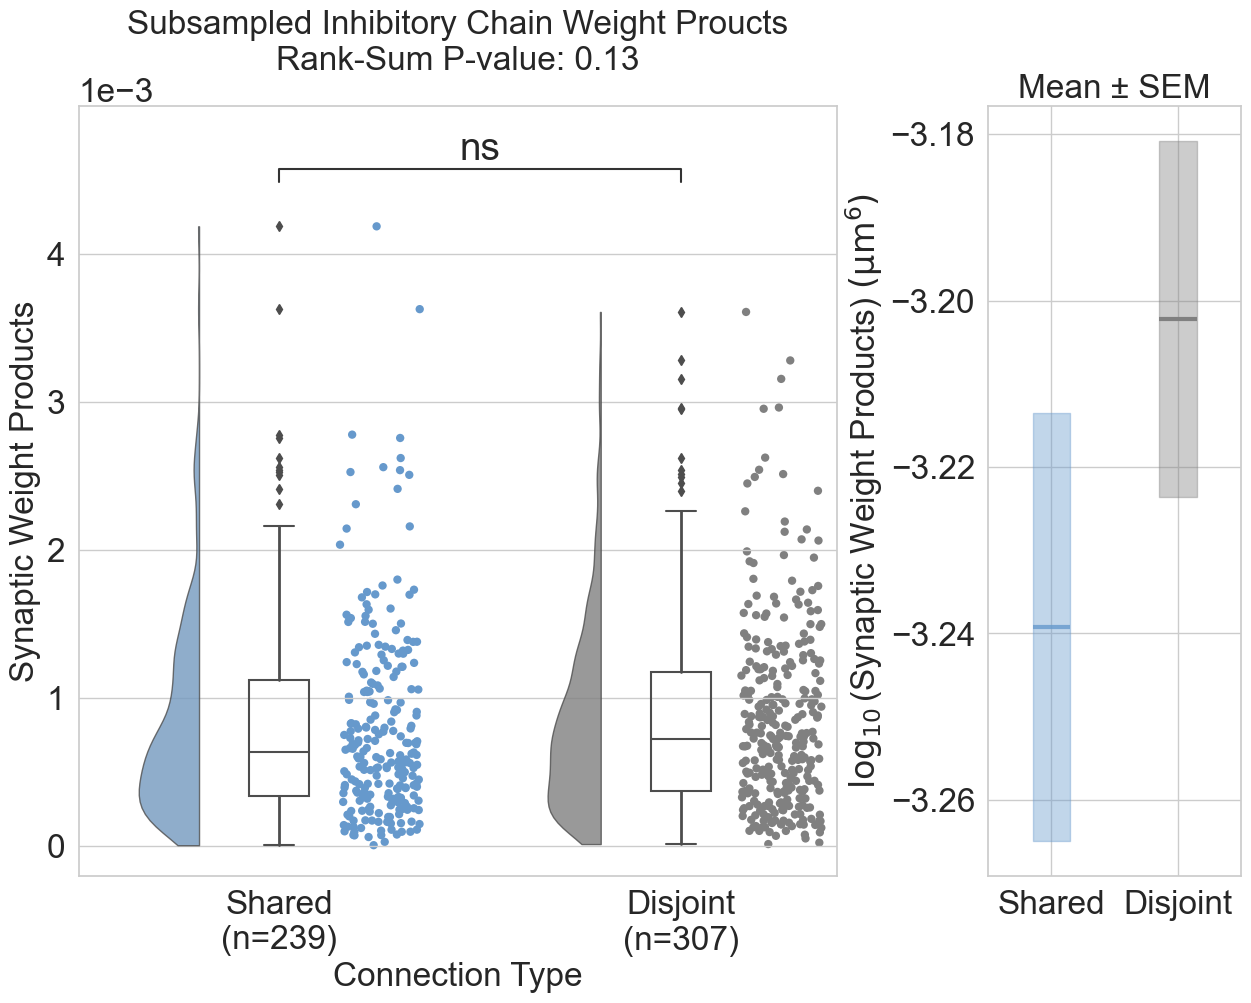

One subsample (seed=747): p=0.1343, Cohen's d=0.063, δ=0.055, var_shared=4.266e-07, var_disjoint=3.955e-07

Resampling (B=10000) summary
Proportion significant (α=0.05): 0.209
Median p: 0.1824 (95% range 0.004169–0.8138)
Median Cohen's d: 0.072 (95% CI -0.082–0.226)
Median rank-biserial δ (shared < disjoint): 0.045 (95% CI -0.044–0.132)


In [44]:
from numpy.random import default_rng
from scipy.stats import ranksums, mannwhitneyu

rng = default_rng(747)  # reproducible

# ---------------- Helpers ----------------

def extract_vals_keys(dod):
    """Flatten dict-of-dicts into arrays (values) + arrays (keys) for each stratum."""
    vals, keys = {}, {}
    for k in ('shared', 'disjoint'):
        items = list(dod.get(k, {}).items())
        if items:
            k_arr, v_arr = zip(*items)         # tuples
            vals[k] = np.asarray(v_arr, dtype=float)
            keys[k] = np.asarray(k_arr, dtype=object)
        else:
            vals[k] = np.empty(0, float)
            keys[k] = np.empty(0, object)
    return vals, keys

def subsample_indices(n_avail, n_take, rng):
    if n_take > n_avail:
        raise ValueError(f"Requesting {n_take} from only {n_avail} available.")
    return rng.choice(n_avail, size=n_take, replace=False)

def build_dict_from_indices(keys, vals, idx_s, idx_d):
    """Rebuild dict-of-dicts for your plotting/test function (keeps original (pre,post) keys)."""
    return {
        'shared':   {tuple(keys['shared'][i]): float(vals['shared'][i])     for i in idx_s},
        'disjoint': {tuple(keys['disjoint'][i]): float(vals['disjoint'][i]) for i in idx_d},
    }


def one_draw_stats(I_vals, n_shared, n_disjoint, rng):
    """One inhibitory subsample: returns p (ranksums), effect size δ (from U), Cohen's d, indices, and arrays."""
    idx_s = subsample_indices(I_vals['shared'].size,   n_shared,   rng)
    idx_d = subsample_indices(I_vals['disjoint'].size, n_disjoint, rng)
    s = I_vals['shared'][idx_s]
    d = I_vals['disjoint'][idx_d]

    rank_sum_stat, rank_sum_p = ranksums(s, d, alternative='less')

    U_s, _ = mannwhitneyu(s, d, alternative='less', method='asymptotic')
    n1, n2 = s.size, d.size
    delta = 1.0 - (2.0 * U_s) / (n1 * n2)

    d_cohen = cohens_d(s, d, alternative='less')

    return rank_sum_p, delta, d_cohen, idx_s, idx_d, s, d


def resample_many(I_vals, n_shared, n_disjoint, B=10_000, rng=None):
    if rng is None:
        rng = default_rng()
    pvals = np.empty(B, dtype=float)
    deltas = np.empty(B, dtype=float)
    ds = np.empty(B, dtype=float)
    for b in range(B):
        p, d, d_c, *_ = one_draw_stats(I_vals, n_shared, n_disjoint, rng)
        pvals[b] = p
        deltas[b] = d
        ds[b] = d_c
    return pvals, deltas, ds


# prep
target = {'shared': 239, 'disjoint':307}

# Flatten inhibitory once (values + keys)
I_vals, I_keys = extract_vals_keys(W_chain_nonzero_pairwise_inhibitory)

# ---------------- 1) One subsample -> plot ----------------
p_one, delta_one, d_one, idx_s, idx_d, s_one, d_one_arr = one_draw_stats(
    I_vals, target['shared'], target['disjoint'], rng
)

I_sub_for_plot = build_dict_from_indices(I_keys, I_vals, idx_s, idx_d)

# Add "Subsampled" note to title
ranksum_signedrank_two_group_comparison(
    I_sub_for_plot,
    aggregation_method='connection',
    data_type='summed_psd',
    non_zero=True,
    chain_test=True,
    chain_description="Inhibitory",
    save=True,
    figure_name='Subsampled_Nonzero_PSD_by_Conn_I_Chain',
    title_prefix="Subsampled "   # <-- new kwarg (we’ll add it below)
)

print(f"One subsample (seed=747): p={p_one:.4g}, "
      f"Cohen's d={d_one:.3f}, δ={delta_one:.3f}, "
      f"var_shared={np.var(s_one, ddof=1):.4g}, var_disjoint={np.var(d_one_arr, ddof=1):.4g}")

B = 10_000
pvals, deltas, d = resample_many(I_vals, target['shared'], target['disjoint'], B=B, rng=rng)

alpha = 0.05
prop_sig = (pvals < alpha).mean()
median_p = np.median(pvals)
p_ci = np.percentile(pvals, [2.5, 97.5])
median_delta = np.median(deltas)
delta_ci = np.percentile(deltas, [2.5, 97.5])
median_d = np.median(d)
d_ci = np.percentile(d, [2.5, 97.5])

print(f"\nResampling (B={B}) summary")
print(f"Proportion significant (α={alpha}): {prop_sig:.3f}")
print(f"Median p: {median_p:.4g} (95% range {p_ci[0]:.4g}–{p_ci[1]:.4g})")
print(f"Median Cohen's d: {median_d:.3f} (95% CI {d_ci[0]:.3f}–{d_ci[1]:.3f})")
print(f"Median rank-biserial δ (shared < disjoint): {median_delta:.3f} "
      f"(95% CI {delta_ci[0]:.3f}–{delta_ci[1]:.3f})")
